# DESeq2 with new reference genome
# Phase 2 vs. Phase 2

focusing on pairwise comparisons of oysters that experienced both phase 1 and phase 2

## 0. load libraries

In [2]:
library(tidyverse)
library(DESeq2)
library(EnhancedVolcano) # for volcano plots
library(vegan) # for permanova
library(pheatmap)
library(RColorBrewer)
library(limma) # for removing batch effects

## 1. read counts matrix and meta data

### counts matrix
the counts matrix was generated in [processing_seqs.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/processing/nov25_refSeq/processing_seqs.ipynb) with the new reference genome ([NCBI GCF_053477285.1](https://www.ncbi.nlm.nih.gov/datasets/genome/GCF_053477285.1/)), indexed and aligned with `hisat2`, and counts matrix generated with `featureCounts` (all with the same flags/settings that were used with the old genome)

In [3]:
# counts matrix
counts <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ce24_rnaseq/newRef_featureCounts/featureCounts_matrix.csv')

# set gene_ID as row name
rownames(counts) <- counts$Gene_ID

# remove gene id and length
counts.df <- counts %>%
select(-Gene_ID, -Length)

head(counts.df)

,B1_B1_O01,B1_Nu_O03,B1_W5_O50,B2_B5_O51,B2_C4_O40,B2_Nu_O12,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,⋯,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_Nu_G41,W6_Nu_G45,W6_W3_G36,W6_W4_G48
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
LOC144621260,2626,2649,2072,2158,2074,3974,1207,1181,3017,1438,⋯,1252,2294,2215,1653,1720,1566,2734,2374,2683,2391
LOC144621269,55,580,1632,2484,1011,20011,2110,886,9991,1446,⋯,6,620,44,101,9226,16,2,4034,383,9803
LOC111120925,70,4,23,469,11,18,15,7,0,1,⋯,3,452,82,28,5,1,0,11,11,9
Trnae-cuc,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Trnae-cuc-3,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [4]:
# number of genes with 0 counts for all samples
sum(rowSums(counts.df) == 0) # 4884 genes

# pre-filter those rows
counts.filtered <- counts.df[!rowSums(counts.df) == 0,]

# double check this worked
dim(counts.df) # 33903 total genes
dim(counts.filtered) # 29019 genes with at least 1 read

[1] 4884

[1] 33903   120

[1] 29019   120

### meta data
the meta data csv was already generated in [deseq_p1.v.p1](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb), so just reading in here

In [5]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
filter(!grepl("Nu", Sample)) # filter out phase 1 samples - only want phase 2

# setting samples as rownames and deleting col from df
rownames(meta) <- meta$Sample
meta <- meta[, !colnames(meta) %in% "Sample"]

head(meta)
dim(meta)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


[1] 96  8

creating new column for 'complete' treatment - so I can easily compare phase 1 to phase 2

In [6]:
meta$complete_trtmt <- paste(meta$Phase1_treatment, meta$Phase2_treatment)

# check
head(meta,2)
tail(meta,2)

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm


,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
W6_W3_G36,warm,warm,normoxic,6,warm,warm,normoxic,3,warm warm
W6_W4_G48,warm,warm,normoxic,6,warm,warm,normoxic,4,warm warm


In [7]:
# setting the same order for counts matrix and meta data
counts.filtered <- counts.filtered[,rownames(meta)]
all(rownames(meta) == colnames(counts.filtered))

[1] TRUE

## 2. DESeq2
analyzing differential gene expression with [`DESeq2`](https://bioconductor.org/packages/release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)

#### contrasts
setting up contrasts (telling DESeq what is the control treatment)

In [8]:
# tempature treatments
meta$Phase1_temp <- factor(meta$Phase1_temp,
                                   levels = c('ambient', 'warm'))

meta$Phase2_temp <- factor(meta$Phase2_temp,
                                   levels = c('ambient', 'warm'))

In [9]:
# DO treatments
meta$Phase1_DO <- factor(meta$Phase1_DO,
                                   levels = c('normoxic', 'hypoxic'))

meta$Phase2_DO <- factor(meta$Phase2_DO,
                                   levels = c('normoxic', 'hypoxic'))

### complete treatments
starting simple with looking at phase 1 treatments (not splitting into temperature/DO, just looking at combination of treatments)

In [16]:
# creating DESeq2 object
dds <- DESeqDataSetFromMatrix(countData = counts.filtered,
                              colData = meta,
                              design = ~ complete_trtmt)
dds

# running DESeq
dds <- DESeq(dds)

# list coefficients
resultsNames(dds)

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



class: DESeqDataSet 
dim: 29019 96 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



[1] "Intercept"                                  
 [2] "complete_trtmt_both.control_vs_both.both"   
 [3] "complete_trtmt_both.hypoxic_vs_both.both"   
 [4] "complete_trtmt_both.warm_vs_both.both"      
 [5] "complete_trtmt_control.both_vs_both.both"   
 [6] "complete_trtmt_control.control_vs_both.both"
 [7] "complete_trtmt_control.hypoxic_vs_both.both"
 [8] "complete_trtmt_control.warm_vs_both.both"   
 [9] "complete_trtmt_hypoxic.both_vs_both.both"   
[10] "complete_trtmt_hypoxic.control_vs_both.both"
[11] "complete_trtmt_hypoxic.hypoxic_vs_both.both"
[12] "complete_trtmt_hypoxic.warm_vs_both.both"   
[13] "complete_trtmt_warm.both_vs_both.both"      
[14] "complete_trtmt_warm.control_vs_both.both"   
[15] "complete_trtmt_warm.hypoxic_vs_both.both"   
[16] "complete_trtmt_warm.warm_vs_both.both"

looks like there were 29019 genes pre-filter

In [17]:
# 2. Define your 16-level group and filter BEFORE running DESeq()
dds$group <- factor(dds$complete_trtmt)
keep <- apply(counts(dds), 1, function(x) {
  any(tapply(x, dds$group, function(g) sum(g >= 10) >= 6))
})
dds_filtered <- dds[keep, ]


In [20]:
dds_filtered

class: DESeqDataSet 
dim: 19929 96 
metadata(1): version
assays(4): counts mu H cooks
rownames(19929): LOC144621260 LOC144621269 ... LOC111114498
  LOC111112304
rowData names(78): baseMean baseVar ... deviance maxCooks
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

19,929 genes after filtering

In [21]:
19929 / 29019
# so maintaining about 69% of genes

[1] 0.686757

Checking how strict this filtering was by looking at the control oysters and see how many genes have reasonable counts (not outliers/no counts) 

In [25]:
baseline_group <- "control control"  # match your actual level naming
baseline_samples <- dds_filtered$group == baseline_group
baseline_ok <- rowSums(counts(dds_filtered)[, baseline_samples] >= 10) >= 6
table(baseline_ok)

baseline_ok
FALSE  TRUE 
 2898 17031 

so only about 15% of the genes don't have reliable counts in the control oysters - but going to move forward with this cutoff

In [26]:

# 3. Now run DESeq() on the filtered object
dds_filtered <- DESeq(dds_filtered)

# 4. VST also happens after filtering + fitting, using the fitted dispersion trend
vst_mat <- assay(vst(dds_filtered, blind = FALSE))

# 5. lfcShrink pulls specific contrasts from the fitted dds
#res_interaction <- lfcShrink(dds_filtered, coef = "phase1_treatmentX.phase2_treatmentY", type = "apeglm")

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [29]:
dim(vst_mat)
head(vst_mat)

[1] 19929    96

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.612018,11.410505,11.395755,11.260951,10.983819,10.967124,11.354292,11.047092,11.149851,11.171430,⋯,11.825284,10.640900,11.093392,11.533447,11.399446,11.225205,11.358577,11.210233,11.799384,11.645365
LOC144621269,8.983638,11.149962,11.554932,10.544188,11.593060,10.684887,12.816297,11.052861,8.772350,8.631978,⋯,13.909835,8.567121,8.638438,10.248890,8.921324,9.221939,13.465735,8.752982,9.941087,13.443623
LOC111120925,9.053982,8.799041,9.990607,8.667559,8.749799,8.648228,8.426585,8.505579,8.426585,8.504272,⋯,9.867287,8.426585,8.576455,10.007723,9.099185,8.849169,8.613182,8.508347,8.694812,8.667369
LOC144621283,10.128963,10.523551,10.545323,10.382740,10.470277,10.734034,10.702060,10.000753,10.316158,10.408881,⋯,10.214198,10.655525,10.418343,10.547359,10.520028,10.441864,10.192667,10.997231,10.205858,10.234462
LOC144621276,13.468076,13.510863,13.681775,13.517159,13.792402,13.912864,13.728612,13.237641,13.771006,13.451346,⋯,14.036762,13.326631,13.863435,13.562237,13.117329,13.299122,13.947275,13.391572,13.436896,13.388054
LOC111115920,9.391071,9.452573,9.362963,9.223163,9.152730,9.106659,9.025872,9.881728,9.192561,9.757831,⋯,9.124406,9.206133,9.616780,9.313794,9.907652,9.910293,9.454377,9.598679,9.173636,9.272373


### explore results and fit

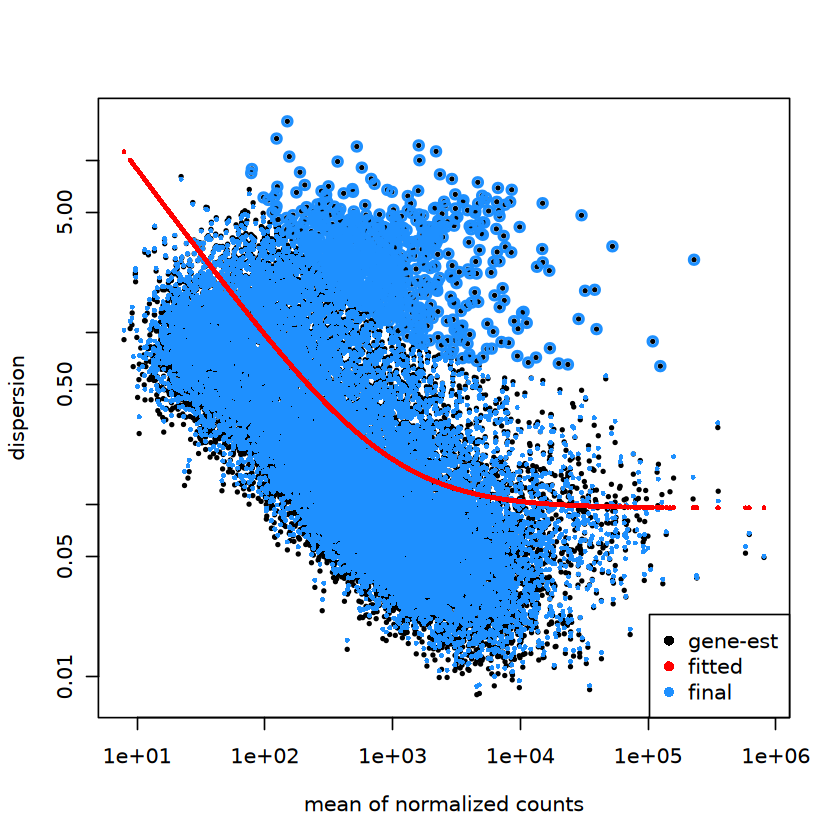

In [30]:
plotDispEsts(dds_filtered)

### nMDS
normalize and transform DESeq object using csv (variance stabilized expression matrix)

In [32]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,75.66614,76.54286,73.05008,77.78933,77.39408,83.84361,78.21674,78.85592,69.76580,⋯,87.67085,75.23669,66.02802,70.00039,66.63785,69.53569,84.85790,72.53042,71.00035,88.77497
B1_W5_O50,75.66614,0.00000,70.09263,63.09588,59.50763,65.30198,65.81852,77.63778,74.99194,73.02667,⋯,72.65556,81.27625,74.71524,74.59650,76.91473,74.18052,76.01045,76.21550,70.51627,71.45513
B2_B5_O51,76.54286,70.09263,0.00000,78.31823,72.34269,77.86273,74.05205,84.86070,88.24071,85.01836,⋯,77.46285,91.00163,82.39029,71.25829,81.08757,82.96201,78.29645,83.47543,79.53779,74.10504
B2_C4_O40,73.05008,63.09588,78.31823,0.00000,66.82123,65.97585,73.15515,75.86575,79.80885,68.21135,⋯,76.93617,76.67905,73.04797,72.71574,73.11154,71.87281,81.69775,71.76294,56.81562,78.22901
B3_B4_O41,77.78933,59.50763,72.34269,66.82123,0.00000,69.89241,71.25871,82.53898,72.12461,76.81768,⋯,72.43599,84.76466,75.74685,78.20358,81.95313,78.84981,72.94348,80.00510,74.10863,73.39406
B3_C3_O30,77.39408,65.30198,77.86273,65.97585,69.89241,0.00000,75.36691,82.04165,82.82862,78.10287,⋯,79.86219,84.39056,70.66986,79.95623,79.81212,77.37785,84.94147,74.34197,74.71499,82.74073


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,12.720464,8.551712,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-7.532896,-13.458191,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-17.464148,-1.062379,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,2.586113,-9.431981,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-11.321353,-11.395600,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,1.066169,-9.004720,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


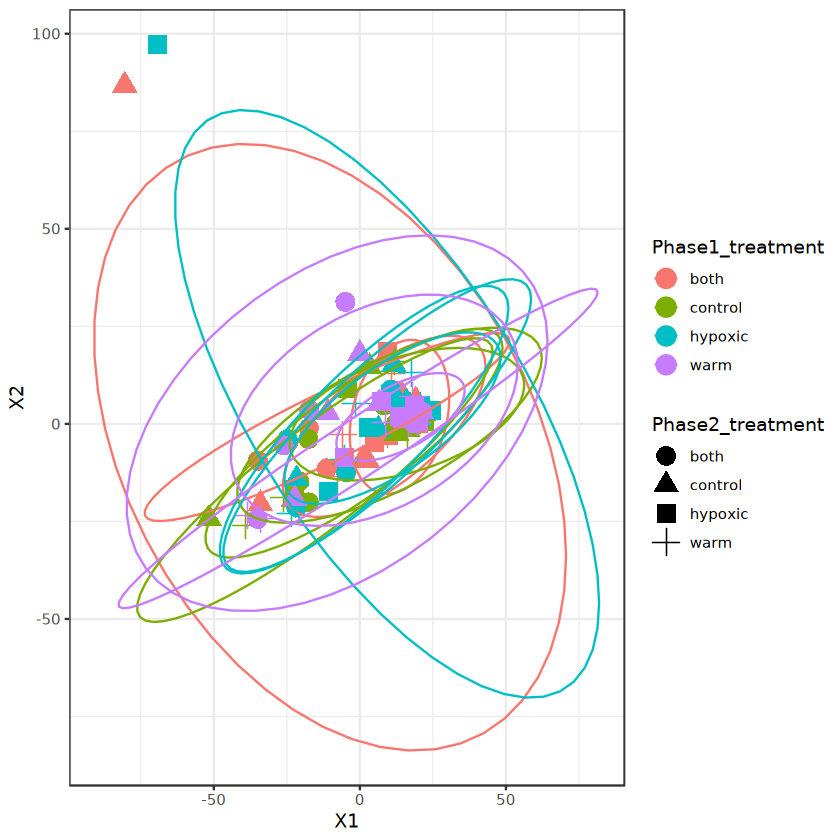

In [33]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

nmds.plot

In [34]:
sample_dists <- dist(t(assay(vsd)))  # transpose so samples are rows
head(sample_dists)

meta <- as.data.frame(colData(vsd))
head(meta)

[1] 75.66614 76.54286 73.05008 77.78933 77.39408 83.84361

,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [35]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,2784.718,0.008644583,0.8306618,0.738
Phase1_DO,1,2848.403,0.008842281,0.8496586,0.759
Phase2_temp,1,7622.768,0.023663314,2.2738182,0.002
Phase2_DO,1,5505.334,0.017090177,1.6422026,0.023
Phase1_temp:Phase1_DO,1,2279.877,0.007077410,0.6800714,0.977
Phase1_temp:Phase2_temp,1,2358.288,0.007320821,0.7034609,0.940
Phase1_DO:Phase2_temp,1,3108.381,0.009649329,0.9272083,0.572
Phase1_temp:Phase2_DO,1,2560.990,0.007950065,0.7639253,0.881
Phase1_DO:Phase2_DO,1,3101.702,0.009628595,0.9252159,0.556


- Phase2_temp has a significant effect on GE (P = 0.005) and explains ~1.9% of the variation in GE
- The interaction of Phase2_temp and Phase2_DO is nearly significant (P = 0.094) and explains ~1.3% of the variation in GE
- The majoirty of the variation in GE is not explained by the treatments (R2 = 0.84)

### heatmap of sample-to-sample distances using the variance stabilizing transformed values
following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [36]:
# normalization & transformation
vsd <- vst(dds_filtered)

# calculate sample distances
sample_dists <- dist(t(assay(dds_filtered)))
head(sample_dists)

[1]  556361.8  656742.9  521972.3  549730.7  500812.6 1119654.0

In [37]:
head(vsd)

class: DESeqTransform 
dim: 6 96 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(96): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

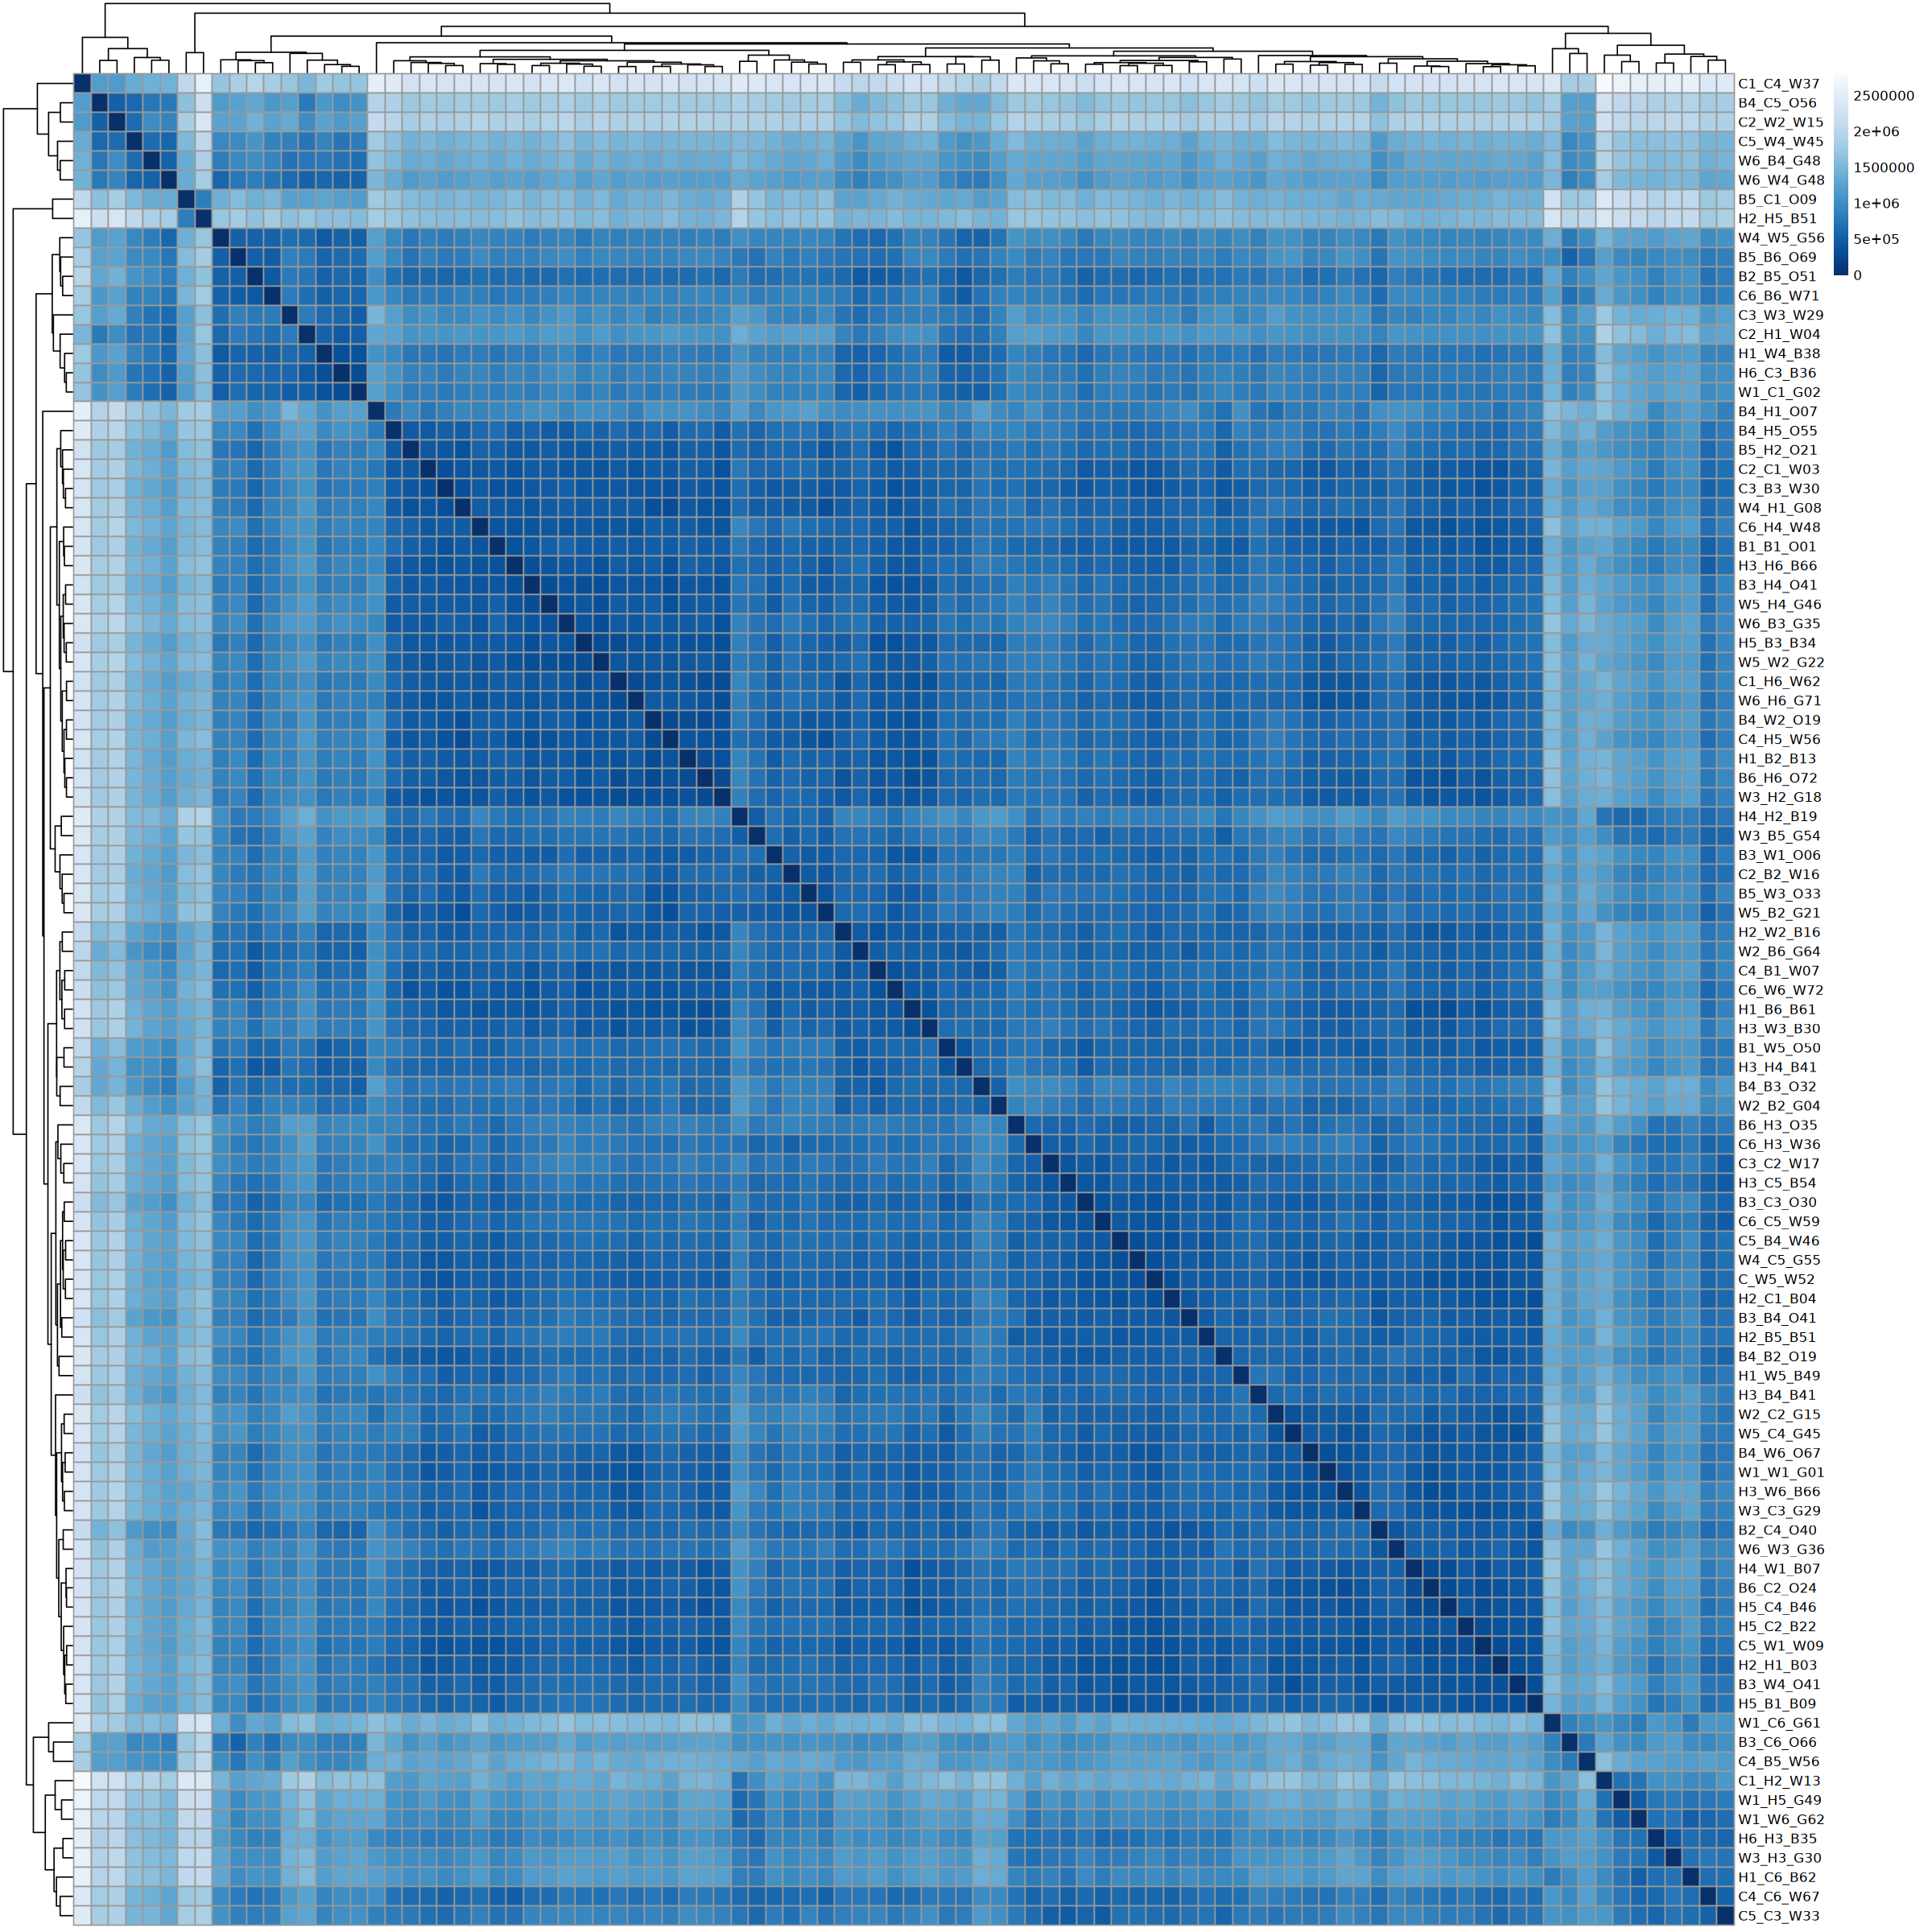

In [38]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

it's weird that there's two samples that are very dissimilar to every other sample, but appear closer together - (HH and BC) - if you look at the nMDS plots too, they look like outliers from their replicates so should consider removing those samples from analysis 

In [39]:
pcaData <- plotPCA(vsd, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-12.549525,4.971274,both:both,both,both,B1_B1_O01
B1_W5_O50,11.302542,-8.054463,both:warm,both,warm,B1_W5_O50
B2_B5_O51,15.515311,6.466620,both:both,both,both,B2_B5_O51
B2_C4_O40,3.081882,-5.931944,both:control,both,control,B2_C4_O40
B3_B4_O41,13.822059,-5.972922,both:both,both,both,B3_B4_O41
B3_C3_O30,2.519406,-6.060937,both:control,both,control,B3_C3_O30


### PCA

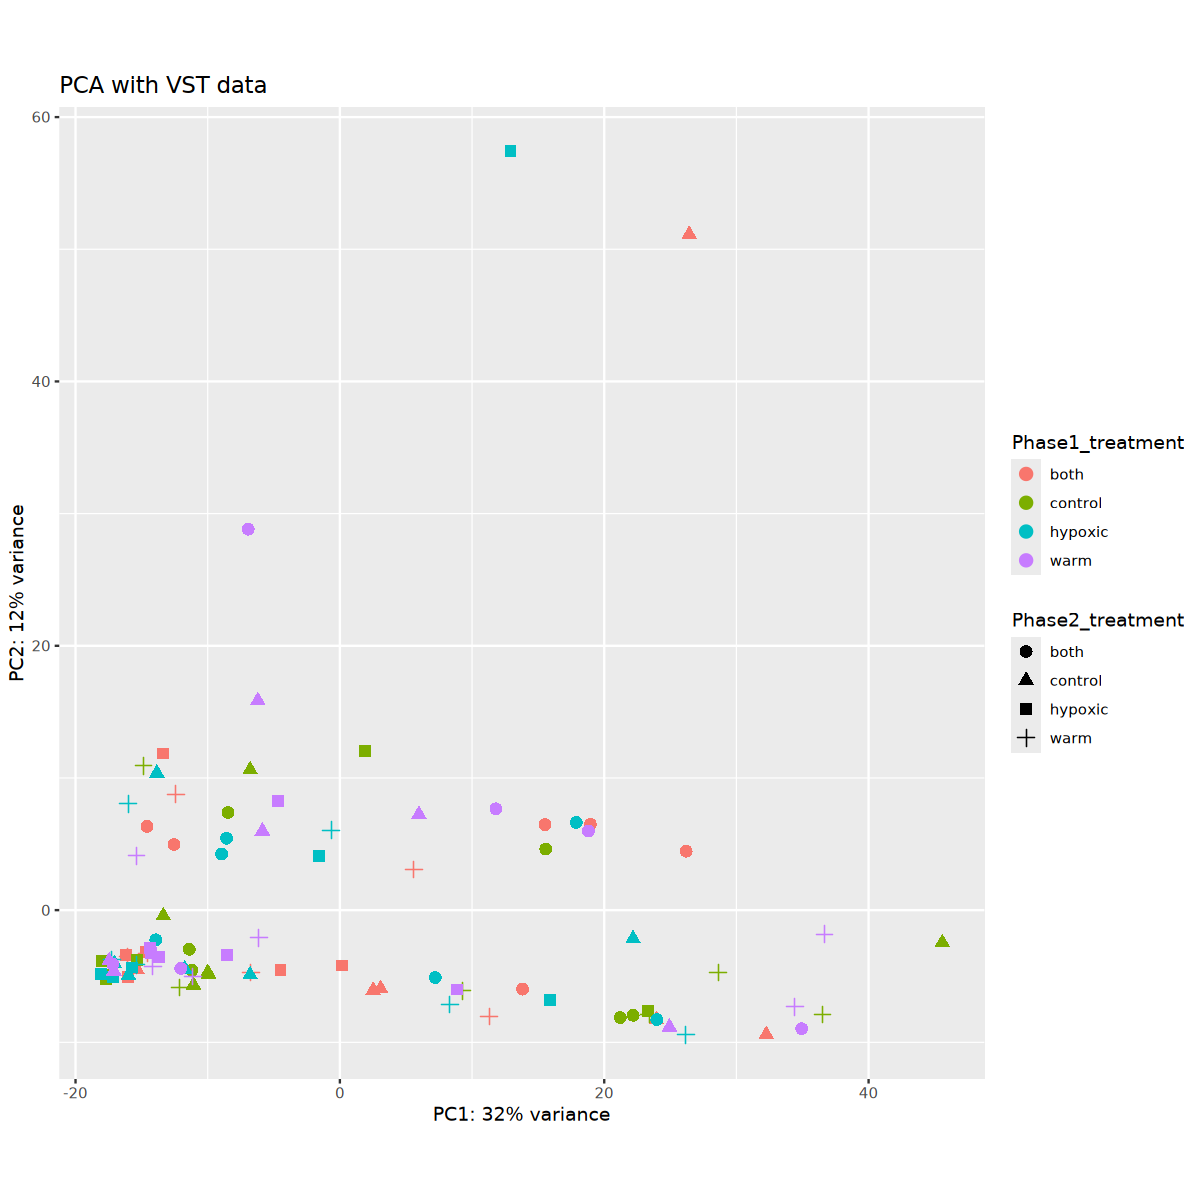

In [40]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData, "percentVar"))

ggplot(pcaData, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with VST data")

there's those two samples again in the bottom of the plot - B5_C1_O09 and H2_H5_B51 - that cluster away from everything else 

what do things look like if I remove those?

In [41]:
# remove two samples
dds_rm<- dds_filtered[, !colnames(dds_filtered) %in% c("B5_C1_O09", "H2_H5_B51")]

In [42]:
# normalization & transformation
vsd_filtered <- vst(dds_rm)

# calculate sample distances
sample_dists_filtered <- dist(t(assay(vsd_filtered)))
head(sample_dists_filtered)

[1] 86.56810 87.22173 83.47481 88.63009 88.10239 95.32332

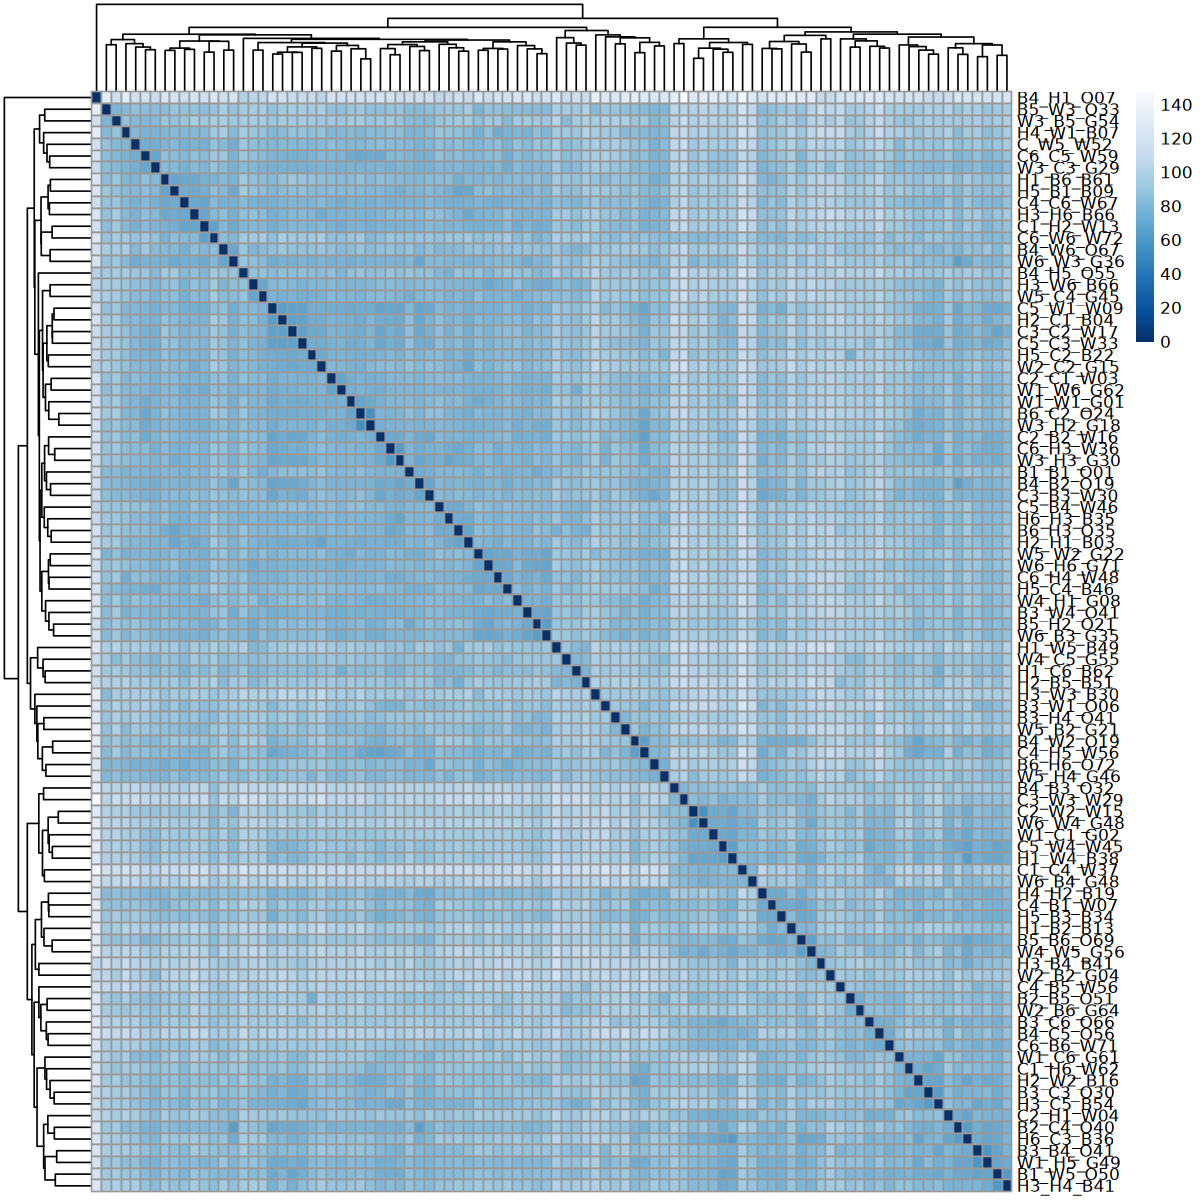

In [43]:
sampleDistMatrix <- as.matrix(sample_dists_filtered)
rownames(sampleDistMatrix) <- paste(colnames(vsd_filtered))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists_filtered,
         clustering_distance_cols = sample_dists_filtered,
         col = colors)

In [44]:
pcaData_filtered <- plotPCA(vsd_filtered, intgroup = c( "Phase1_treatment", "Phase2_treatment"), returnData = TRUE)
head(pcaData_filtered)

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-14.140376,9.825266,both:both,both,both,B1_B1_O01
B1_W5_O50,14.549083,-5.803481,both:warm,both,warm,B1_W5_O50
B2_B5_O51,17.745004,14.097003,both:both,both,both,B2_B5_O51
B2_C4_O40,4.885147,-7.736697,both:control,both,control,B2_C4_O40
B3_B4_O41,16.651016,-6.427916,both:both,both,both,B3_B4_O41
B3_C3_O30,4.113305,-6.452756,both:control,both,control,B3_C3_O30


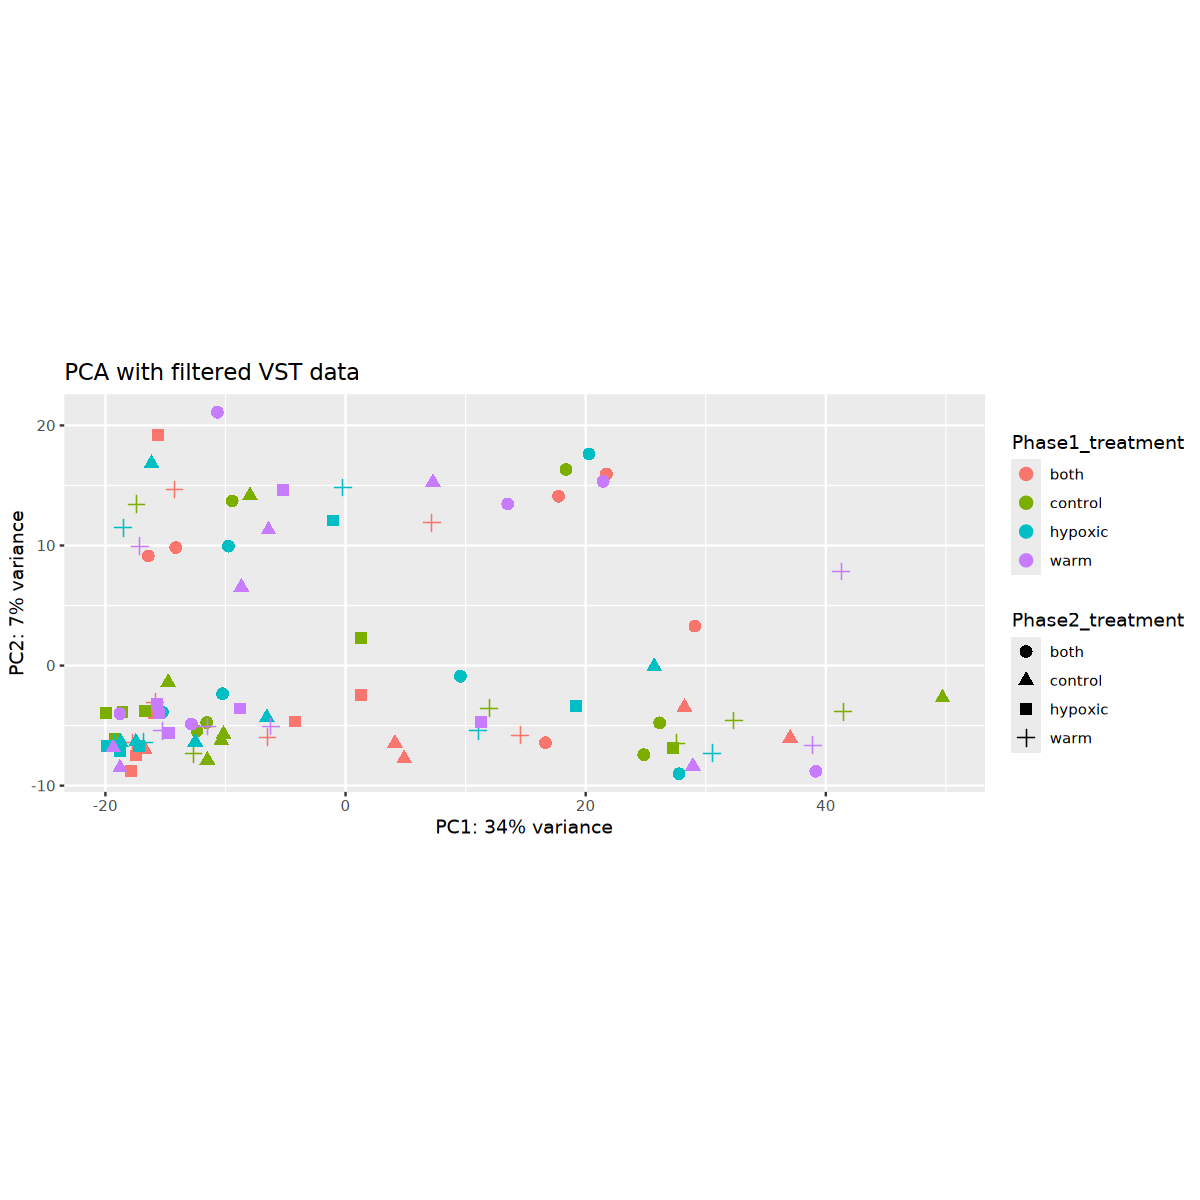

In [45]:
options(repr.plot.width=10, repr.plot.height=10)

percentVar <- round(100 * attr(pcaData_filtered, "percentVar"))

ggplot(pcaData_filtered, aes(x = PC1, y = PC2, color = Phase1_treatment, shape = Phase2_treatment)) +
  geom_point(size =3) +
  xlab(paste0("PC1: ", percentVar[1], "% variance")) +
  ylab(paste0("PC2: ", percentVar[2], "% variance")) +
  coord_fixed() +
  ggtitle("PCA with filtered VST data")

In [46]:
# calculate MDS value from distance matrix
mdsData_filtered <- data.frame(cmdscale(sample_dists_filtered))
mds_filtered <- cbind(mdsData_filtered, as.data.frame(colData(vsd_filtered))) # combine with sample data
head(mds_filtered)

,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,15.910247,6.357548,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-15.108816,-4.709899,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-20.226883,-6.172679,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-2.880726,4.583532,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.785016,-8.965554,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-3.851368,-15.994772,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


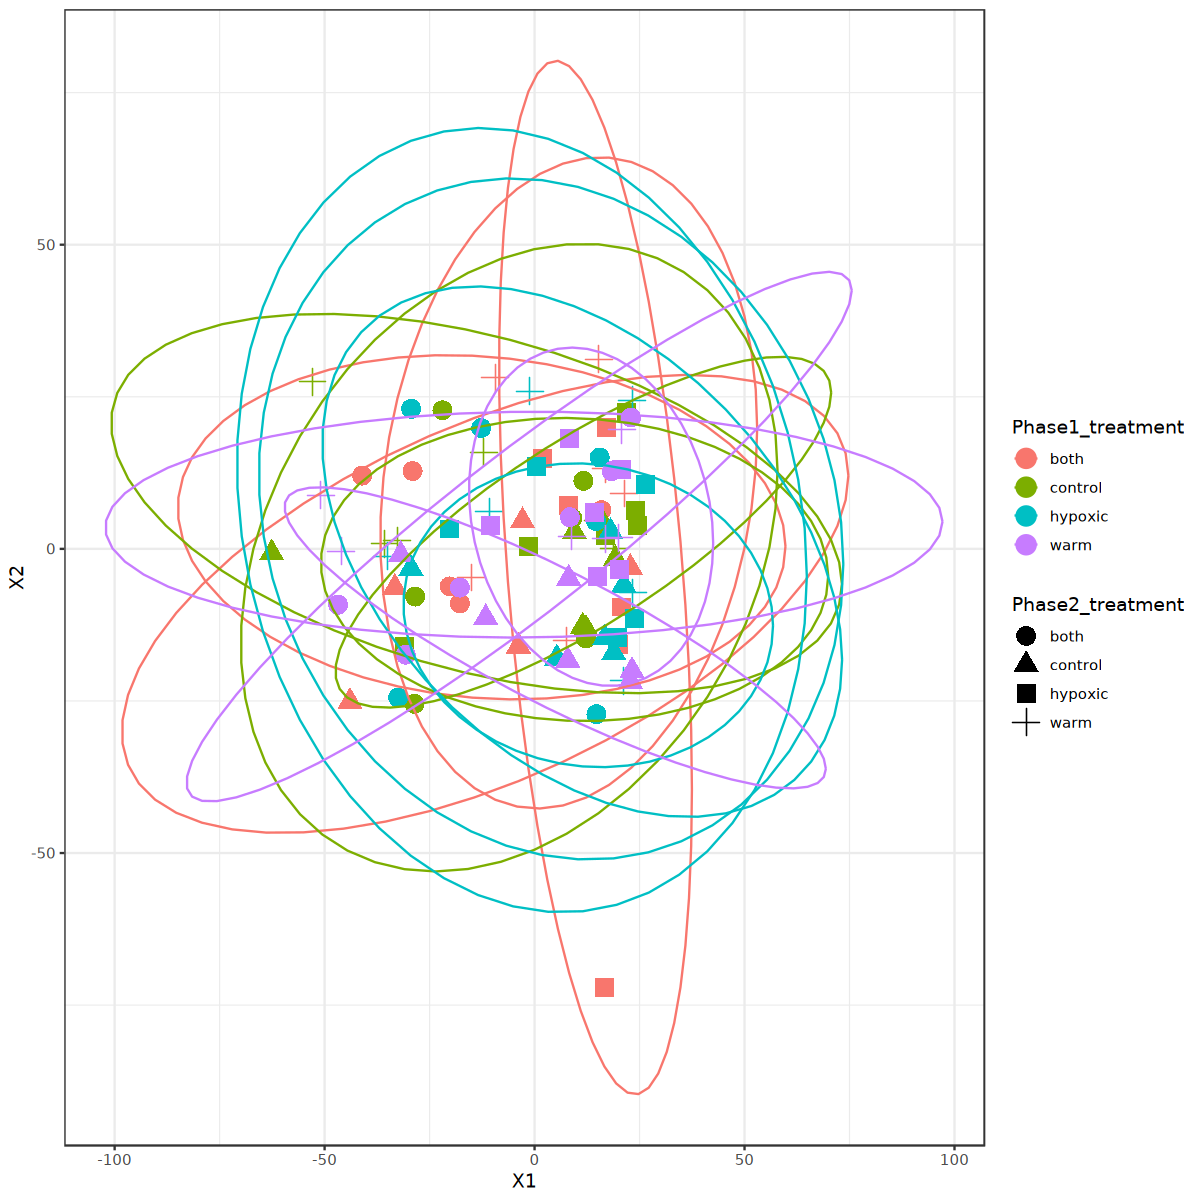

In [47]:
ggplot(mds_filtered, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
stat_ellipse() + 
theme_bw()

okay so it appears when we remove those two seemingly outlier samples, the data gets a little bit 'more clear' and replicates segregate a little better

let's remove those samples (**B5_C1_O09** and **H2_H5_B51**) and re-run DESeq2

## 2. remove outliers, run DESeq again

In [67]:
outlier_samples <- c('B5_C1_O09', 'H2_H5_B51')

dds_rm <- dds_filtered[, !colnames(dds_filtered) %in% outlier_samples]
dds_rm <- DESeq(dds_rm)
vst_mat <- assay(vst(dds_rm, blind = FALSE))

using pre-existing size factors

estimating dispersions

found already estimated dispersions, replacing these

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

final dispersion estimates

fitting model and testing



In [68]:
#write.csv(vst_mat, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/vst_filtered.csv', row.names = FALSE)

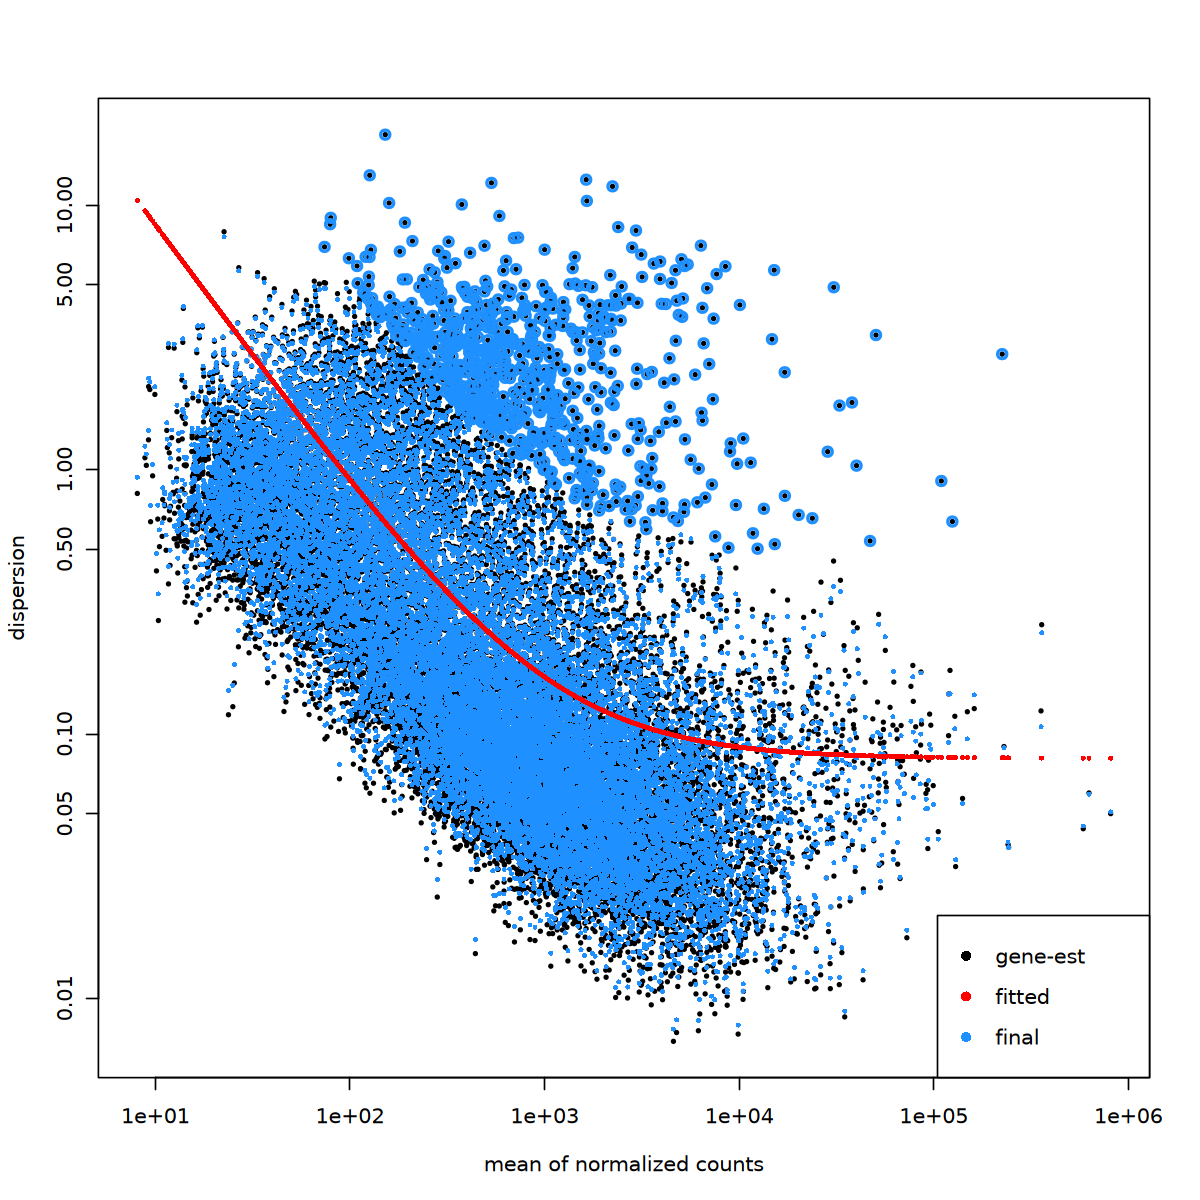

In [71]:
options(repr.plot.height = 10, repr.plot.width = 10)

plotDispEsts(dds_rm)

### PCA

using ntop=500 top features by variance



,PC1,PC2,group,Phase1_treatment,Phase2_treatment,name
,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
B1_B1_O01,-13.979147,9.715772,both:both,both,both,B1_B1_O01
B1_W5_O50,14.287457,-5.686674,both:warm,both,warm,B1_W5_O50
B2_B5_O51,17.481983,13.930226,both:both,both,both,B2_B5_O51
B2_C4_O40,4.767981,-7.710670,both:control,both,control,B2_C4_O40
B3_B4_O41,16.462251,-6.311822,both:both,both,both,B3_B4_O41
B3_C3_O30,4.087454,-6.360033,both:control,both,control,B3_C3_O30


using ntop=500 top features by variance

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the DESeq2 package.
  Please report the issue to the authors.”


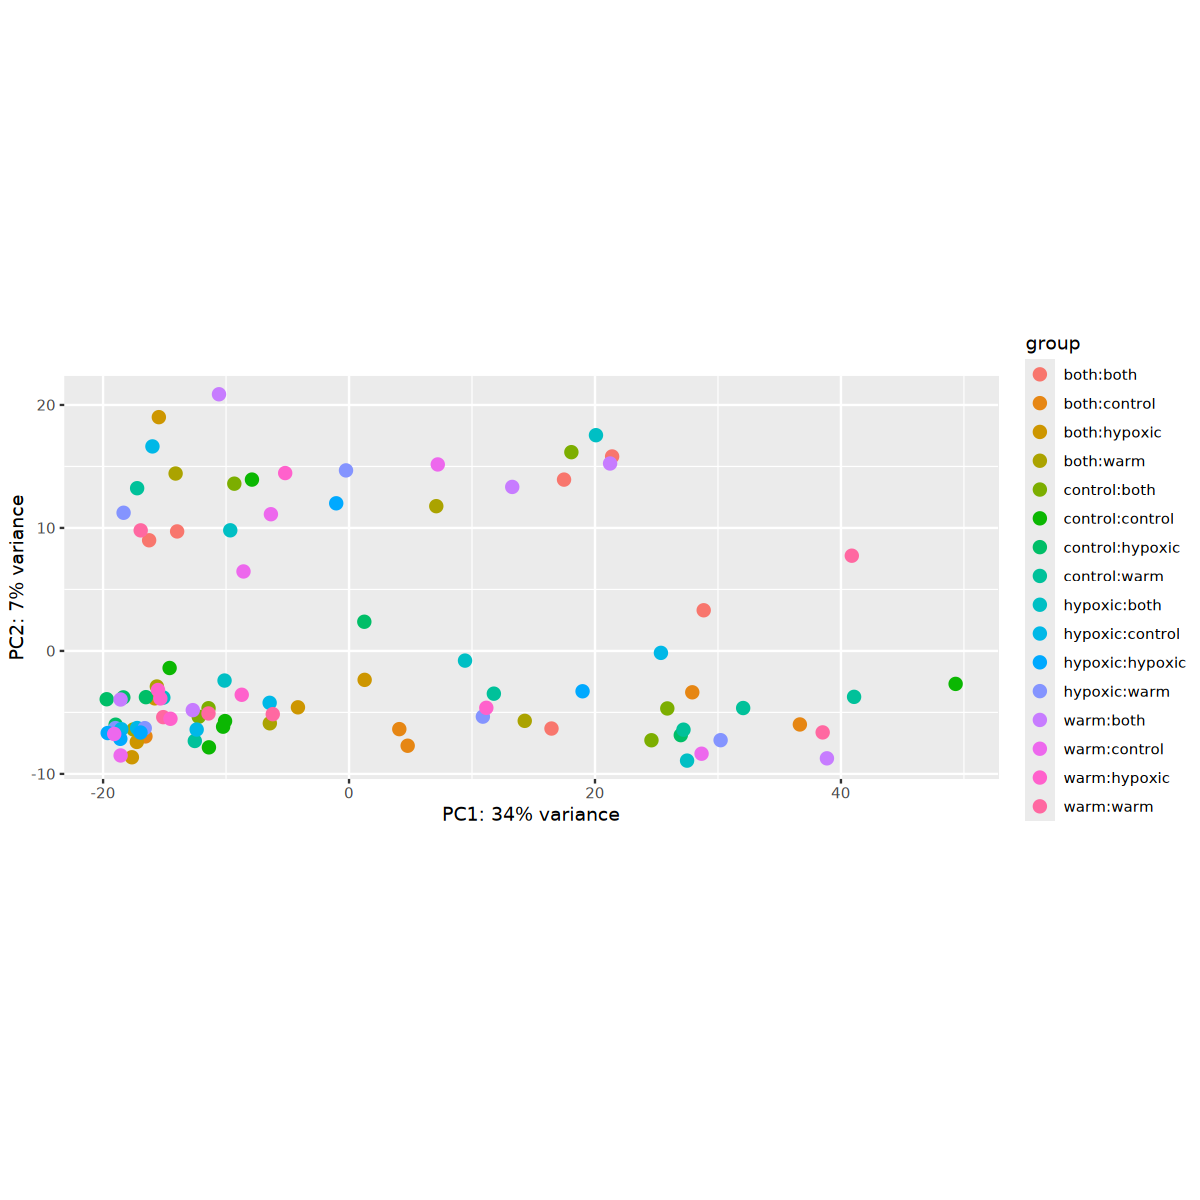

In [51]:
options(repr.plot.height = 10, repr.plot.width = 10)

vsd <- vst(dds_rm, blind=FALSE)
pca_data <- plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"), returnData=TRUE)
head(pca_data)

plotPCA(vsd, intgroup=c("Phase1_treatment", "Phase2_treatment"))

two groups seperating on the y axis

also PC1 explains 34% of the variance

using ntop=500 top features by variance



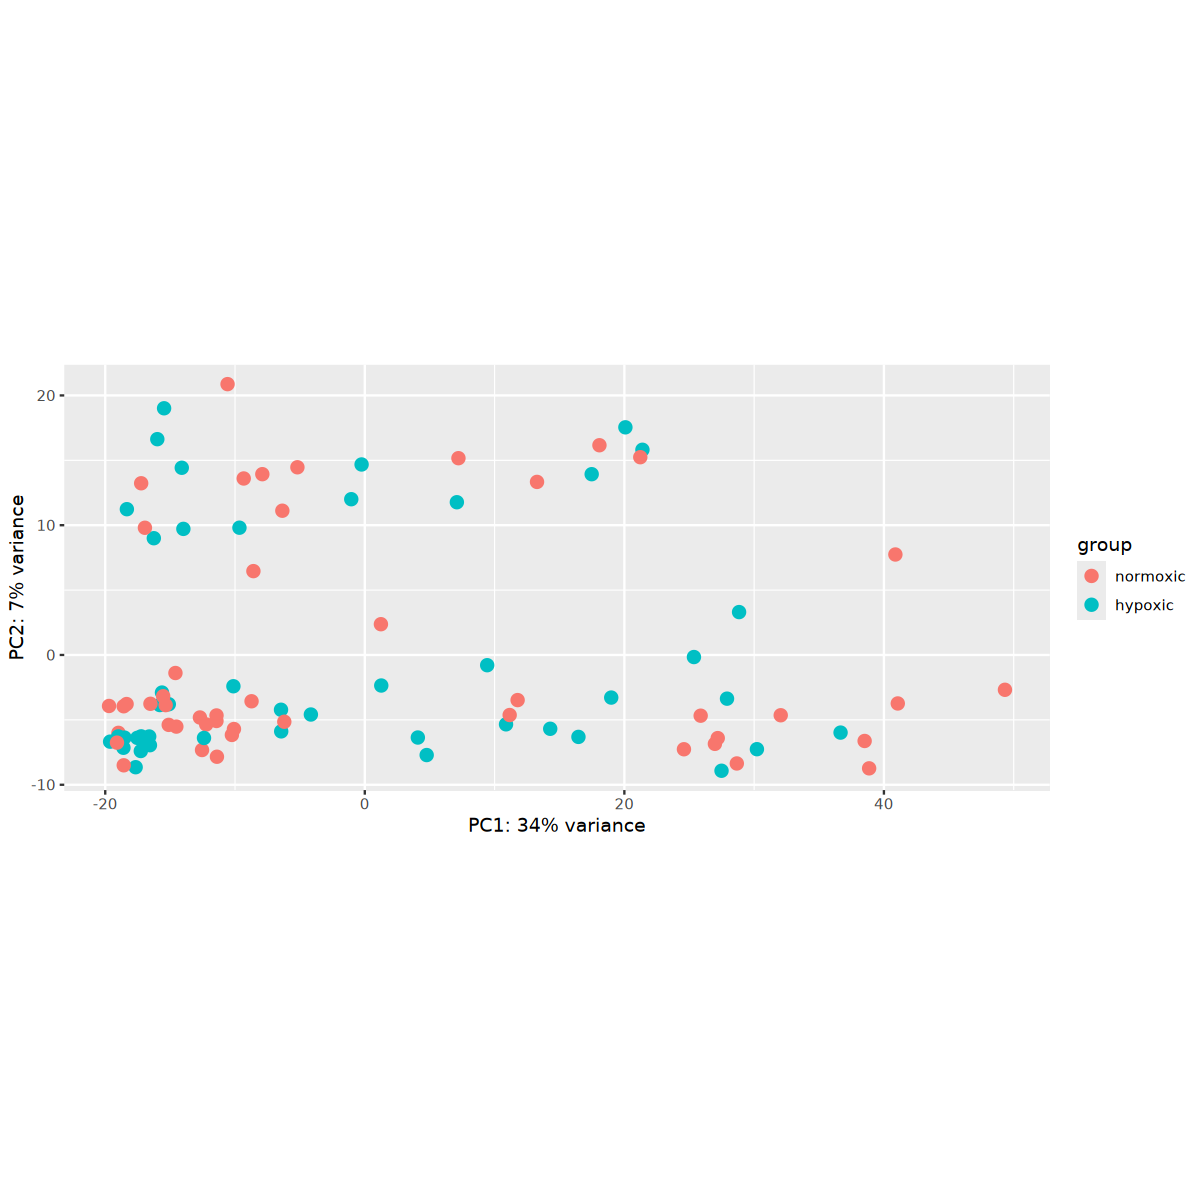

In [52]:
plotPCA(vsd, intgroup=c("Phase1_DO"))

using ntop=500 top features by variance



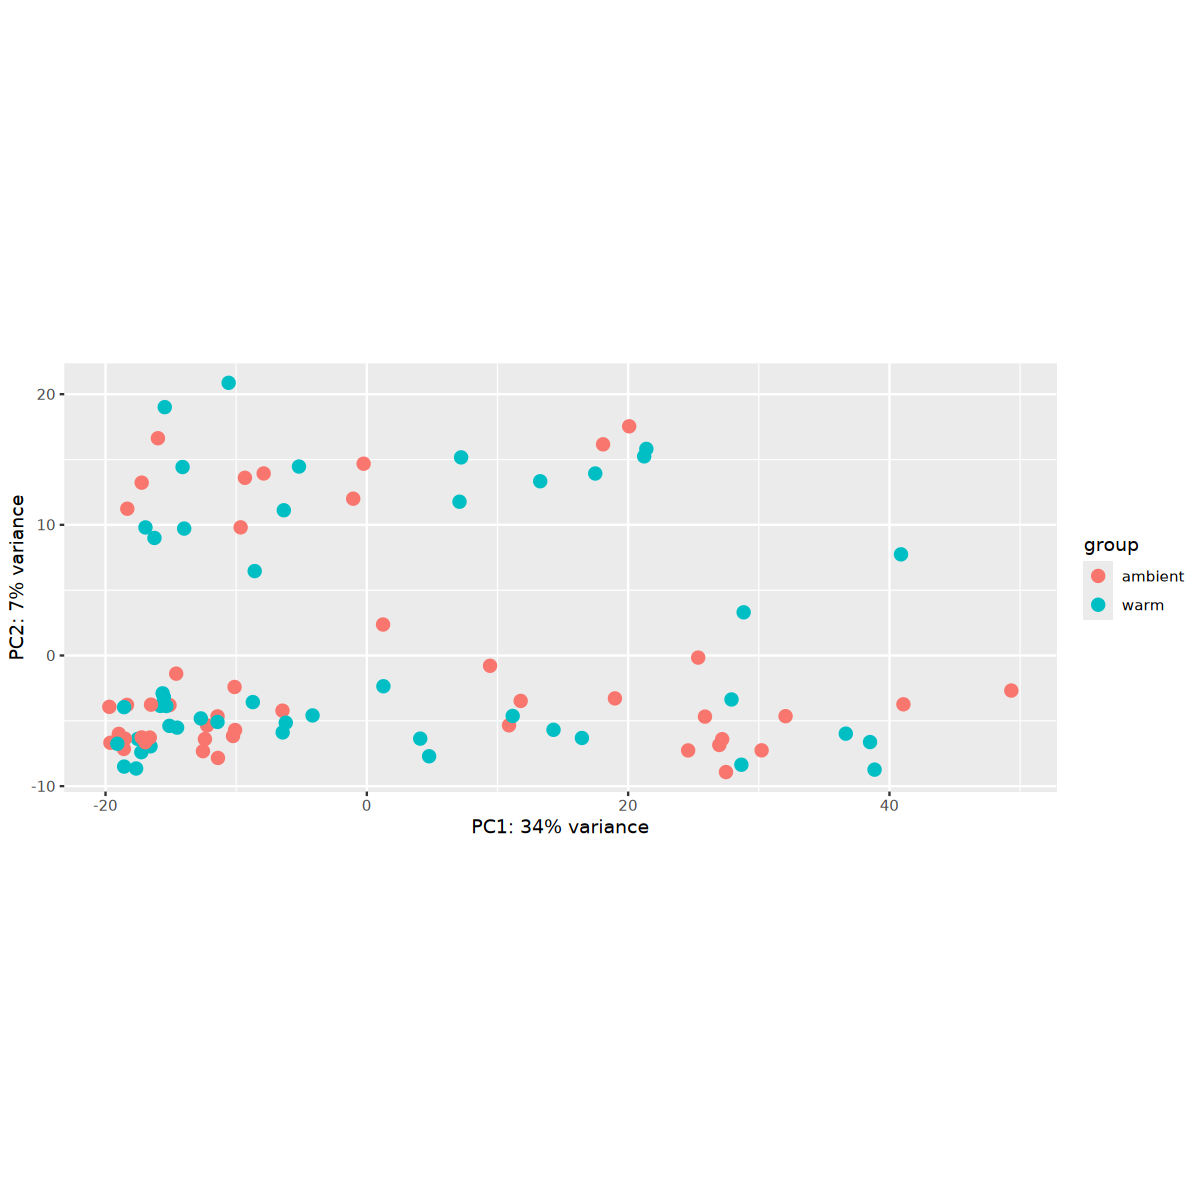

In [53]:
plotPCA(vsd, intgroup=c("Phase1_temp"))

using ntop=500 top features by variance



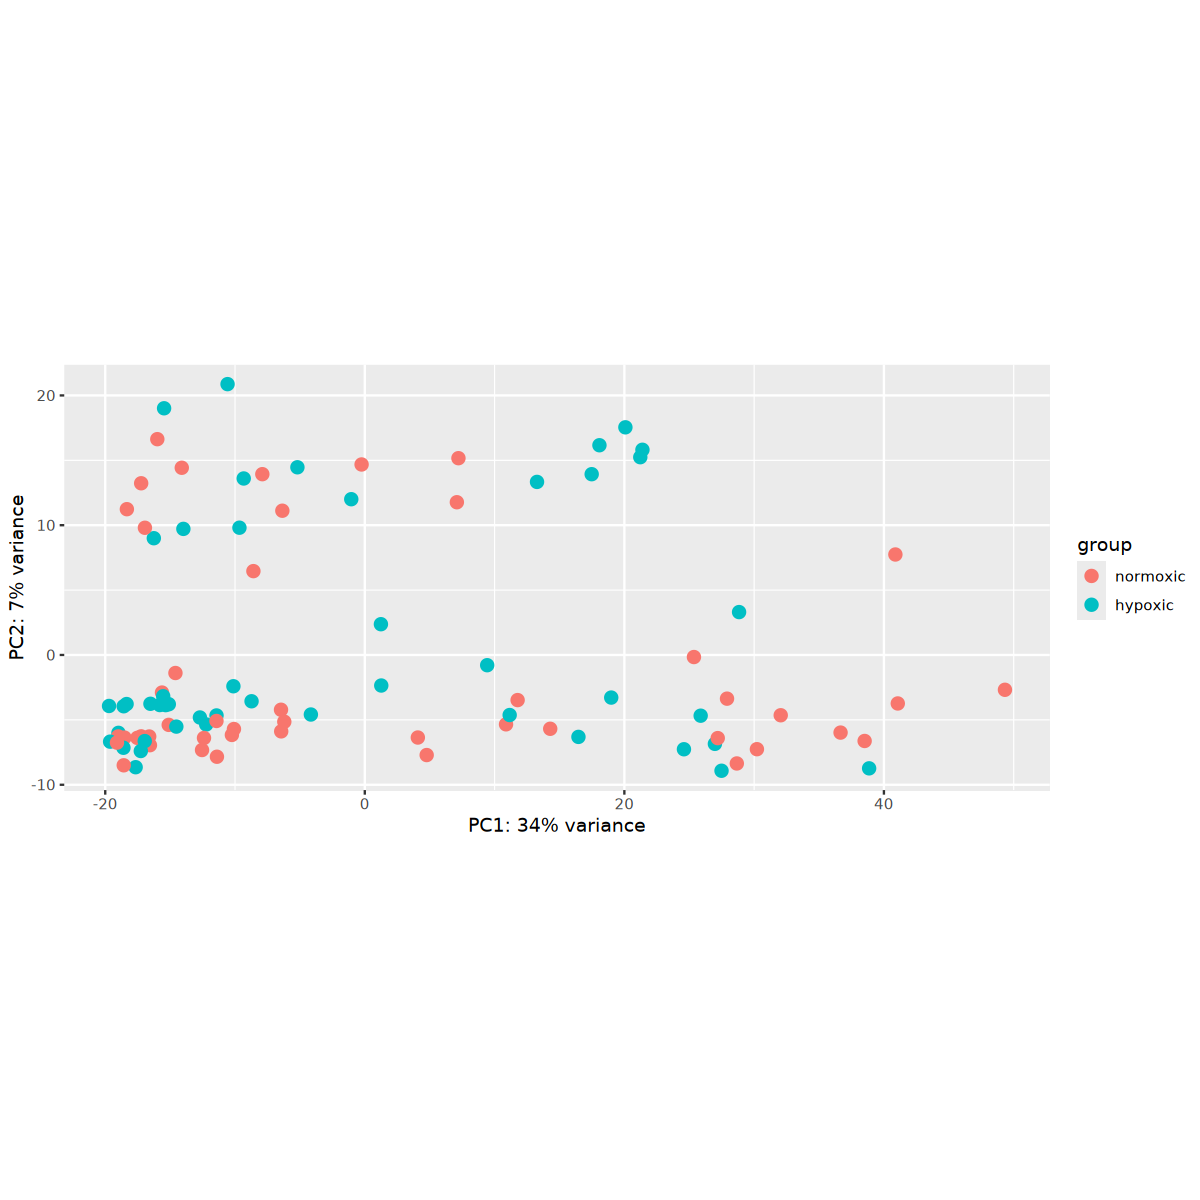

In [54]:
plotPCA(vsd, intgroup=c("Phase2_DO"))

using ntop=500 top features by variance



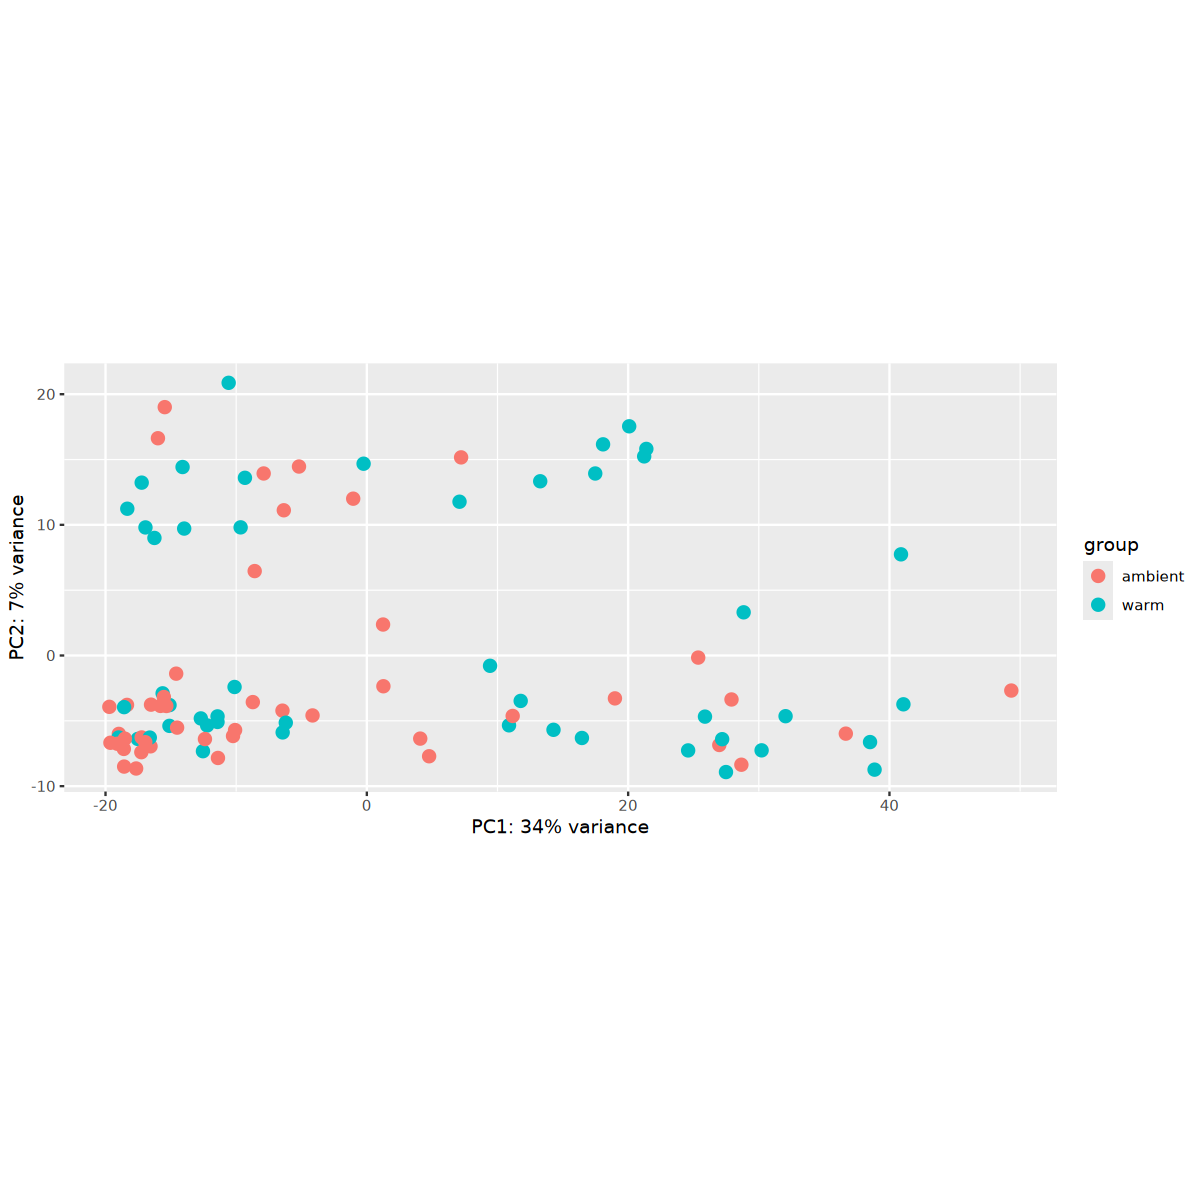

In [55]:
plotPCA(vsd, intgroup=c("Phase2_temp"))

using ntop=500 top features by variance



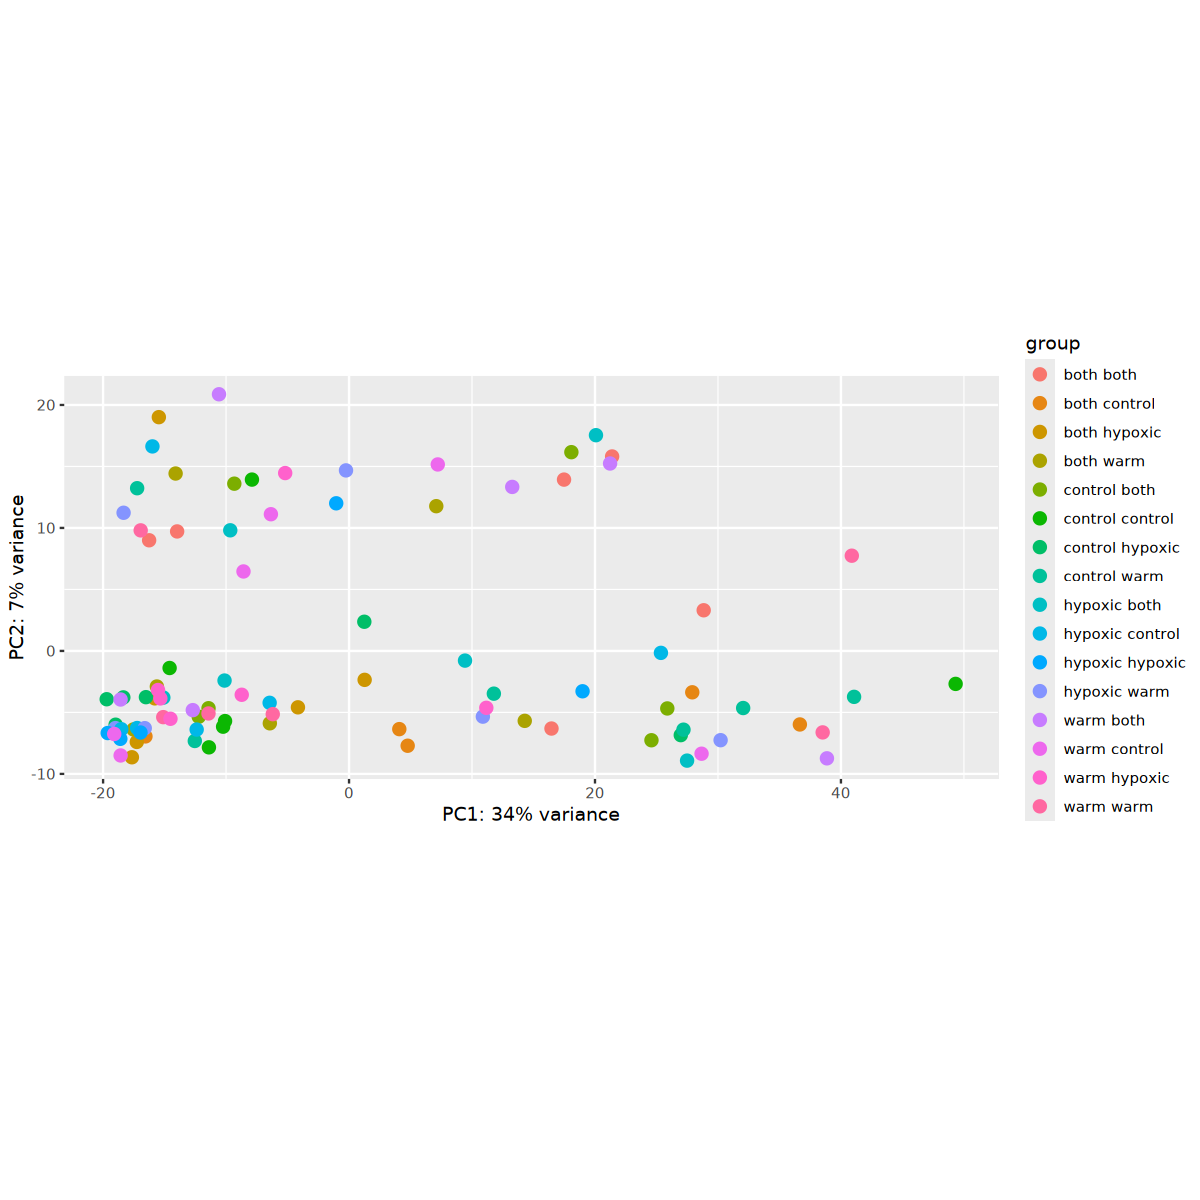

In [56]:
plotPCA(vsd, intgroup=c("complete_trtmt"))

### nMDS
normalize and transform DESeq object using vst (variance stabilized expression matrix)

In [57]:
# variance stabilizing transformation
vsd <- vst(dds_rm)
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.496853,11.279064,11.263041,11.116070,10.810639,10.792088,11.217942,10.880784,10.994176,11.017908,⋯,11.725264,10.425867,10.931954,11.412175,11.267052,11.076930,11.222606,11.060513,11.697631,11.532703
LOC144621269,8.439720,10.994298,11.435360,10.315852,11.476449,10.475679,12.764908,10.887167,8.173134,7.995203,⋯,13.885486,7.912849,8.003402,9.975536,8.361289,8.737783,13.432724,8.148615,9.613395,13.410109
LOC111120925,8.528030,8.206905,9.672180,8.040350,8.144586,8.015825,7.734247,7.834654,7.734247,7.832994,⋯,9.525414,7.734247,7.924706,9.692451,8.584642,8.270262,7.971343,7.838173,8.074911,8.040109
LOC144621283,9.835356,10.292287,10.317148,10.130632,10.231305,10.531169,10.495088,9.684199,10.053658,10.160757,⋯,9.935104,10.442444,10.171648,10.319470,10.288261,10.198693,9.909962,10.825529,9.925370,9.958732
LOC144621276,13.435118,13.478856,13.653303,13.485289,13.766009,13.888565,13.701039,13.199064,13.744223,13.418008,⋯,14.014445,13.290327,13.838298,13.531336,13.075454,13.262130,13.923543,13.356844,13.403228,13.353242
LOC111115920,8.947200,9.022856,8.912533,8.739305,8.651553,8.593992,8.492771,9.542666,8.701216,9.394105,⋯,8.616179,8.718116,9.223466,8.851757,9.573591,9.576739,9.025071,9.201455,8.677631,8.800430


In [58]:
# calculate sample distances
sample_dists <- assay(vsd) %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,86.56810,87.22173,83.47481,88.63009,88.10239,95.32332,89.81920,89.41516,79.84088,⋯,99.24855,85.96867,75.04929,79.91014,76.17661,79.67118,95.69733,82.60674,81.04282,100.51813
B1_W5_O50,86.56810,0.00000,80.39758,71.89514,67.99158,74.42133,75.31071,88.74562,84.83824,83.60988,⋯,82.20181,92.59698,85.50910,85.10572,87.83378,84.63333,85.96436,86.86770,80.48348,81.21353
B2_B5_O51,87.22173,80.39758,0.00000,89.04158,82.57768,88.91392,84.57391,96.84477,100.15624,96.76732,⋯,87.70783,103.49966,94.12407,80.87071,92.18615,94.49595,88.66025,94.98260,90.34791,83.78002
B2_C4_O40,83.47481,71.89514,89.04158,0.00000,75.75506,75.06597,83.19391,86.74323,89.94023,78.46778,⋯,86.69455,87.48649,83.49393,82.94536,83.57674,82.01870,92.18719,81.86287,65.25446,88.69036
B3_B4_O41,88.63009,67.99158,82.57768,75.75506,0.00000,79.49220,81.10213,93.89533,81.26346,87.55225,⋯,81.84035,96.18041,86.44743,88.82684,93.04192,89.51554,82.91856,90.81420,84.20383,83.36987
B3_C3_O30,88.10239,74.42133,88.91392,75.06597,79.49220,0.00000,85.80700,93.44240,93.48995,89.07802,⋯,90.21901,95.72079,81.07492,90.88967,90.68173,87.98255,95.92734,84.83340,85.09082,93.64867


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor,group
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>
B1_B1_O01,15.910247,6.357548,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0589461,both both
B1_W5_O50,-15.108816,-4.709899,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9973812,both warm
B2_B5_O51,-20.226883,-6.172679,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0525815,both both
B2_C4_O40,-2.880726,4.583532,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1432401,both control
B3_B4_O41,-17.785016,-8.965554,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8649451,both both
B3_C3_O30,-3.851368,-15.994772,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8602578,both control


In [59]:
mds$Phase1_treatment <- factor(mds$Phase1_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

mds$Phase2_treatment <- factor(mds$Phase2_treatment, levels = c('control', 'warm', 'hypoxic', 'both'))

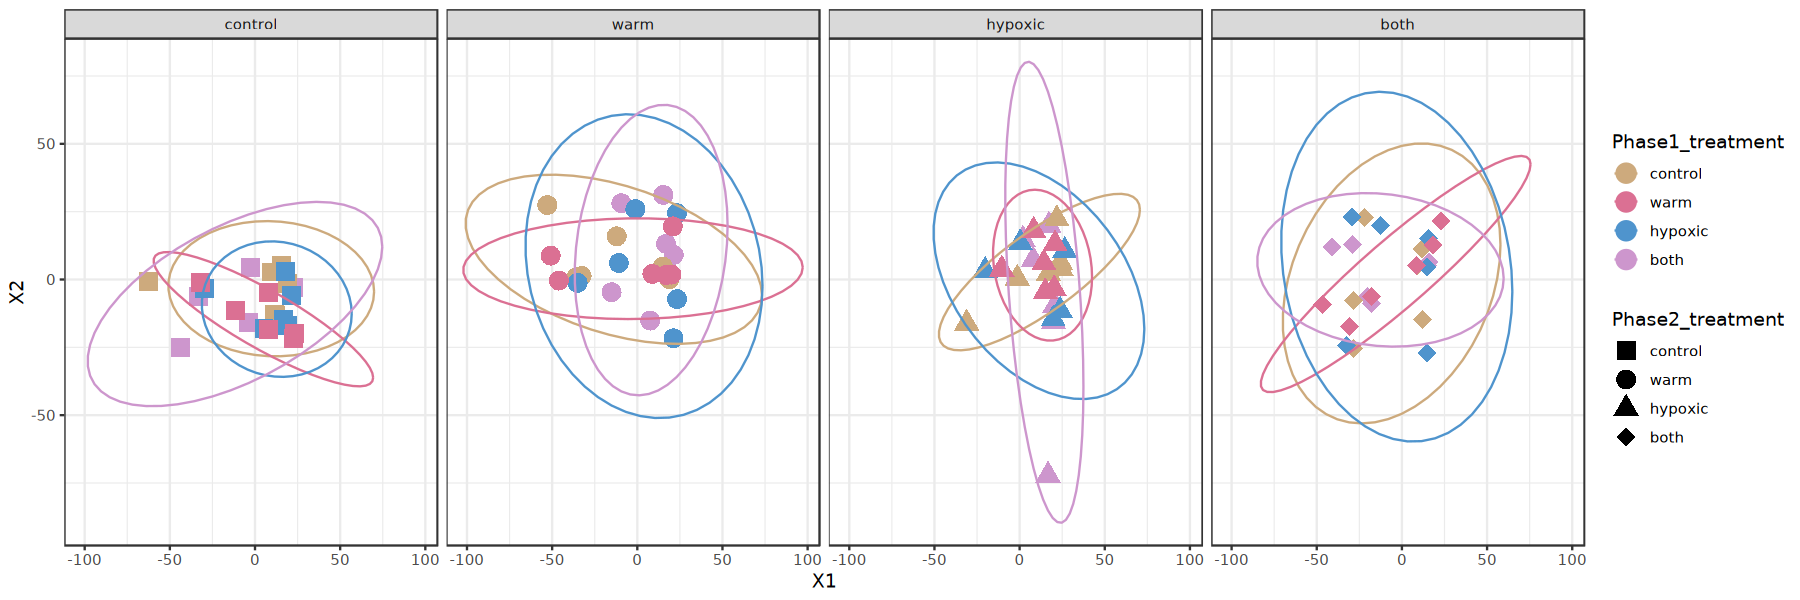

In [60]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw()

nmds.plot

facet by phase 2 treatment

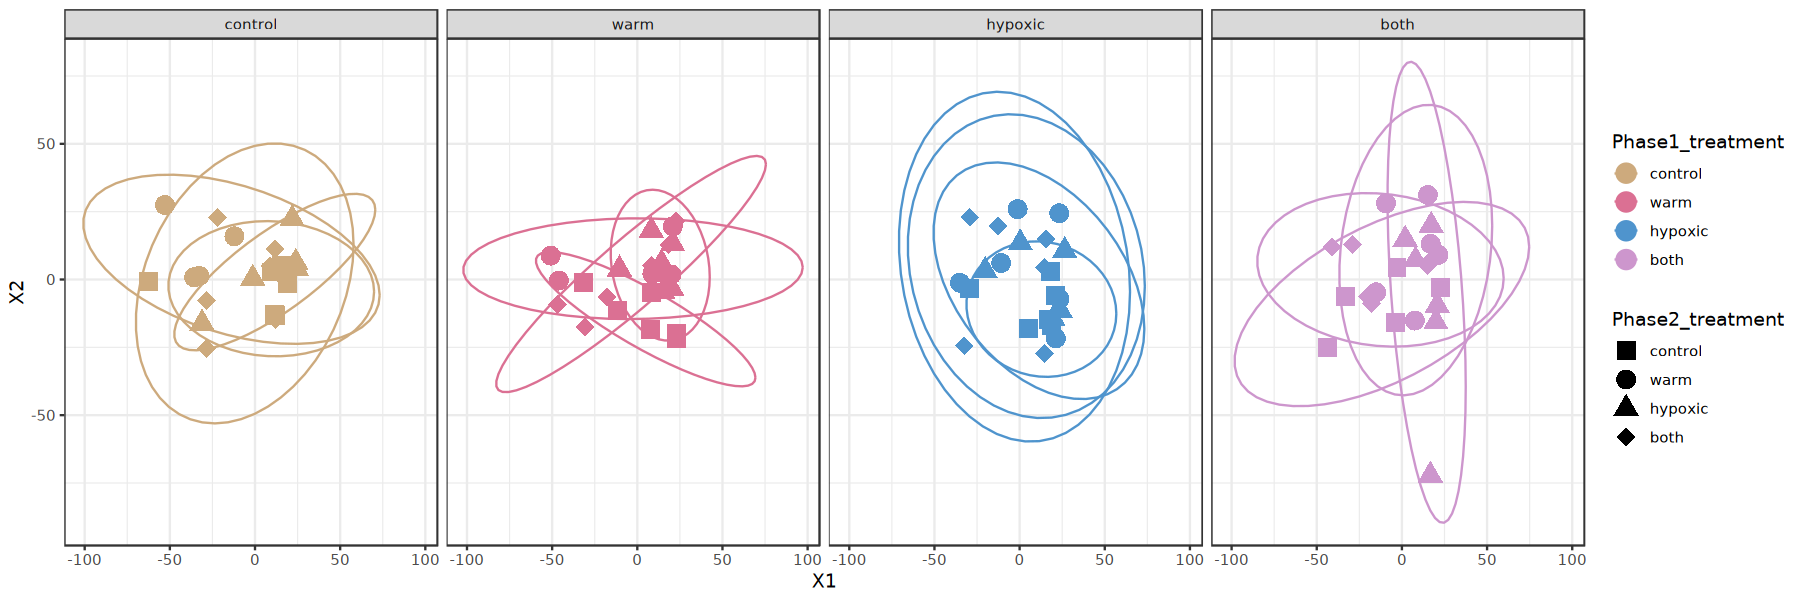

In [61]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
theme_bw()

nmds.plot

facet by phase 1 treatment

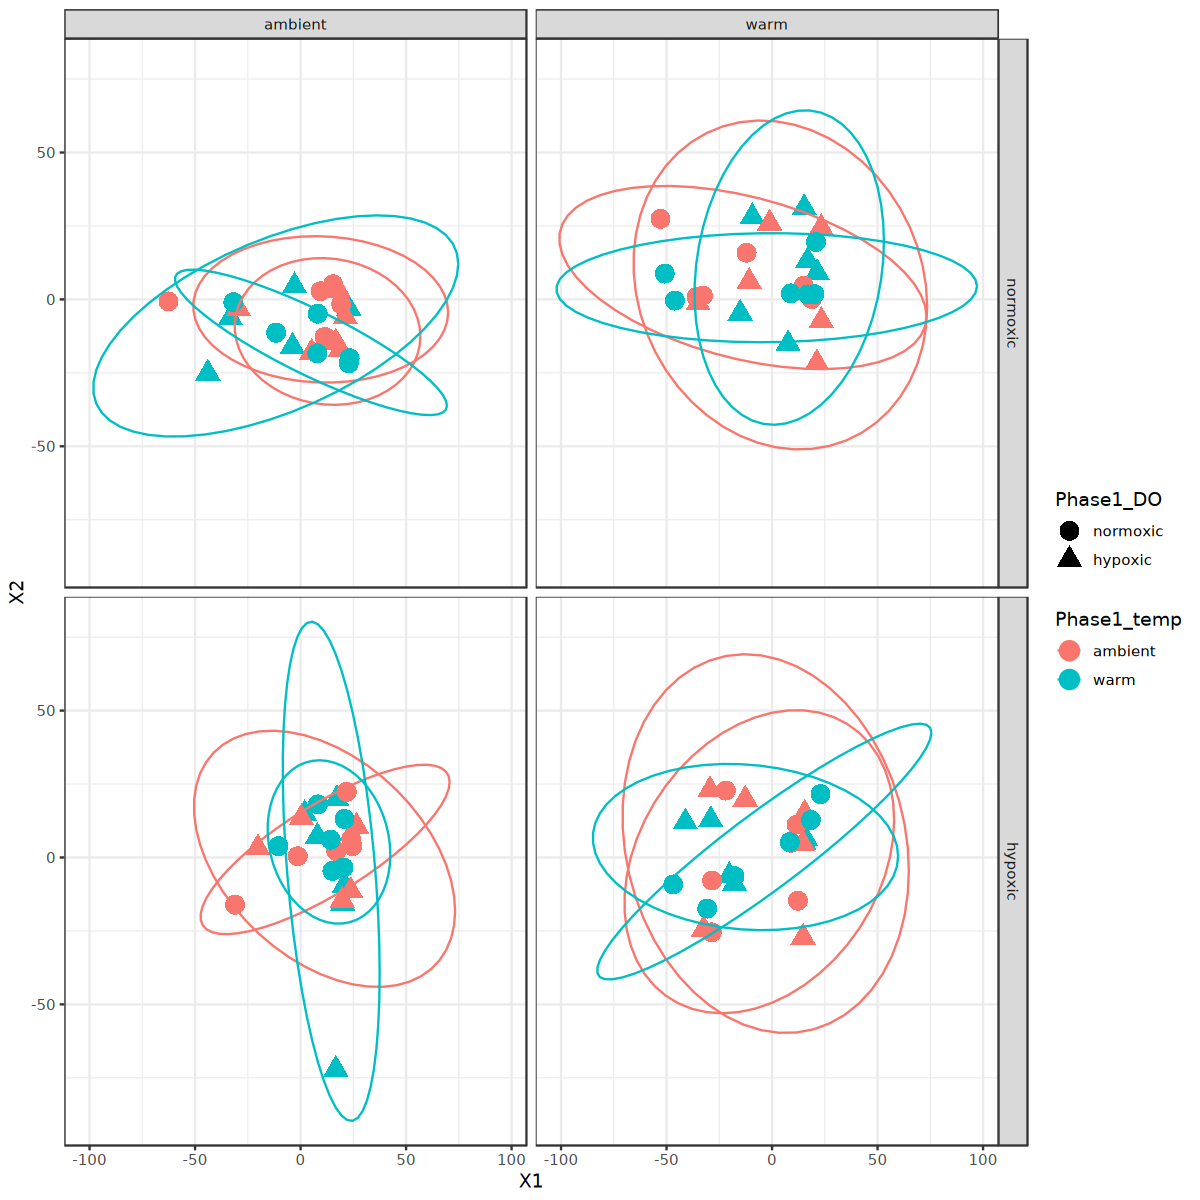

In [62]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
theme_bw()

nmds.plot

facet by phase 2 temp (columns) and DO (rows) treatments, colored by phase 1 temp (colors) and DO (shape)

### permANOVA

differences in centroid location(position) between two groups

In [63]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,3564.209,0.009531342,0.9000808,0.610
Phase1_DO,1,3293.576,0.008807621,0.8317371,0.800
Phase2_temp,1,9819.132,0.026258143,2.4796562,0.001
Phase2_DO,1,6637.064,0.017748714,1.6760785,0.019
Phase1_temp:Phase1_DO,1,2955.806,0.007904363,0.7464390,0.929
Phase1_temp:Phase2_temp,1,3052.202,0.008162142,0.7707821,0.908
Phase1_DO:Phase2_temp,1,3305.508,0.008839530,0.8347504,0.759
Phase1_temp:Phase2_DO,1,3111.036,0.008319475,0.7856396,0.877
Phase1_DO:Phase2_DO,1,4192.396,0.011211228,1.0587189,0.313


significant effects:
- phase2_temp (2.5% of variance)
- phase2_DO (1.7% of variance)
- phase2_temp:phase2_DO (1.7% variance)

### heatmap 
of sample-to-sample distances using the variance stabilizing transformed values


following [RNA-seq workflow](https://master.bioconductor.org/packages/release/workflows/vignettes/rnaseqGene/inst/doc/rnaseqGene.html) from Mike Love

In [64]:
# normalization & transformation
vsd <- vst(dds_rm)

# calculate sample distances
sample_dists <- dist(t(assay(vsd)))
head(sample_dists)

[1] 86.56810 87.22173 83.47481 88.63009 88.10239 95.32332

In [65]:
head(vsd)

class: DESeqTransform 
dim: 6 94 
metadata(1): version
assays(1): ''
rownames(6): LOC144621260 LOC144621269 ... LOC144621276 LOC111115920
rowData names(78): baseMean baseVar ... maxCooks dispFit
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(11): Phase1_treatment Phase1_temp ... sizeFactor group

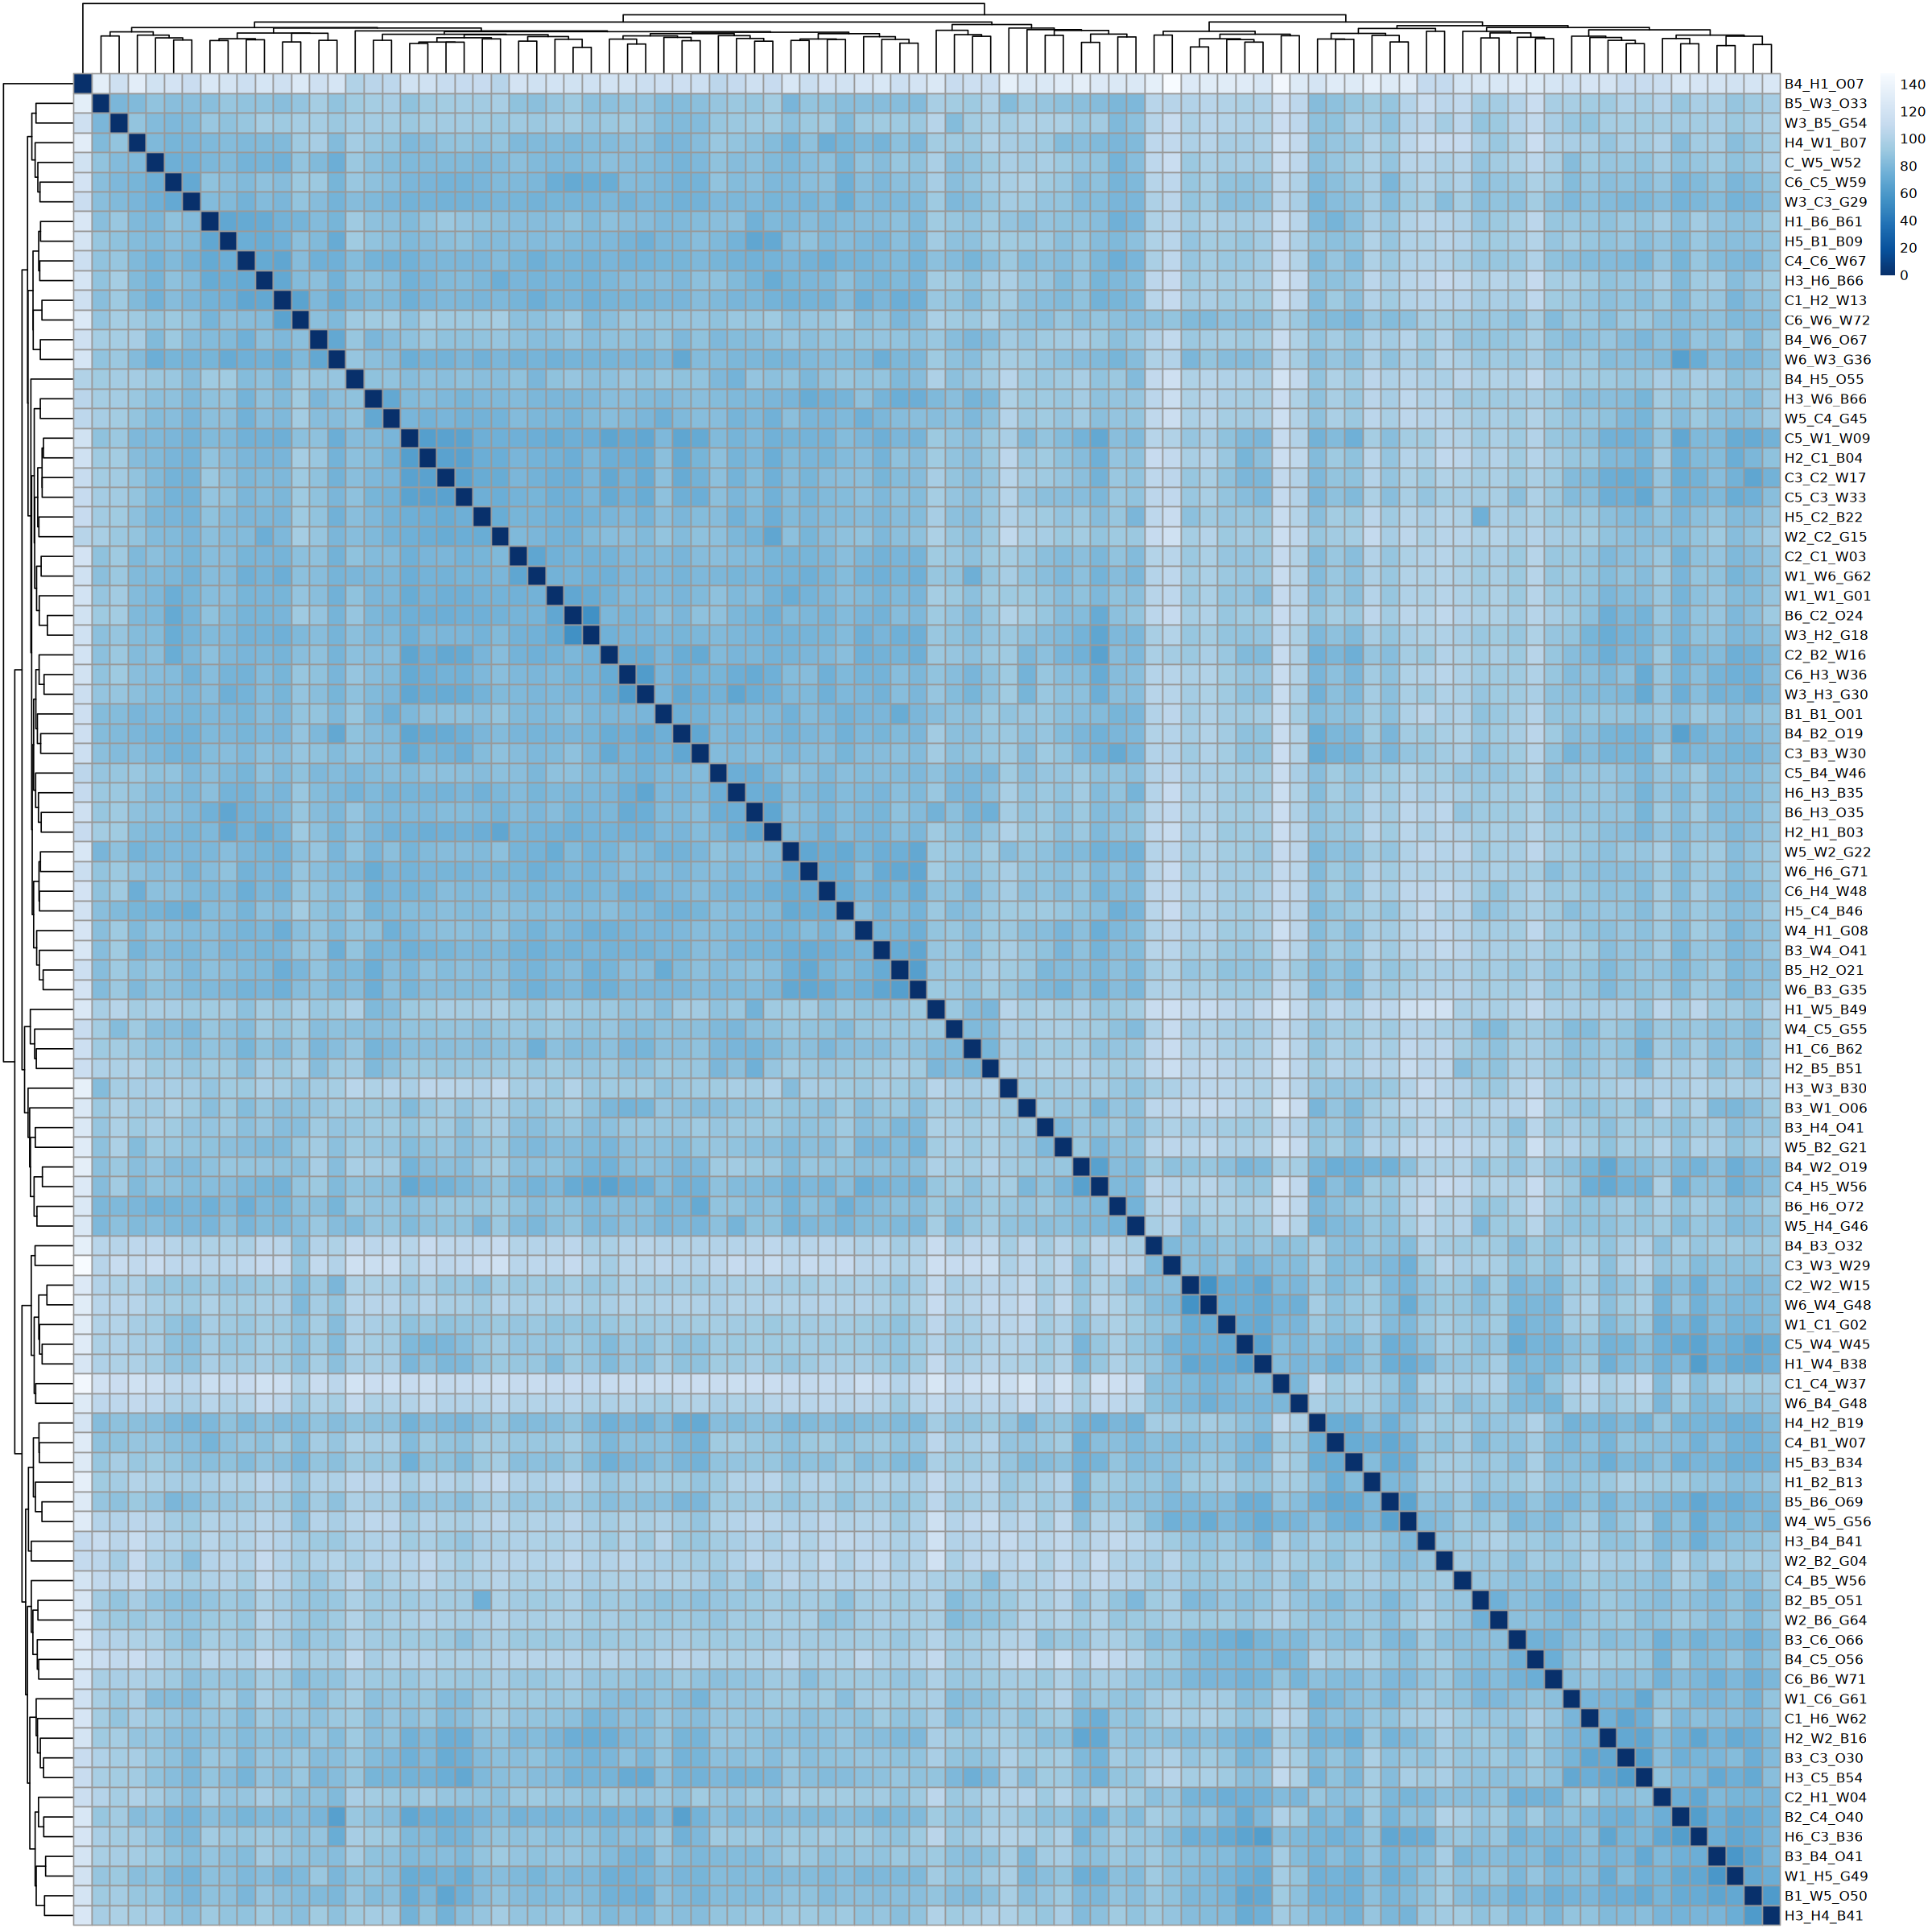

In [66]:
options(repr.plot.width=20, repr.plot.height=20)

sampleDistMatrix <- as.matrix(sample_dists)
rownames(sampleDistMatrix) <- paste(colnames(vsd))
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows = sample_dists,
         clustering_distance_cols = sample_dists,
         col = colors)

## Pairwise comparisons

### 1. Effect of single exposure on GE after a period of recovery
- CC vs. WC
- CC vs. HC
- CC vs. BC

**CC vs. WC**

In [72]:
options(repr.plot.width = 5, repr.plot.height = 10)

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.183291e-04,0.006460107,-0.71557958,0.4742510,0.9998501,0.9990182,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.001644e-03,0.055107257,-1.33839194,0.1807687,0.9998501,0.9841609,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.566516e-05,0.025786641,-0.04032524,0.9678338,0.9998501,0.9956653,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-5.267354e-05,0.006279530,-0.30251288,0.7622611,0.9998501,0.9991531,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,5.978375e-05,0.006218510,0.29880472,0.7650890,0.9998501,0.9992324,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.432342e-04,0.009119253,1.05530869,0.2912842,0.9998501,0.9979864,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


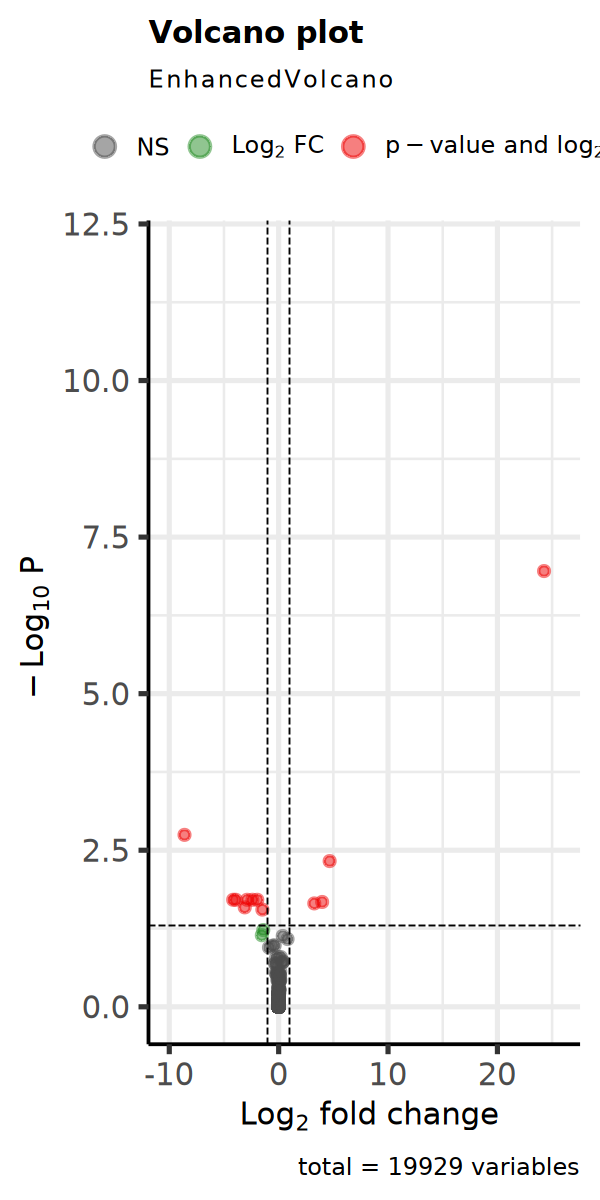

In [74]:
res.wc.cc <- lfcShrink(dds_rm, 
                       contrast= c('complete_trtmt', 'warm.control', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wc.cc)

EnhancedVolcano(res.wc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.cc <- merge(res.wc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.cc)[1] <- 'Gene'

head(res.wc.cc)

In [13]:
#write.csv(res.wc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wc_cc.csv', row.names = FALSE)

**CC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 4, 0.02%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-3.552409e-04,0.009616207,-1.69619449,0.08984905,0.9998756,0.9979352,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-6.311116e-03,0.151171955,-2.02060711,0.04332045,0.9998756,0.9478251,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.420614e-05,0.031787363,-0.02404413,0.98081741,0.9998756,0.9936553,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,3.542475e-05,0.006282366,0.20290518,0.83920915,0.9998756,0.9987627,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.441623e-05,0.006189026,0.12295850,0.90213996,0.9998756,0.9988832,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.445829e-05,0.007524108,0.11199905,0.91082416,0.9998756,0.9979895,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


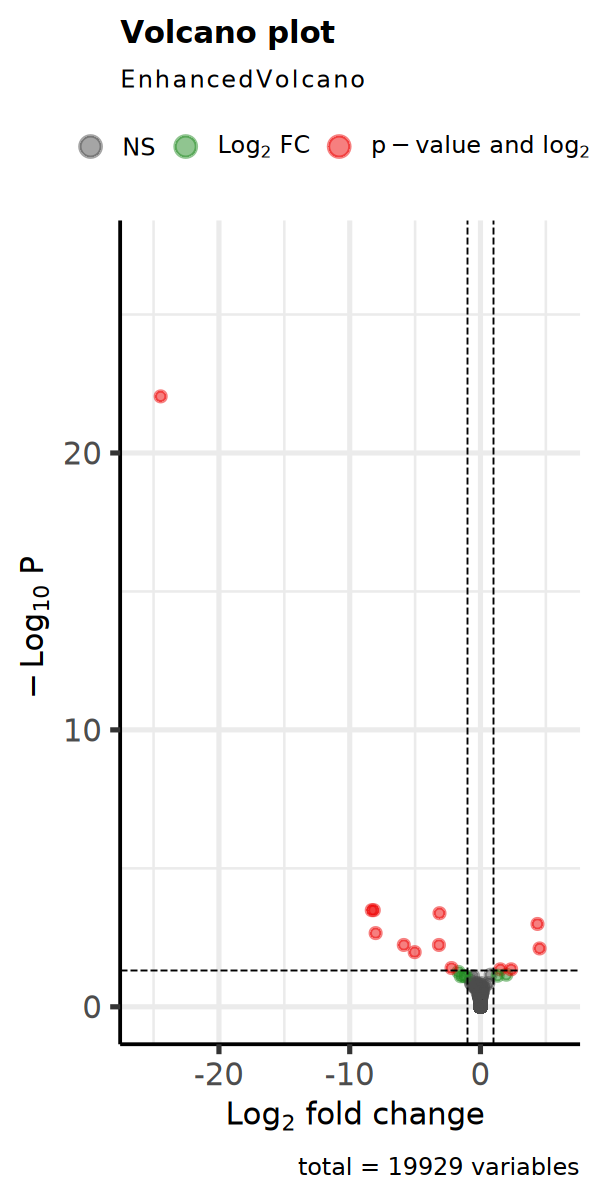

In [75]:
res.hc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.control', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hc.cc)

EnhancedVolcano(res.hc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.cc <- merge(res.hc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.cc)[1] <- 'Gene'

head(res.hc.cc)

In [49]:
#write.csv(res.hc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hc_cc.csv', row.names = FALSE)

**CC vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-2.928488e-04,0.007039711,-1.57974731,0.11416475,0.9998242,0.9994027,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-3.538927e-05,0.011927216,-0.47433006,0.63526456,0.9998242,0.9970159,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-5.014719e-04,0.044436988,-1.81816798,0.06903846,0.9998242,0.9850588,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,1.931066e-05,0.006832998,0.09777743,0.92210903,0.9998242,0.9996384,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,5.474021e-05,0.006827065,0.23747881,0.81228535,0.9998242,0.9996649,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-4.612264e-06,0.006926142,-0.04403759,0.96487444,0.9998242,0.9994135,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


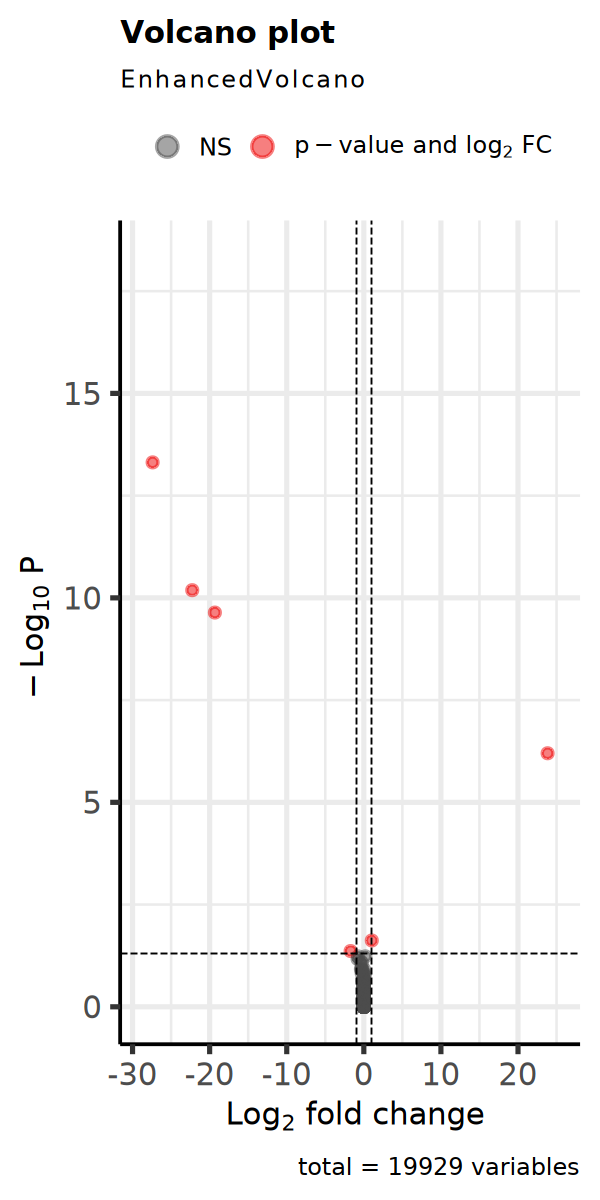

In [76]:
res.bc.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.control', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bc.cc)

EnhancedVolcano(res.bc.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.cc <- merge(res.bc.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.cc)[1] <- 'Gene'

head(res.bc.cc)

In [51]:
#write.csv(res.bc.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_cc.csv', row.names = FALSE)

### 2. Effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0049597163,0.08077044,-0.1852330,0.8530463,0.9878155,0.9987841,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0006778706,0.09297018,-0.1252528,0.9003234,0.9935485,0.9944510,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0033589036,0.09727415,-0.6368492,0.5242231,0.9453085,0.9907382,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0107699852,0.08002432,-0.3798000,0.7040939,0.9716541,0.9988107,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0173405600,0.07816841,-0.5487727,0.5831614,0.9565159,0.9988955,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0042440070,0.08458134,0.2592130,0.7954709,0.9833782,0.9980706,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


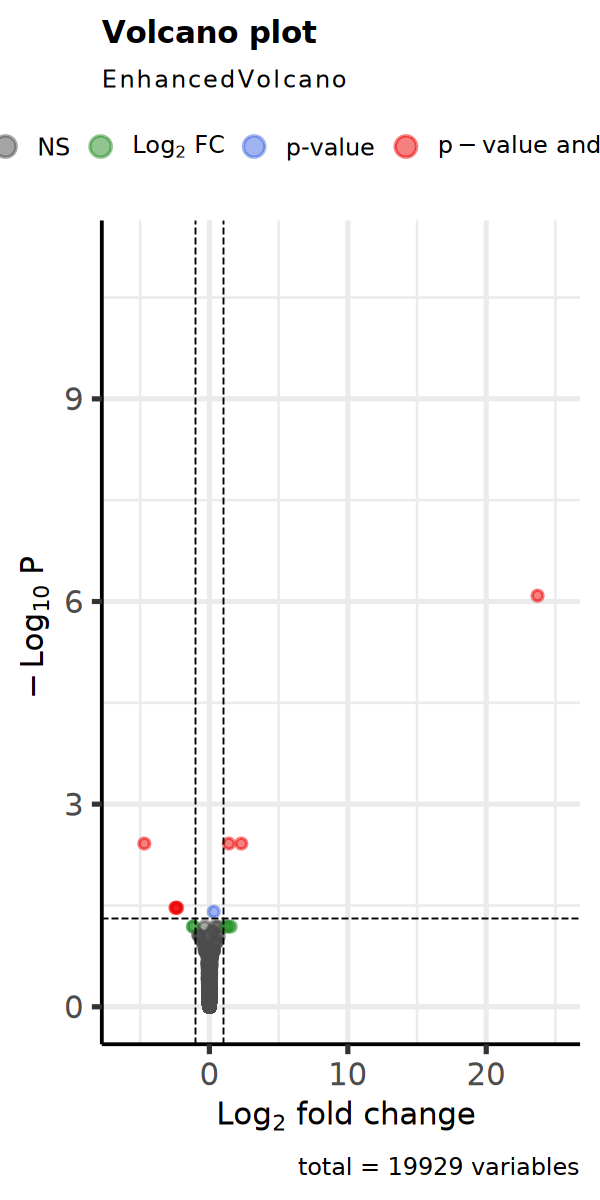

In [77]:
res.cw.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cw.cc)

EnhancedVolcano(res.cw.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.cc <- merge(res.cw.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.cc)[1] <- 'Gene'

head(res.cw.cc)

In [53]:
#write.csv(res.cw.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cw_cc.csv', row.names = FALSE)

**CC vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 4, 0.02%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.068357757,0.09631126,-1.9618182,0.04978366,0.6241133,0.9959723,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.015369656,0.15613518,-1.6368939,0.10165263,0.7123039,0.9657203,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.013751379,0.15411173,-1.5560157,0.11970435,0.7523645,0.9680222,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.024625365,0.08999409,-0.6885634,0.49109804,0.9111168,0.9976650,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.067259497,0.08915917,-1.6882293,0.09136722,0.7058113,0.9974438,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.002908299,0.09668858,0.1358427,0.89194563,0.9893608,0.9965714,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


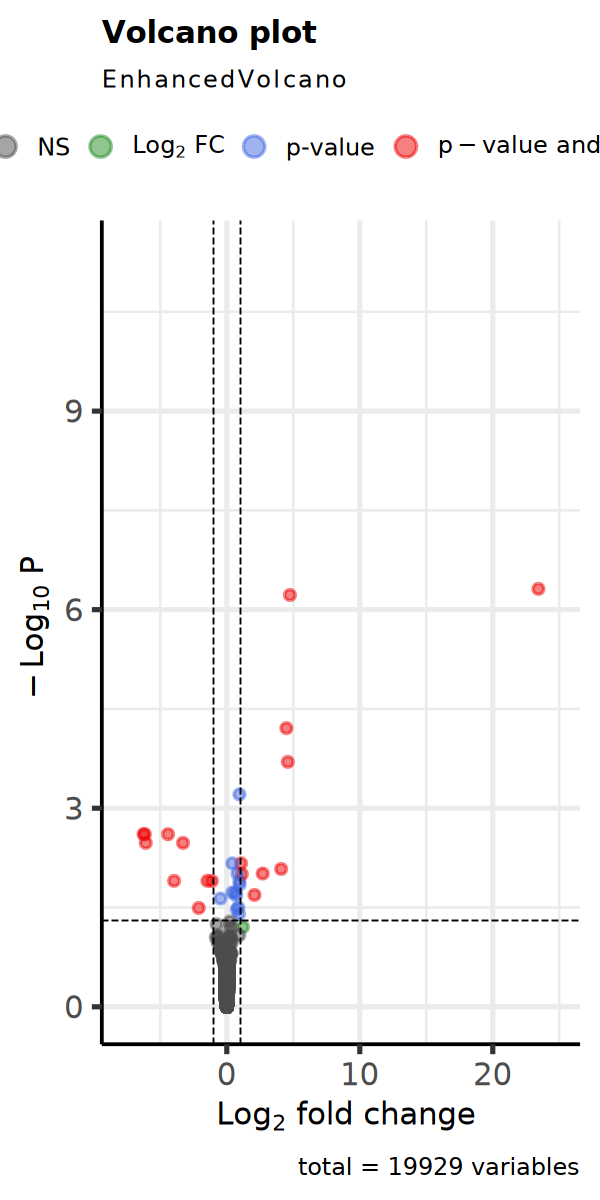

In [78]:
res.ch.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.ch.cc)

EnhancedVolcano(res.ch.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.cc <- merge(res.ch.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.cc)[1] <- 'Gene'

head(res.ch.cc)

In [55]:
#write.csv(res.ch.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/ch_cc.csv', row.names = FALSE)

**CC vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.057443451,0.1281285,-0.9156434,0.3598540,0.8343075,0.9956299,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.021304177,0.1868998,-1.0776973,0.2811688,0.7887820,0.9737064,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.017869948,0.1854609,0.9619486,0.3360754,0.8200919,0.9757667,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004568204,0.1177079,0.0743784,0.9407093,0.9913257,0.9964213,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.068487848,0.1183619,1.0392720,0.2986783,0.7993678,0.9962898,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.010540713,0.1442374,0.2220581,0.8242687,0.9708796,0.9942891,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


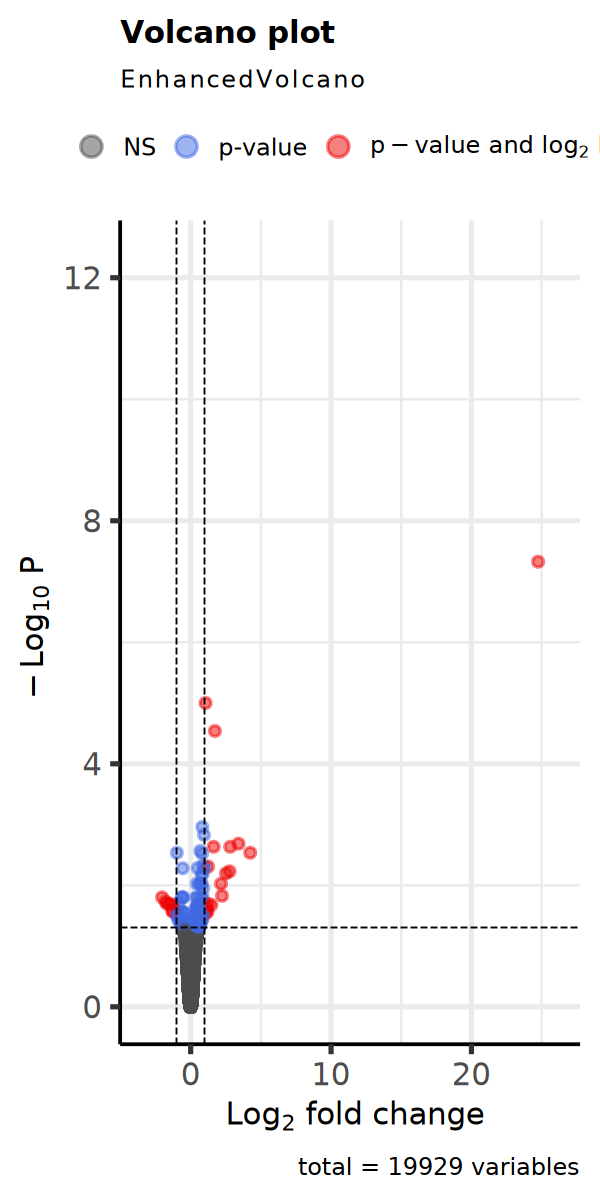

In [79]:
res.cb.cc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cb.cc)

EnhancedVolcano(res.cb.cc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cc <- merge(res.cb.cc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cc)[1] <- 'Gene'

head(res.cb.cc)

In [57]:
#write.csv(res.cb.cc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_cc.csv', row.names = FALSE)

### 3. Timing of Stress Exposure
How does GE change depending on when stress is experienced (when all oysters only experience stress once)?
- CH vs. HC
- CW vs. WC
- CB vs. BC

**CH vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.015%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.135910e-03,0.03235785,-0.26549956,0.79062465,0.9906623,0.9985770,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,5.698776e-04,0.05011397,0.38375162,0.70116255,0.9906623,0.9914548,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-4.032054e-03,0.10285416,-1.53196152,0.12553193,0.9055940,0.9728620,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-4.148653e-03,0.03321283,-0.89130421,0.37276599,0.9720088,0.9984835,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-1.056722e-02,0.03797473,-1.81114939,0.07011773,0.8831704,0.9983329,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,6.208535e-05,0.03374292,0.02380662,0.98100686,0.9997068,0.9979213,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


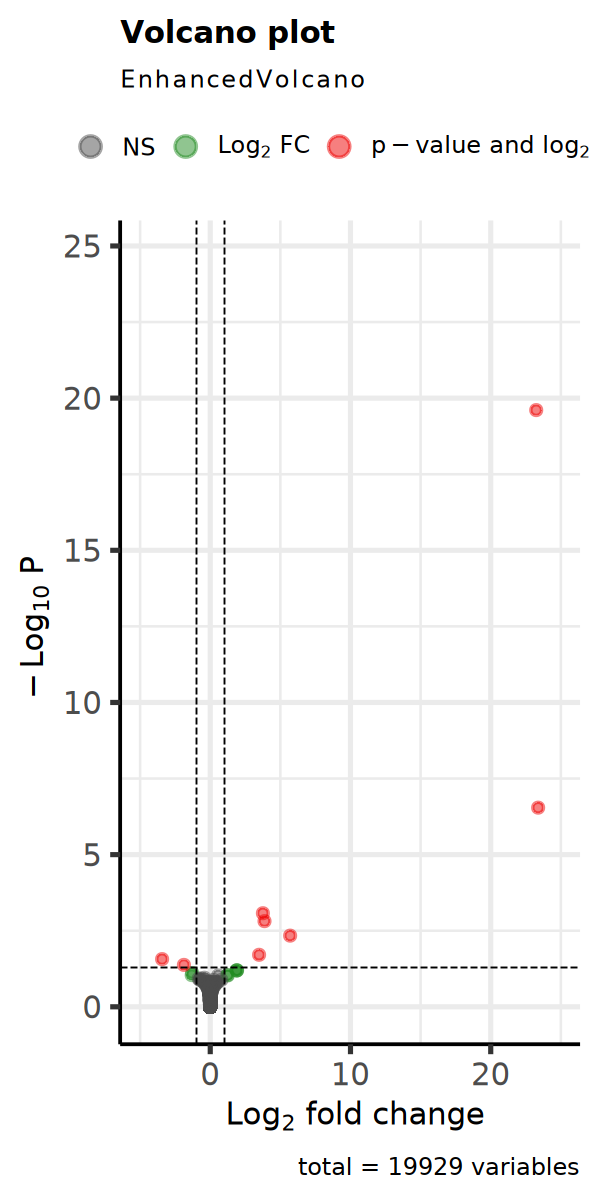

In [80]:
res.ch.hc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.hypoxic', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.ch.hc)

EnhancedVolcano(res.ch.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ch.hc <- merge(res.ch.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ch.hc)[1] <- 'Gene'

head(res.ch.hc)

In [59]:
#write.csv(res.ch.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/ch_hc.csv', row.names = FALSE)

**CW vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.041487616,0.1384150,0.53025331,0.5959363,0.8784104,0.9985455,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.024104075,0.1853593,1.21313973,0.2250764,0.6602043,0.9860584,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.010865217,0.1778911,-0.59649686,0.5508434,0.8586767,0.9916649,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.006161001,0.1341242,-0.07729592,0.9383881,0.9865248,0.9987008,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.069813330,0.1267545,-0.84754200,0.3966931,0.7826093,0.9986950,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.046095802,0.1596793,-0.79546095,0.4263454,0.7981914,0.9974488,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


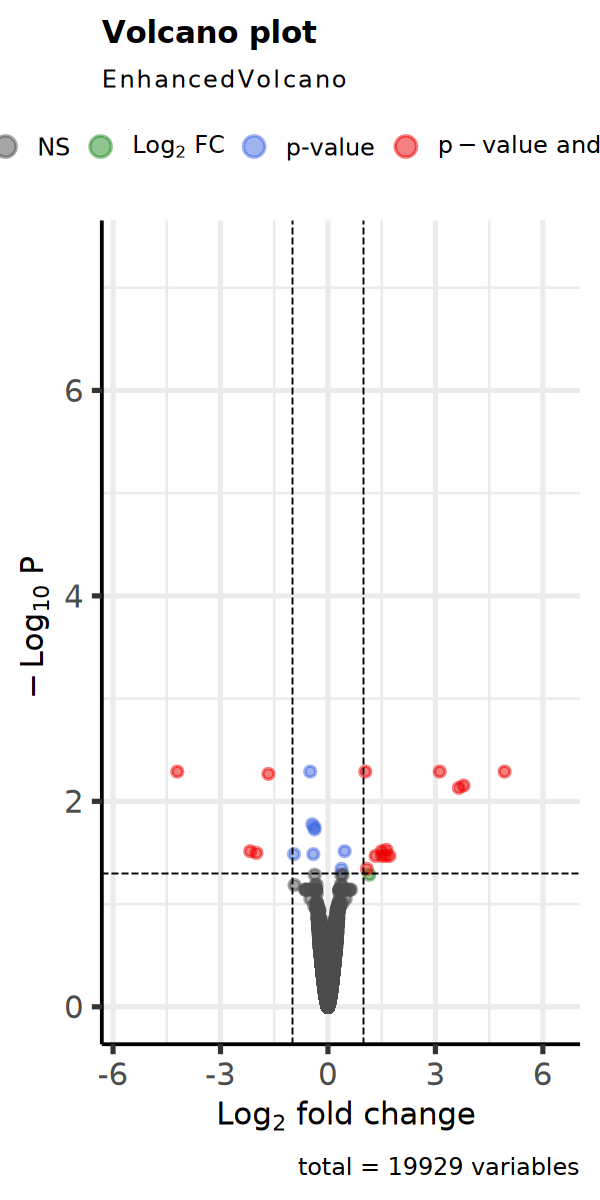

In [81]:
res.cw.wc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.warm', 'warm.control'), # WC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cw.wc)

EnhancedVolcano(res.cw.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.wc <- merge(res.cw.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.wc)[1] <- 'Gene'

head(res.cw.wc)

In [62]:
#write.csv(res.cw.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cw_wc.csv', row.names = FALSE)

**CB vs. BC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.015%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.040190122,0.1244107,0.70657339,0.479831632,0.8791776,0.9961249,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.010378412,0.1798523,-0.55321921,0.580113316,0.9136800,0.9819211,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.112035938,0.5356941,2.73076203,0.006318808,0.2133777,0.8535155,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.001498896,0.1149478,-0.02682886,0.978596233,0.9956018,0.9967120,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.044377418,0.1126566,0.75342653,0.451193645,0.8647201,0.9966957,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.011574112,0.1444721,0.25569466,0.798186618,0.9618094,0.9946755,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


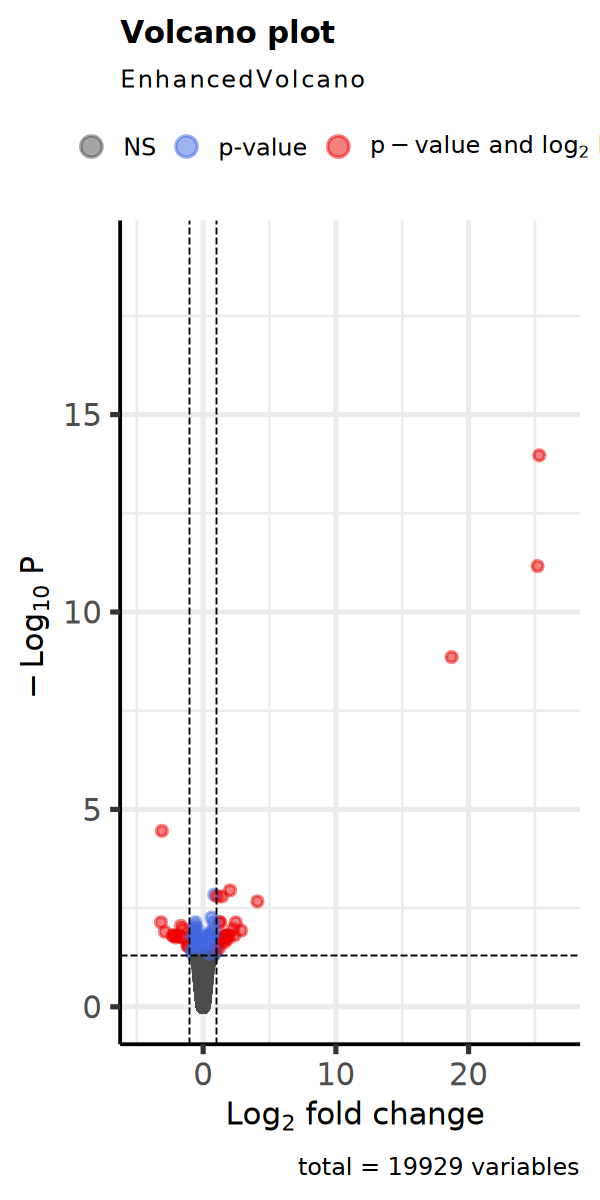

In [82]:
res.cb.bc <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'control.both', 'both.control'), # BC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cb.bc)

EnhancedVolcano(res.cb.bc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bc <- merge(res.cb.bc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bc)[1] <- 'Gene'

head(res.cb.bc)

In [64]:
#write.csv(res.cb.bc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_bc.csv', row.names = FALSE)

### 4. No stress vs. most stress
- CC vs. WW
- CC vs. HH
- CC vs. BB

**CC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0010361891,0.03141680,-0.2557644,0.7981327,0.99914,0.9991087,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0004115197,0.04240654,-0.3824526,0.7021257,0.99914,0.9941865,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0001437089,0.04256599,-0.1364484,0.8914668,0.99914,0.9951030,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0054819267,0.03157032,-1.2533705,0.2100709,0.99914,0.9989506,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0036277257,0.03125741,-0.7169065,0.4734318,0.99914,0.9991860,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0015876961,0.03209670,0.6794796,0.4968340,0.99914,0.9983563,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


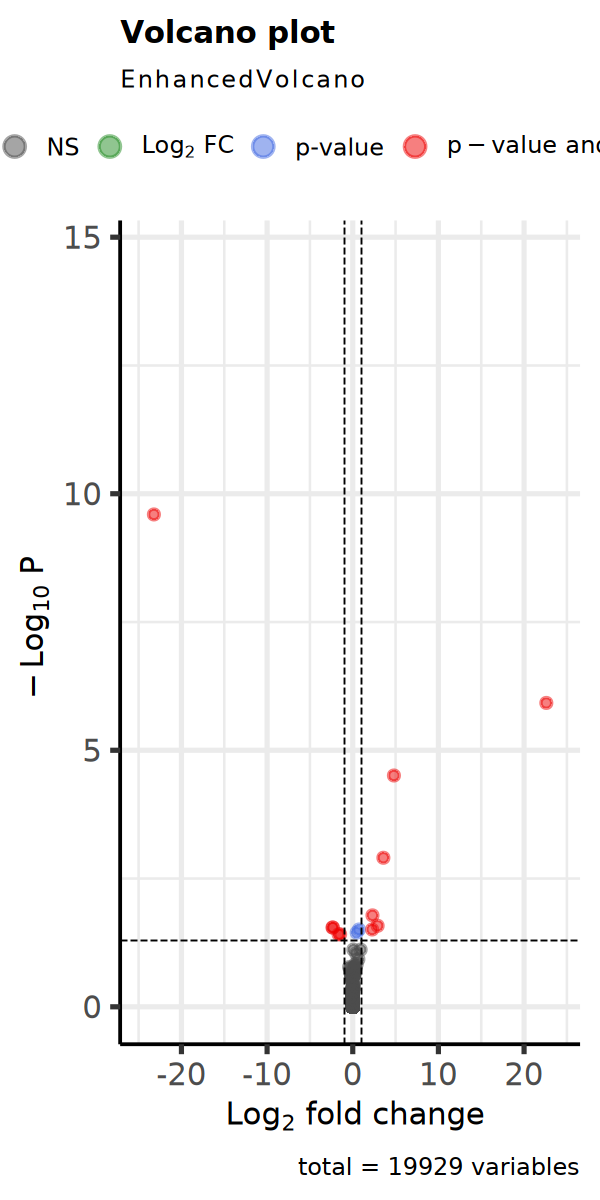

In [83]:
res.cc.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cc.ww)

EnhancedVolcano(res.cc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.ww <- merge(res.cc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.ww)[1] <- 'Gene'

head(res.cc.ww)

In [66]:
#write.csv(res.cc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/ww_cc.csv', row.names = FALSE)

**CC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0422172355,0.08794539,-1.50837600,0.1314583,0.7804842,0.9973934,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0119811508,0.14894903,-1.60482170,0.1085330,0.7466052,0.9658456,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0007344657,0.09940553,0.13358797,0.8937284,0.9910490,0.9912557,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0059620333,0.08185490,0.21071847,0.8331070,0.9844031,0.9982722,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0011363090,0.07915301,-0.03667037,0.9707478,0.9988785,0.9984342,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0061513077,0.08814332,0.36315779,0.7164870,0.9709885,0.9970434,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


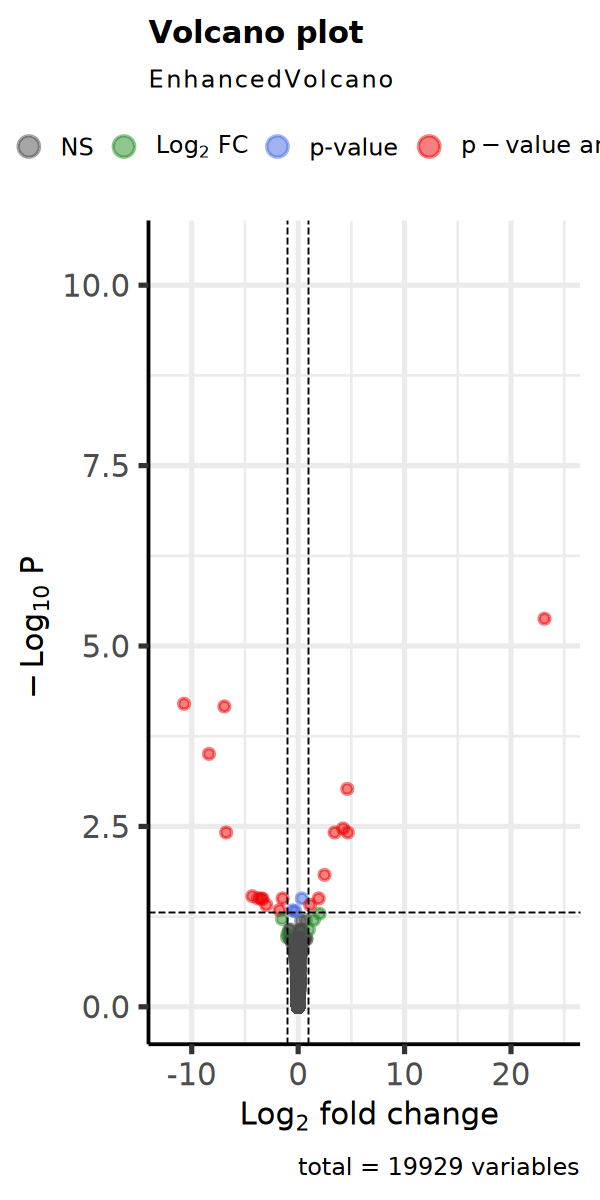

In [84]:
res.cc.hh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.control'), # CC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cc.hh)

EnhancedVolcano(res.cc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.hh <- merge(res.cc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.hh)[1] <- 'Gene'

head(res.cc.hh)

In [68]:
#write.csv(res.cc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hh_cc.csv', row.names = FALSE)

**CC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 2, 0.01%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032559743,0.09881168,0.83053048,0.4062389,0.8747798,0.9952141,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007221924,0.13967083,0.62081754,0.5347197,0.9144176,0.9788021,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.007467129,0.14231626,-0.66718618,0.5046532,0.9048363,0.9775362,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003665704,0.09567727,0.09030156,0.9280476,0.9937087,0.9960093,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004011083,0.09218043,0.09101121,0.9274837,0.9937087,0.9962997,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007220134,0.10744413,0.27457081,0.7836460,0.9711542,0.9934539,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


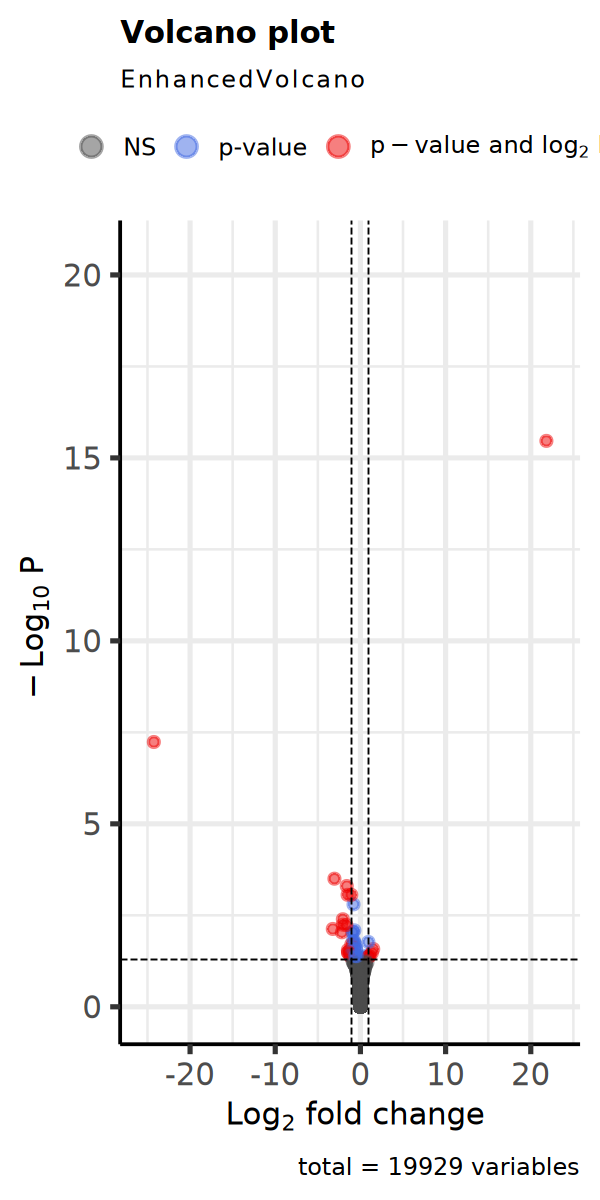

In [85]:
res.cc.bb <- lfcShrink(dds_rm, coef='complete_trtmt_control.control_vs_both.both', # BB is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cc.bb)

EnhancedVolcano(res.cc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cc.bb <- merge(res.cc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cc.bb)[1] <- 'Gene'

head(res.cc.bb)

switch LFC direction so CC is the baseline (deseq recognizes as bb as the baseline rn)

In [86]:
cc.bb.df <- as.data.frame(res.cc.bb) %>% # create df
mutate(log2FoldChange = log2FoldChange * -1) # multiple by -1 to make pos to neg and vice versa 

# validate
head(res.cc.bb)
head(cc.bb.df)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.032559743,0.09881168,0.83053048,0.4062389,0.8747798,0.9952141,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007221924,0.13967083,0.62081754,0.5347197,0.9144176,0.9788021,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.007467129,0.14231626,-0.66718618,0.5046532,0.9048363,0.9775362,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003665704,0.09567727,0.09030156,0.9280476,0.9937087,0.9960093,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.004011083,0.09218043,0.09101121,0.9274837,0.9937087,0.9962997,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.007220134,0.10744413,0.27457081,0.7836460,0.9711542,0.9934539,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.032559743,0.09881168,0.83053048,0.4062389,0.8747798,0.9952141,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.007221924,0.13967083,0.62081754,0.5347197,0.9144176,0.9788021,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.007467129,0.14231626,-0.66718618,0.5046532,0.9048363,0.9775362,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003665704,0.09567727,0.09030156,0.9280476,0.9937087,0.9960093,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.004011083,0.09218043,0.09101121,0.9274837,0.9937087,0.9962997,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.007220134,0.10744413,0.27457081,0.7836460,0.9711542,0.9934539,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


In [71]:
#write.csv(cc.bb.df, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bb_cc.csv', row.names = FALSE)

### 5. Effect of initial exposure on response in later exposure
(also gets at the effect of priming to stress)

#### 5A. Matched stressors
Oyster is primed with a stress, and experiences the *same* stressor again
- HH vs. CH
- WW vs. CW
- BB vs. CB

**HH vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.015%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,9.743818e-05,0.008413785,0.36211238,0.7172681,0.9990715,0.9963698,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-8.300301e-05,0.056143086,-0.04411453,0.9648131,0.9990715,0.9845565,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,9.640547e-03,0.182443831,1.61736006,0.1058006,0.9990715,0.9237064,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,2.566961e-04,0.009078034,0.86721688,0.3858232,0.9990715,0.9961886,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,6.058047e-04,0.011754619,1.57299580,0.1157198,0.9990715,0.9960394,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,6.996564e-05,0.011896681,0.23360638,0.8152906,0.9990715,0.9944571,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


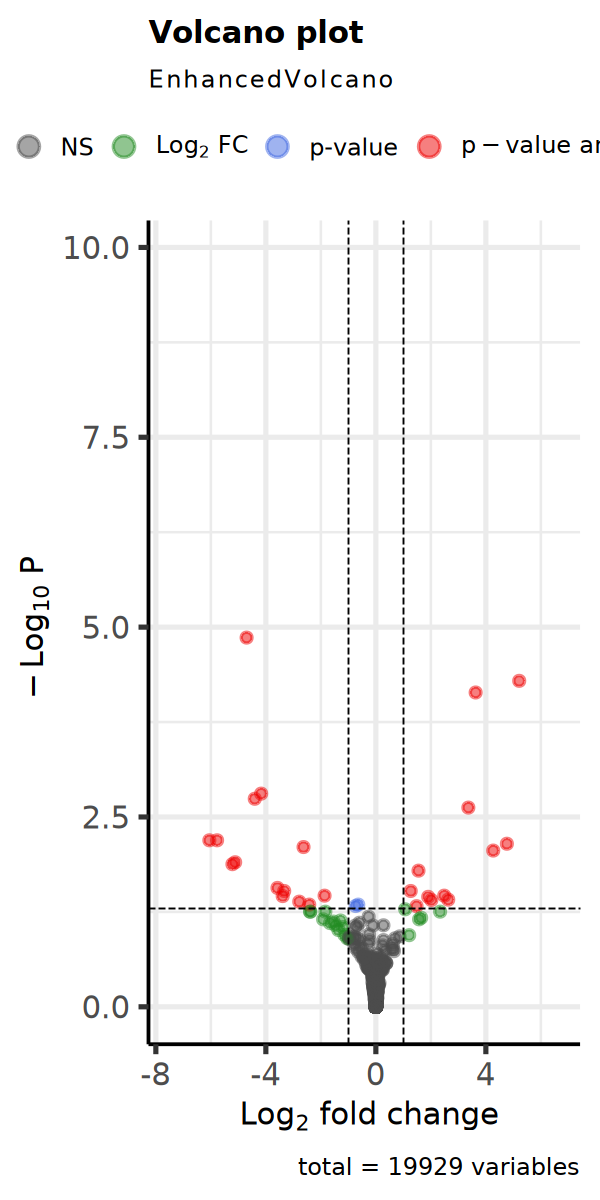

In [87]:
res.hh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'hypoxic.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hh.ch)

EnhancedVolcano(res.hh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.ch <- merge(res.hh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.ch)[1] <- 'Gene'

head(res.hh.ch)

In [73]:
#write.csv(res.hh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hh_ch.csv', row.names = FALSE)

**WW vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.132387e-05,0.006256858,-0.07050149,0.9437945,0.9999141,0.9990412,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.351176e-04,0.029655851,-0.25719942,0.7970248,0.9999141,0.9943139,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,3.066311e-04,0.035238718,0.50042342,0.6167770,0.9999141,0.9918966,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.537726e-04,0.006577095,-0.87304041,0.3826411,0.9999141,0.9989346,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-3.238772e-05,0.006099070,-0.16810881,0.8664977,0.9999141,0.9991645,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,5.723621e-05,0.007980523,0.41983954,0.6746027,0.9999141,0.9983305,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


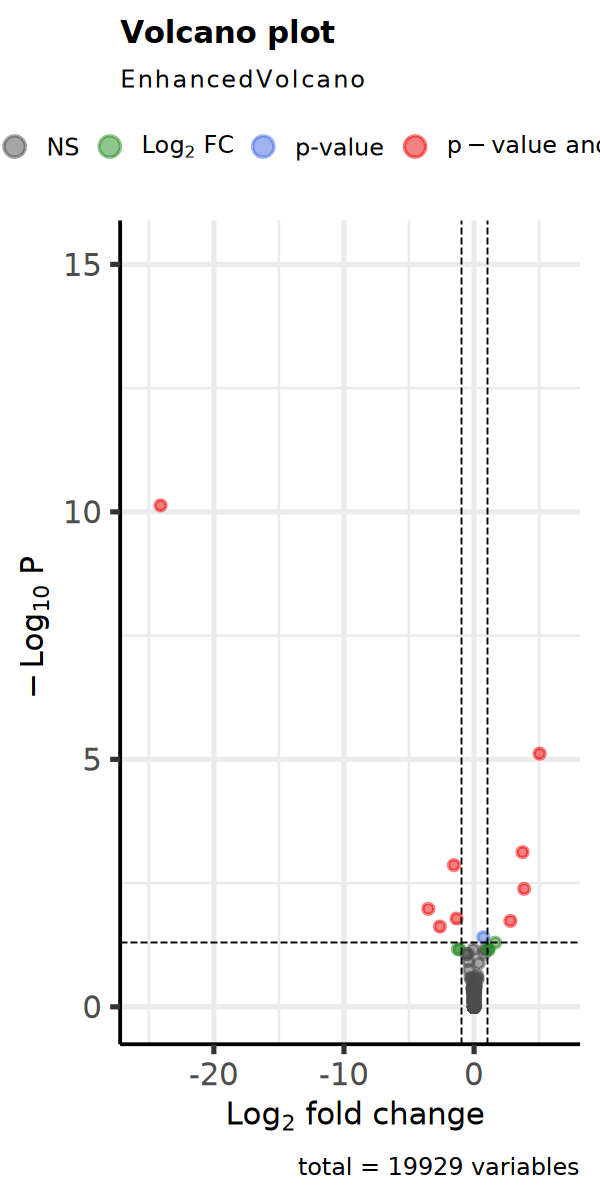

In [88]:
res.ww.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'warm.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.ww.cw)

EnhancedVolcano(res.ww.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.ww.cw <- merge(res.ww.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.ww.cw)[1] <- 'Gene'

head(res.ww.cw)

In [75]:
#write.csv(res.ww.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/ww_cw.csv', row.names = FALSE)

**BB vs. CB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.187901e-05,0.005833706,-0.08515265,0.9321400,0.9993825,0.9984255,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-3.694001e-04,0.038923937,-0.45689558,0.6477461,0.9993825,0.9895153,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,2.508082e-04,0.039461956,0.29481044,0.7681387,0.9993825,0.9903911,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,2.406248e-05,0.005751421,0.16462197,0.8692415,0.9993825,0.9984887,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,1.972791e-04,0.006307623,1.13025071,0.2583706,0.9993825,0.9984114,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,7.033781e-05,0.008366636,0.49632649,0.6196641,0.9993825,0.9972455,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


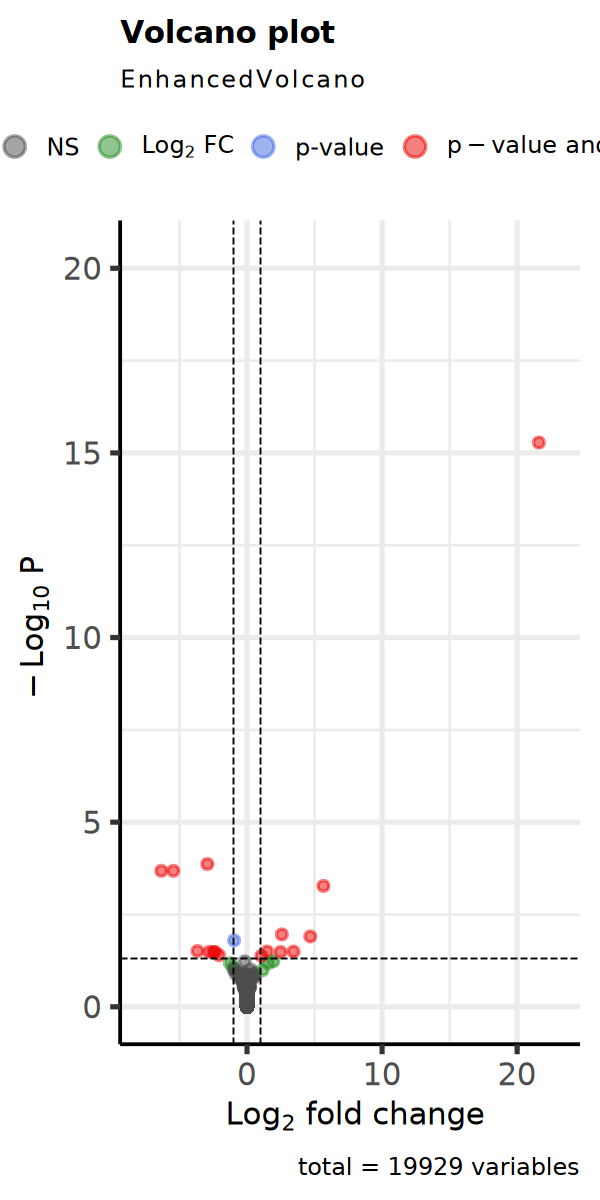

In [89]:
res.cb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_control.both_vs_both.both', # BB is the "control"
                       type = 'ashr',
                      lfcThreshold = 1)

summary(res.cb.bb)

EnhancedVolcano(res.cb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.bb <- merge(res.cb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.bb)[1] <- 'Gene'

head(res.cb.bb)

In [77]:
#write.csv(res.cb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_bb.csv', row.names = FALSE)

#### 5B. Semi-matched priming: in context of later *single* stress
- CH vs. BH
- CW vs. BW

**CH vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 2, 0.01%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.02669000,0.1537913,0.2775817,0.781333482,0.9379634,0.9958775,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.03028152,0.2436322,-0.8546221,0.392760412,0.7446223,0.9768524,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.03846842,0.2557695,1.1225024,0.261648897,0.6423339,0.9698626,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.11683104,0.1609935,-1.1493831,0.250398059,0.6325211,0.9954335,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.32733142,0.1651357,2.7787508,0.005456837,0.1215486,0.9936181,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.07444135,0.2008354,0.8376181,0.402245210,0.7511815,0.9925887,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


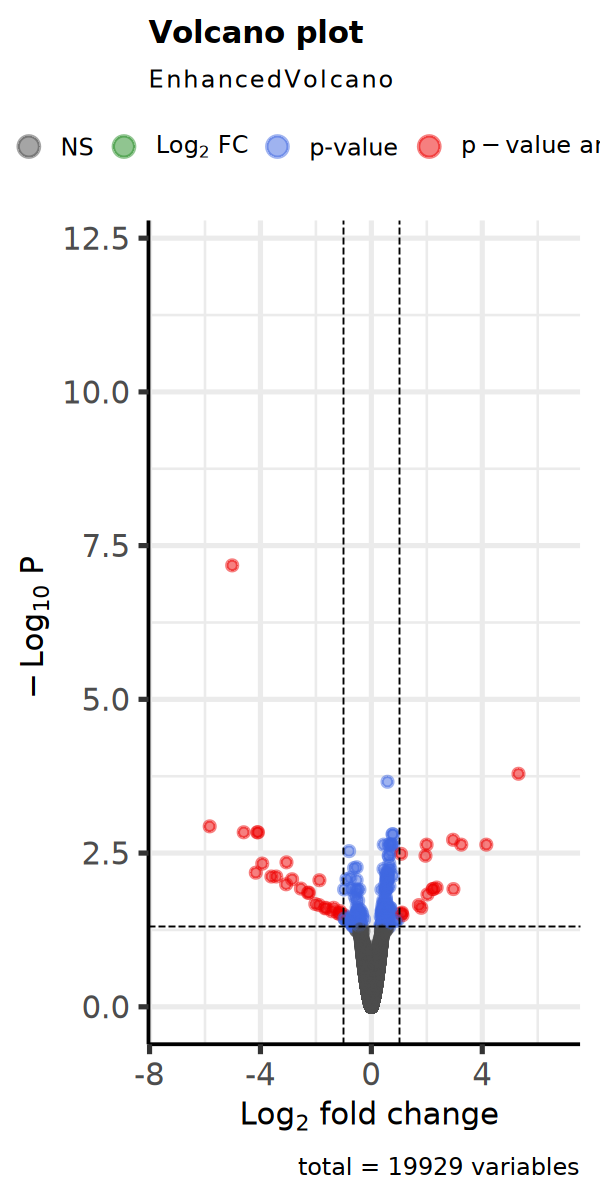

In [90]:
res.bh.ch <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bh.ch)

EnhancedVolcano(res.bh.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bh.ch <- merge(res.bh.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bh.ch)[1] <- 'Gene'

head(res.bh.ch)

In [79]:
#write.csv(res.bh.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_ch.csv', row.names = FALSE)

**CW vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0024122530,0.04013818,-0.3650728,0.7150571,0.9899255,0.9986021,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0032992471,0.08414379,-1.2772072,0.2015291,0.9149891,0.9839110,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0020465894,0.07125429,0.9247539,0.3550940,0.9527794,0.9878520,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0045490442,0.04006704,-0.6411263,0.5214406,0.9755335,0.9986111,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0048964239,0.03977807,-0.5973763,0.5502562,0.9763191,0.9987702,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0002013744,0.04093672,-0.0524969,0.9581328,0.9986774,0.9979755,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


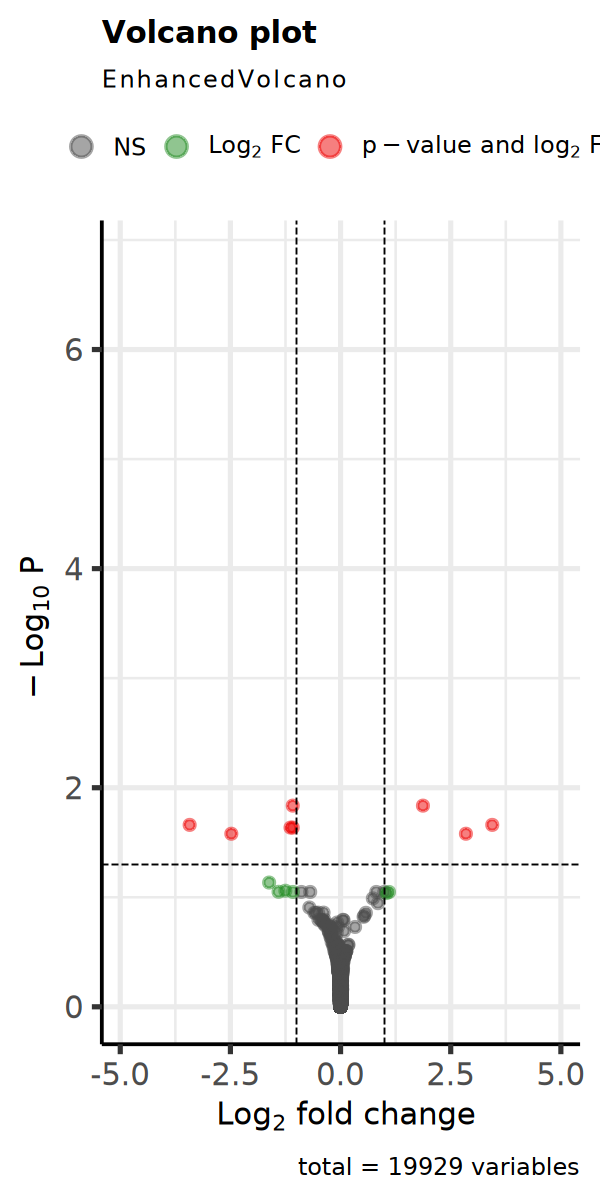

In [91]:
res.bw.cw <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'control.warm'), # CW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bw.cw)

EnhancedVolcano(res.bw.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.cw <- merge(res.bw.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.cw)[1] <- 'Gene'

head(res.bw.cw)

In [81]:
#write.csv(res.bw.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bw_cw.csv', row.names = FALSE)

#### 5C. Semi-matched priming: in context of later *multiple* stress
- CB vs. WB
- CB vs. HB

**CB vs. WB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 9, 0.045%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,4.970106e-05,0.008349914,0.1765157,0.8598888,0.9960954,0.9929772,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,1.157603e-03,0.085559741,0.2658281,0.7903716,0.9938423,0.9676146,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,1.228933e-03,0.092198529,0.2592296,0.7954581,0.9938423,0.9657328,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-4.713722e-04,0.012987937,-1.1903510,0.2339085,0.9269542,0.9916912,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-2.260972e-04,0.008385937,-0.7723034,0.4399348,0.9776938,0.9934666,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,4.667803e-04,0.020273233,0.7137666,0.4753715,0.9829065,0.9872510,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


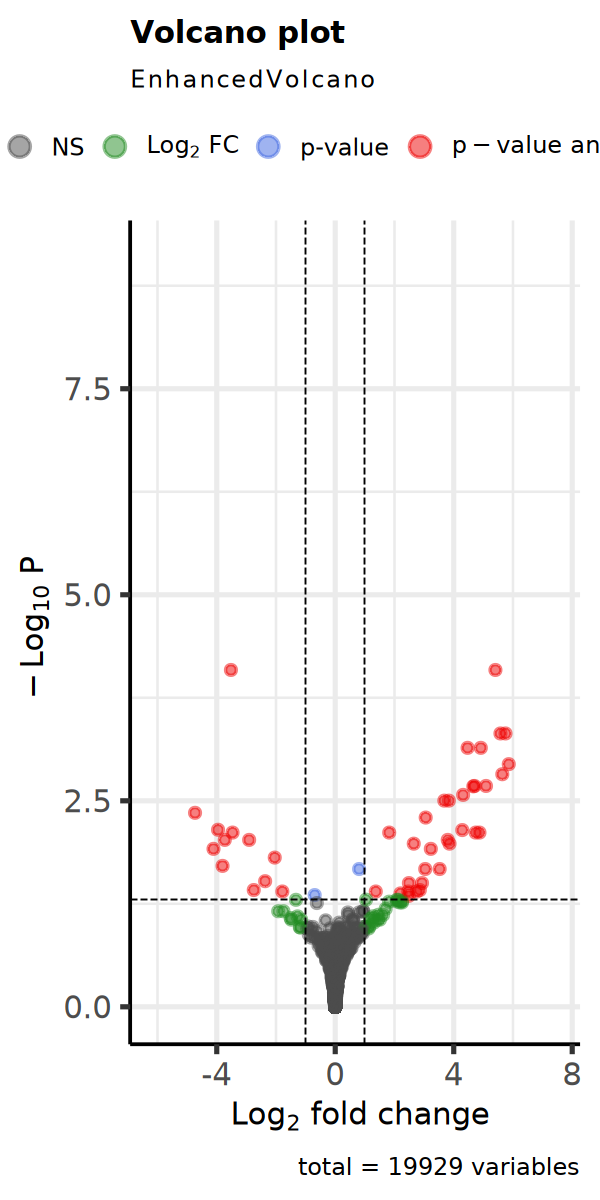

In [92]:
res.wb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.both', 'control.both'), # CB is the "control"
                       type = 'ashr',
                      lfcThreshold = 1)

summary(res.wb.cb)

EnhancedVolcano(res.wb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.cb <- merge(res.wb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.cb)[1] <- 'Gene'

head(res.wb.cb)

In [83]:
#write.csv(res.wb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wb_cb.csv', row.names = FALSE)

**CB vs. HB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.383859e-04,0.007505825,-0.61465955,0.5387796,0.9998315,0.9990765,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,1.825313e-04,0.029068757,0.38319938,0.7015719,0.9998315,0.9942416,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-4.325029e-05,0.029100330,-0.08774224,0.9300815,0.9998315,0.9954430,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.105734e-04,0.007379399,-0.46350324,0.6430037,0.9998315,0.9991639,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,4.135253e-05,0.007255707,0.15152263,0.8795635,0.9998315,0.9992755,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-5.024706e-05,0.008482618,-0.31350149,0.7538997,0.9998315,0.9986217,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


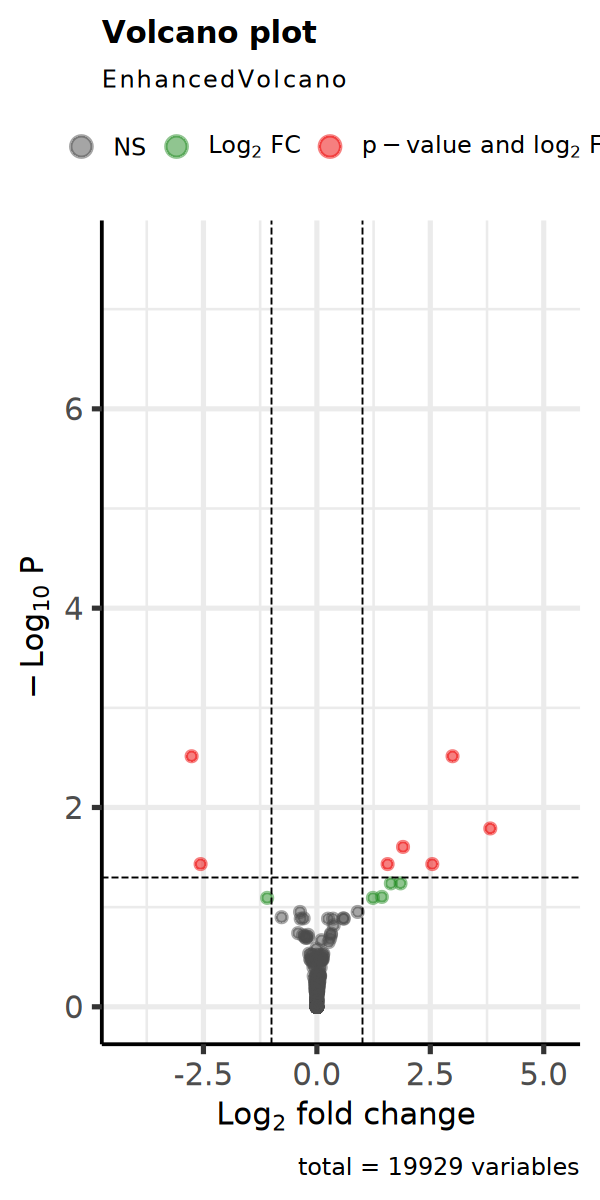

In [93]:
res.hb.cb <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.both', 'control.both'), # CB is the "control"
                       type = 'ashr',
                      lfcThreshold = 1)

summary(res.hb.cb)

EnhancedVolcano(res.hb.cb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.cb <- merge(res.hb.cb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.cb)[1] <- 'Gene'

head(res.hb.cb)

In [85]:
#write.csv(res.hb.cb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hb_cb.csv', row.names = FALSE)

### 6. Effect of initial exposure on subsequent response to stress
Oysters all experience the same early stressor, but either return to that stressor or experience control conditions
- HC vs. HH
- WC vs. WW
- BB vs. BC

**HC vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 6, 0.03%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0019125820,0.06699609,-0.10894111,0.9132492,0.9935574,0.9968252,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0016145204,0.09309567,-0.32177970,0.7476196,0.9835592,0.9834911,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0007734993,0.09450117,-0.15650852,0.8756322,0.9898083,0.9846847,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.0003224227,0.06652507,-0.01722243,0.9862592,0.9987307,0.9970102,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0032596892,0.06544457,0.15390532,0.8776844,0.9898083,0.9971955,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0027103428,0.06963134,-0.25625281,0.7977556,0.9859531,0.9949548,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


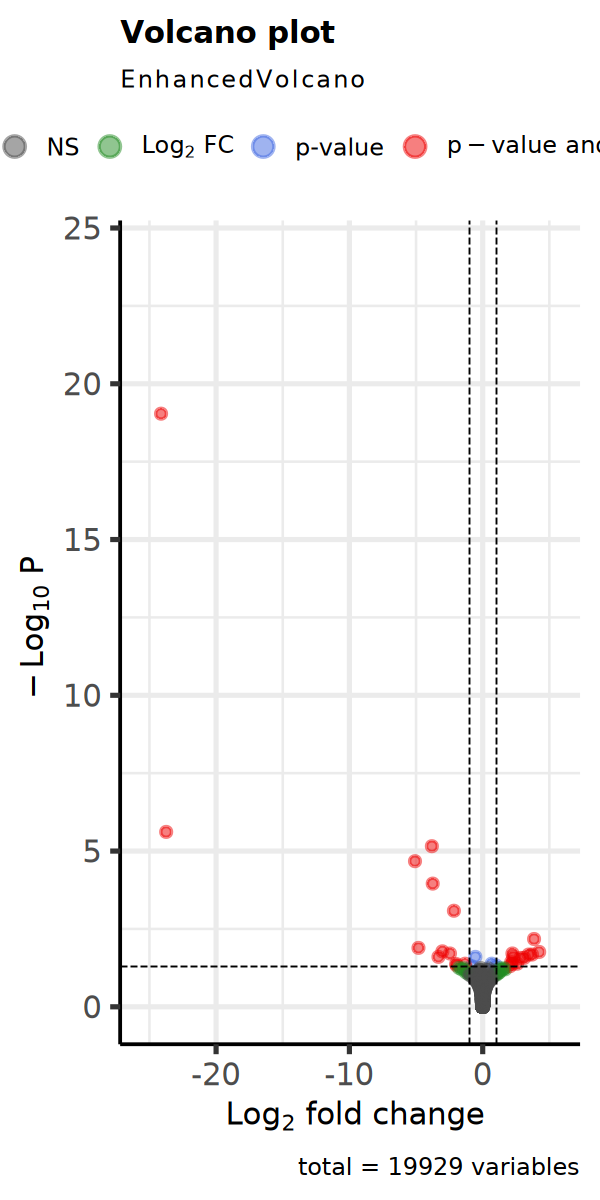

In [94]:
res.hc.hh <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'hypoxic.control', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hc.hh)

EnhancedVolcano(res.hc.hh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hc.hh <- merge(res.hc.hh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hc.hh)[1] <- 'Gene'

head(res.hc.hh)

In [87]:
#write.csv(res.hc.hh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hc_hh.csv', row.names = FALSE)

**WC vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.015%
LFC < -1.00 (down) : 2, 0.01%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.029887993,0.1259834,-0.45980192,0.6456584,0.9064156,0.9977373,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.014922992,0.1641288,-0.95594548,0.3390998,0.7767064,0.9818973,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.001373012,0.1563299,0.09611591,0.9234285,0.9836800,0.9906656,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.063958330,0.1238419,0.95046419,0.3418764,0.7782403,0.9976522,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.071791447,0.1173220,1.01567845,0.3097825,0.7583441,0.9978987,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.017044783,0.1406591,0.37590517,0.7069874,0.9275142,0.9965623,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


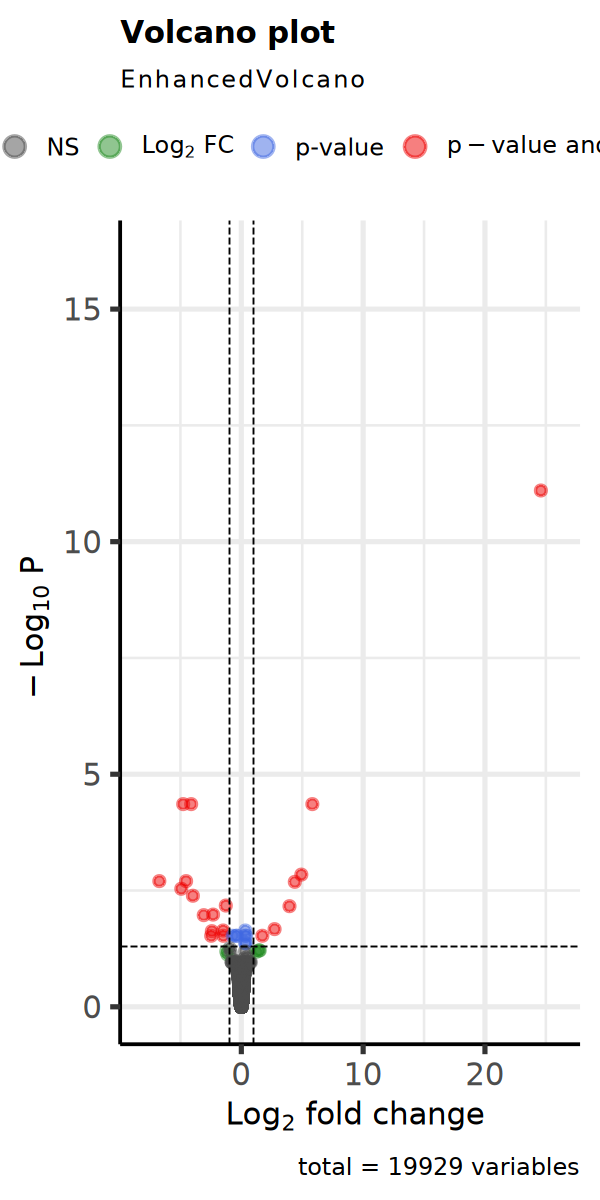

In [95]:
res.wc.ww <- lfcShrink(dds_rm, contrast = c('complete_trtmt', 'warm.control', 'warm.warm'), # WW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wc.ww)

EnhancedVolcano(res.wc.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.ww <- merge(res.wc.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.ww)[1] <- 'Gene'

head(res.wc.ww)

In [89]:
#write.csv(res.wc.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wc_ww.csv', row.names = FALSE)

**BC vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 6, 0.03%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0202111054,0.08396907,-0.7878064,0.43080996,0.9331228,0.9950303,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.0009362461,0.11559350,0.1175916,0.90639129,0.9930216,0.9806819,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0815291363,0.54337825,-2.4512092,0.01423772,0.3931132,0.8327046,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0047173699,0.07804922,0.1838452,0.85413492,0.9906537,0.9958110,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0089051442,0.07497361,0.3242480,0.74575027,0.9817684,0.9960945,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.0038484519,0.09018086,0.2177440,0.82762858,0.9895795,0.9932619,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


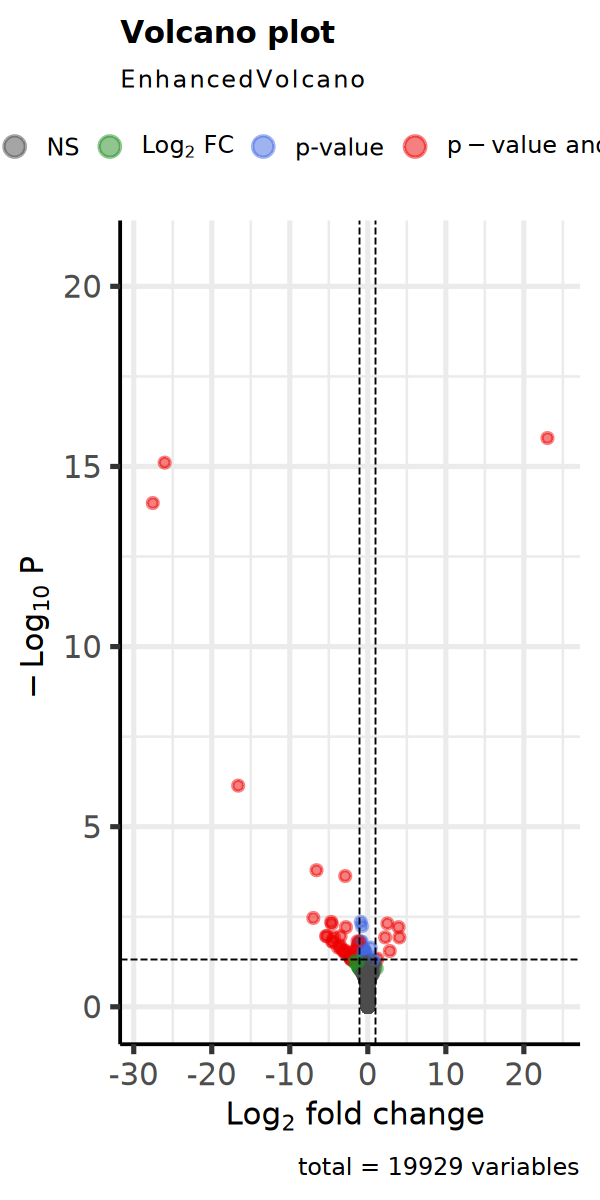

In [96]:
res.bc.bb <- lfcShrink(dds_rm, coef = 'complete_trtmt_both.control_vs_both.both', # BB is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bc.bb)

EnhancedVolcano(res.bc.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.bb <- merge(res.bc.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.bb)[1] <- 'Gene'

head(res.bc.bb)

In [91]:
#write.csv(res.bc.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_bb.csv', row.names = FALSE)

### 7. Effect of initial single/multiple stress on response in ...
Is it better to be primed with a single stressor or multiple stressor, depending on the context of the future enviornment (single/multiple stressor)?

#### 7A. ...later *single* stress
Oyster is primed with either multiple or a single stressors, and then experiences only a sinlge stressor later
- BH vs. HH
- BW vs. WW

**BH vs. HH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 2, 0.01%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.008378215,0.1484738,-0.09727838,0.92250532,0.9832184,0.9968179,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.021117955,0.2188664,-0.77074892,0.44085577,0.8167992,0.9793662,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.014067389,0.2171595,-0.54715326,0.58427344,0.8777101,0.9820209,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.196359162,0.1700594,-1.96223881,0.04973469,0.3881722,0.9952110,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.096965824,0.1424663,1.07661568,0.28165199,0.7130212,0.9968195,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.040865081,0.1831806,0.56540016,0.57180161,0.8724640,0.9946416,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


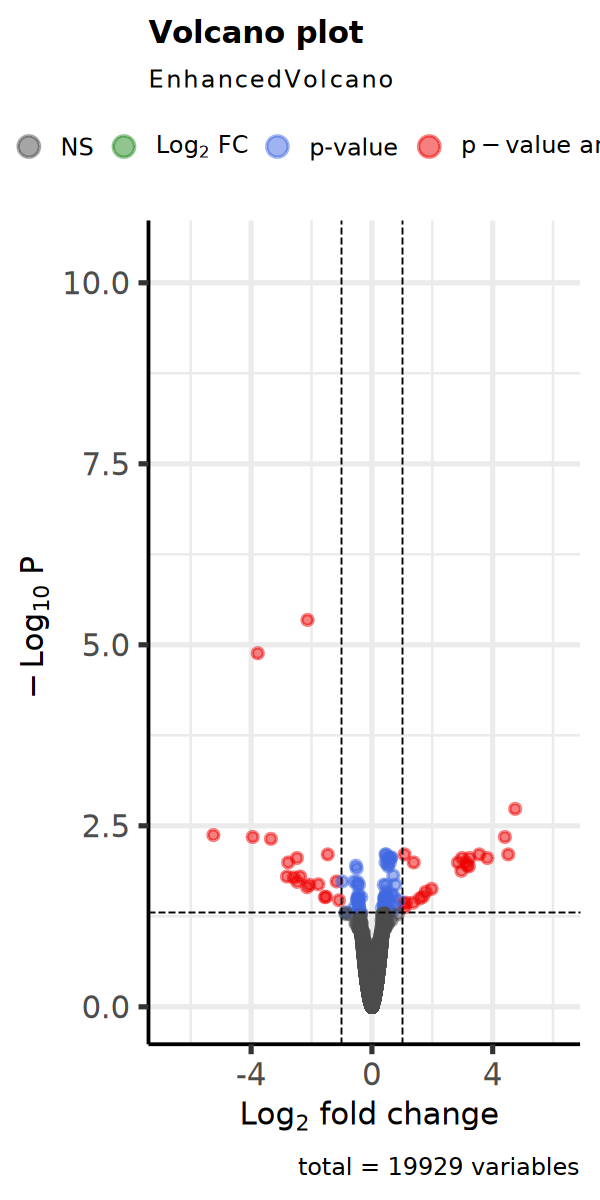

In [97]:
res.hh.bh <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.hypoxic', 'hypoxic.hypoxic'), # HH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hh.bh)

EnhancedVolcano(res.hh.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hh.bh <- merge(res.hh.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hh.bh)[1] <- 'Gene'

head(res.hh.bh)

In [93]:
#write.csv(res.hh.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bh_hh.csv', row.names = FALSE)

**BW vs. WW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 4, 0.02%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.005963631,0.07025644,-0.2946060,0.7682949,0.9788173,0.9976311,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.005451739,0.10523894,-1.0200137,0.3077219,0.8896883,0.9775717,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.001990717,0.09151312,0.4244924,0.6712067,0.9661391,0.9861491,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.004981015,0.06968704,0.2317737,0.8167138,0.9814906,0.9977712,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.010391877,0.06839085,-0.4292848,0.6677160,0.9655073,0.9979143,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.005773944,0.07314786,-0.4724019,0.6366399,0.9605055,0.9960703,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


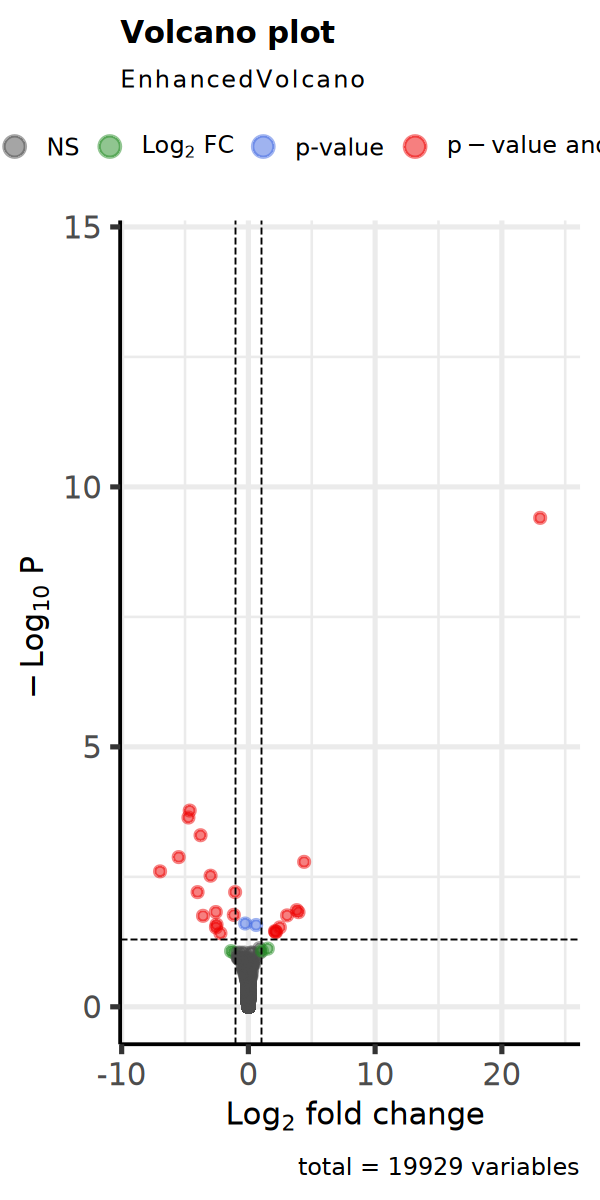

In [98]:
res.bw.ww <- lfcShrink(dds_rm, contrast= c('complete_trtmt', 'both.warm', 'warm.warm'), # WW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bw.ww)

EnhancedVolcano(res.bw.ww,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bw.ww <- merge(res.bw.ww, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bw.ww)[1] <- 'Gene'

head(res.bw.ww)

In [95]:
#write.csv(res.bw.ww, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bw_ww.csv', row.names = FALSE)

#### 7B. ...later *multiple* stressors
Oyster is primed with either multiple or a single stressors, and then experiences multiple stressors later
- HB vs. BB
- WB vs. BB

**HB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-2.016851e-04,0.008824769,-0.69982652,0.4840357,0.9999947,0.9974142,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.053089e-04,0.047830386,-0.07369057,0.9412566,0.9999947,0.9897580,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,3.240308e-04,0.052470613,0.20705794,0.8359646,0.9999947,0.9879710,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.582446e-05,0.008105097,-0.29903603,0.7649126,0.9999947,0.9977546,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,4.544930e-04,0.009535910,1.28172633,0.1999387,0.9999947,0.9976110,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,5.213808e-05,0.011290354,0.18232067,0.8553311,0.9999947,0.9963774,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


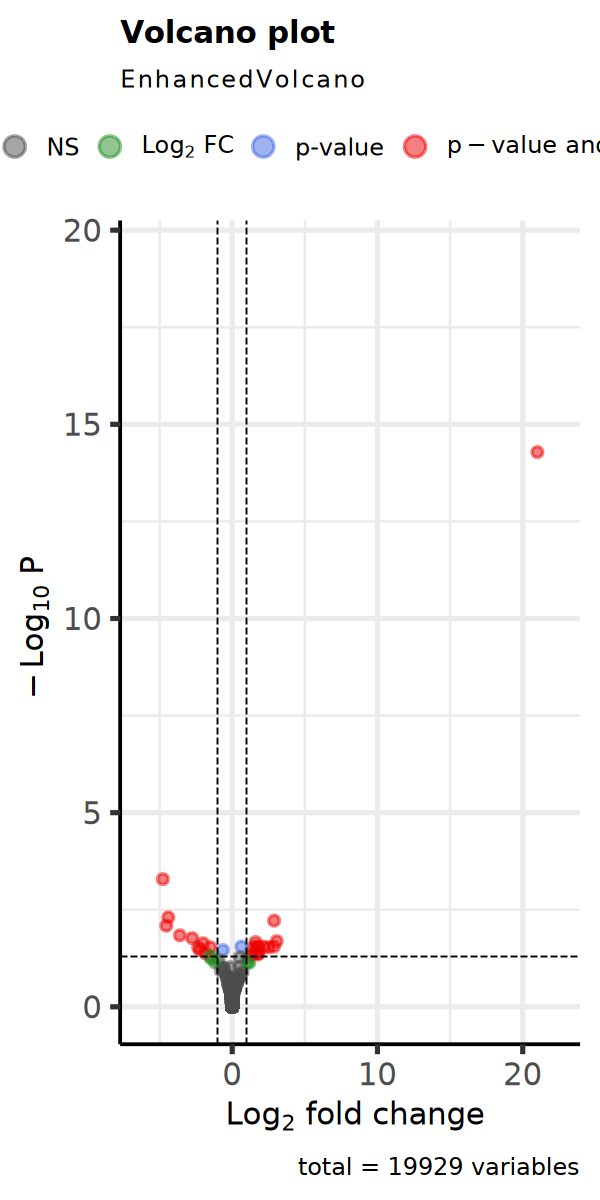

In [99]:
res.hb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_hypoxic.both_vs_both.both', # BB is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hb.bb)

EnhancedVolcano(res.hb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bb <- merge(res.hb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bb)[1] <- 'Gene'

head(res.hb.bb)

In [97]:
#write.csv(res.hb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hb_bb.csv', row.names = FALSE)

**WB vs. BB**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,2.354166e-05,0.007927878,0.09137826,0.9271920,0.9999282,0.9984637,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-1.895284e-04,0.040287337,-0.19106424,0.8484753,0.9999282,0.9924385,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,6.511840e-04,0.049347524,0.55403782,0.5795530,0.9999282,0.9889105,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-2.980986e-04,0.008791856,-1.02594195,0.3049189,0.9999282,0.9982419,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,1.091544e-04,0.007704179,0.35791879,0.7204041,0.9999282,0.9986239,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,4.152990e-04,0.016909582,1.21005776,0.2262567,0.9999282,0.9959683,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


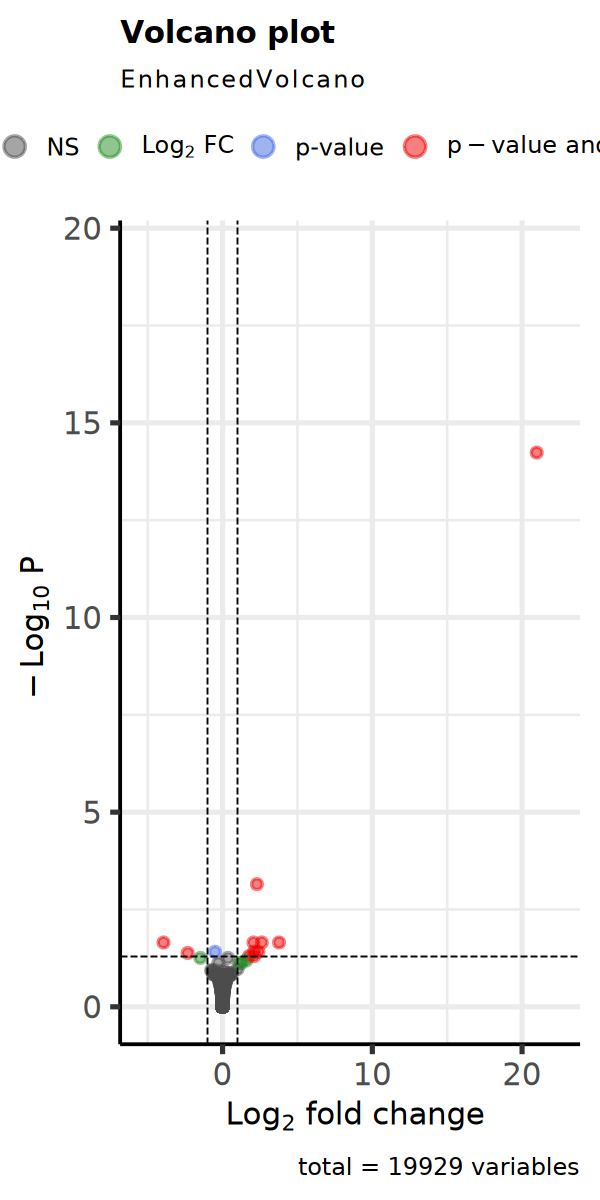

In [100]:
res.wb.bb <- lfcShrink(dds_rm, 
                       coef= 'complete_trtmt_warm.both_vs_both.both', # BB is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wb.bb)

EnhancedVolcano(res.wb.bb,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bb <- merge(res.wb.bb, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bb)[1] <- 'Gene'

head(res.wb.bb)

In [99]:
#write.csv(res.wb.bb, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wb_bb.csv', row.names = FALSE)

### 8. Shared/Unique responses among stressors with ...

#### 8A. ...different *early* stressors
>can compare these with the phase 1 vs. phase 1 DEGs to see if there are similarities
- WC vs. HC: single early stress
- BC vs. HC: mulitple vs. single
- BC vs. WC: multiple vs. single

**WC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.015%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,1.671621e-04,0.006763632,0.98046838,0.3268550,0.99995,0.9986050,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,3.535761e-04,0.033968859,0.68225415,0.4950783,0.99995,0.9900994,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-7.700797e-06,0.028438689,-0.01628116,0.9870101,0.99995,0.9942976,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-8.874402e-05,0.006342954,-0.50527474,0.6133659,0.99995,0.9988488,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,3.514133e-05,0.006210149,0.17584419,0.8604163,0.99995,0.9990131,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,1.321380e-04,0.009065958,0.94300942,0.3456761,0.99995,0.9975216,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


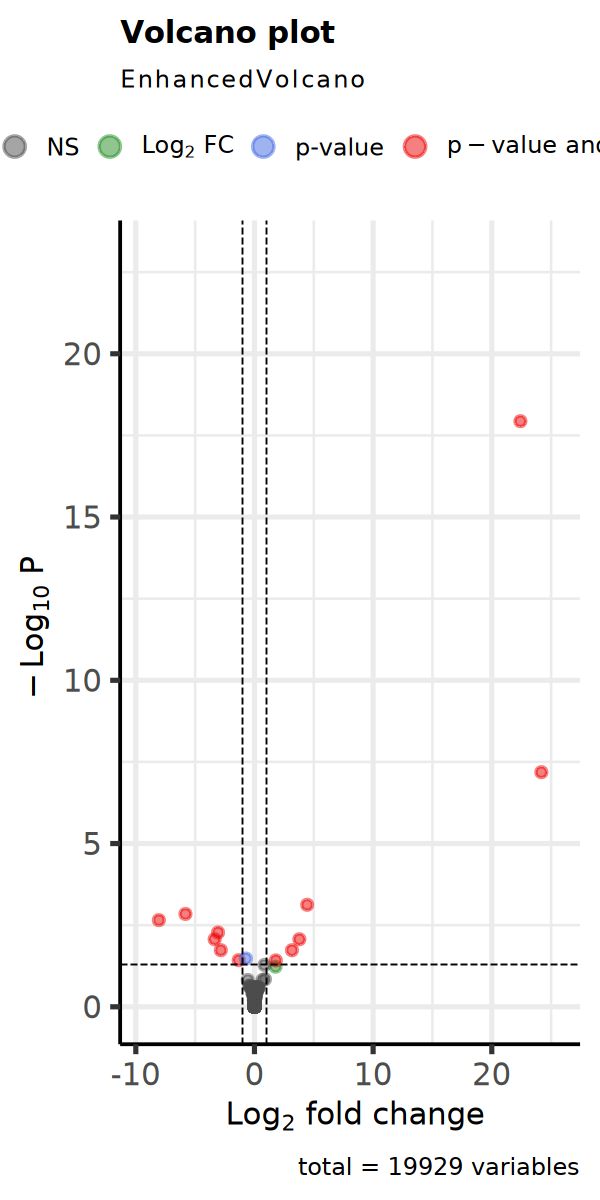

In [101]:
res.wc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wc.hc)

EnhancedVolcano(res.wc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wc.hc <- merge(res.wc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wc.hc)[1] <- 'Gene'

head(res.wc.hc)

In [101]:
#write.csv(res.wc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wc_hc.csv', row.names = FALSE)

**BC vs. HC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 2, 0.01%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,6.704472e-06,0.006757908,0.03753076,0.97006181,0.9998426,0.9993407,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,4.982626e-04,0.039835307,1.45227895,0.14642406,0.9998426,0.9861082,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-1.099066e-03,0.064760247,-1.79528102,0.07260894,0.9998426,0.9763029,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-1.840865e-05,0.006744697,-0.09568535,0.92377048,0.9998426,0.9993711,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,2.689052e-05,0.006724654,0.12023879,0.90429399,0.9998426,0.9994283,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-1.639759e-05,0.007065794,-0.15078870,0.88014240,0.9998426,0.9989336,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


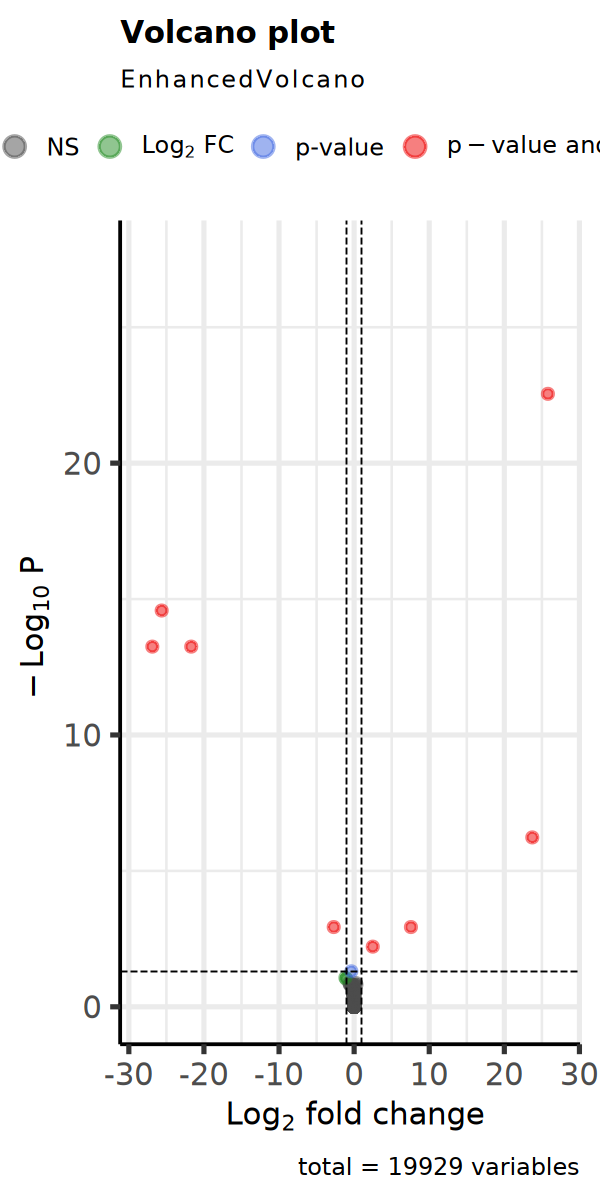

In [102]:
res.bc.hc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'hypoxic.control'), # HC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bc.hc)

EnhancedVolcano(res.bc.hc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.hc <- merge(res.bc.hc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.hc)[1] <- 'Gene'

head(res.bc.hc)

In [103]:
#write.csv(res.bc.hc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_hc.csv', row.names = FALSE)

**BC vs. WC**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-1.718745e-04,0.007541414,-0.89734798,0.36953326,0.9998896,0.9972082,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,1.003690e-03,0.057111546,0.80178639,0.42267653,0.9998896,0.9801967,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-7.396341e-03,0.167285826,-1.77977971,0.07511202,0.9998896,0.9393672,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,7.302603e-05,0.006750242,0.38616133,0.69937719,0.9998896,0.9976963,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-9.935114e-06,0.006508491,-0.04742589,0.96217379,0.9998896,0.9980096,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-2.383152e-04,0.013210014,-1.04988849,0.29376938,0.9998896,0.9946078,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


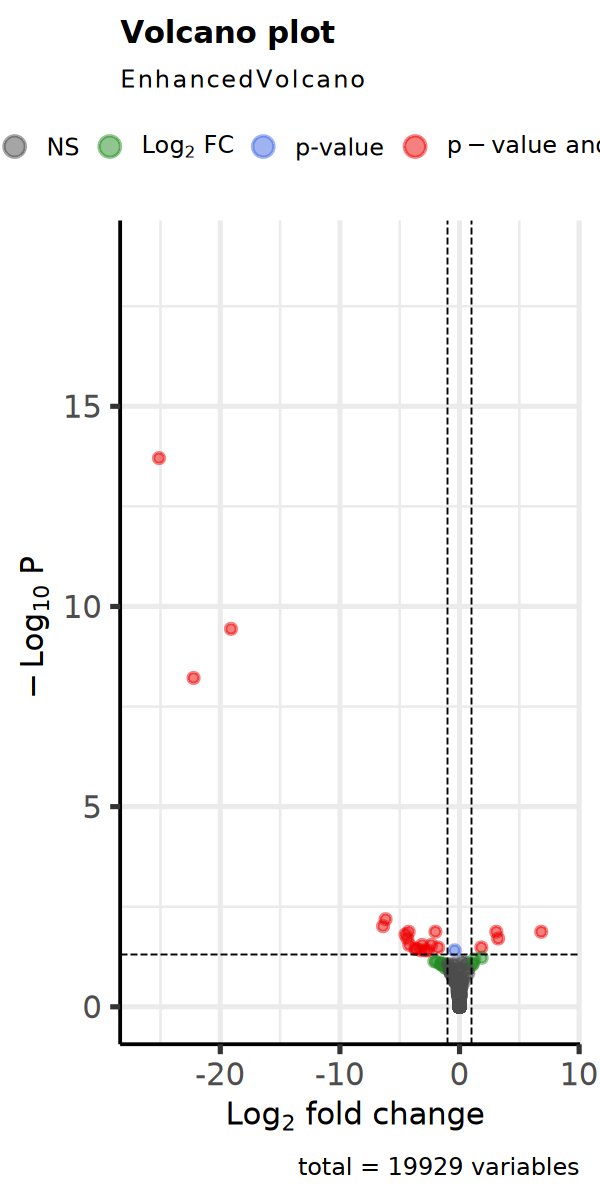

In [103]:
res.bc.wc <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'both.control', 'warm.control'), # WC is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.bc.wc)

EnhancedVolcano(res.bc.wc,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.bc.wc <- merge(res.bc.wc, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.bc.wc)[1] <- 'Gene'

head(res.bc.wc)

In [105]:
#write.csv(res.bc.wc, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/bc_wc.csv', row.names = FALSE)

#### 8B. ...different *late* stressors
- CW vs. CH: single early stress
- CB vs. CH: mulitple vs. single
- CB vs. CW: multiple vs. single

**CW vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 1, 0.005%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.020922392,0.05899120,1.7762722,0.07568807,0.7121051,0.9934278,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.011798549,0.16234002,1.5116425,0.13062485,0.7976044,0.9546681,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.005226181,0.11494260,0.9198865,0.35763206,0.9159322,0.9716820,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.003663686,0.05180661,0.3084408,0.75774692,0.9804792,0.9960565,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.015566415,0.05184060,1.1393767,0.25454606,0.8791483,0.9959419,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.000848807,0.05482478,0.1234483,0.90175213,0.9957473,0.9938167,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


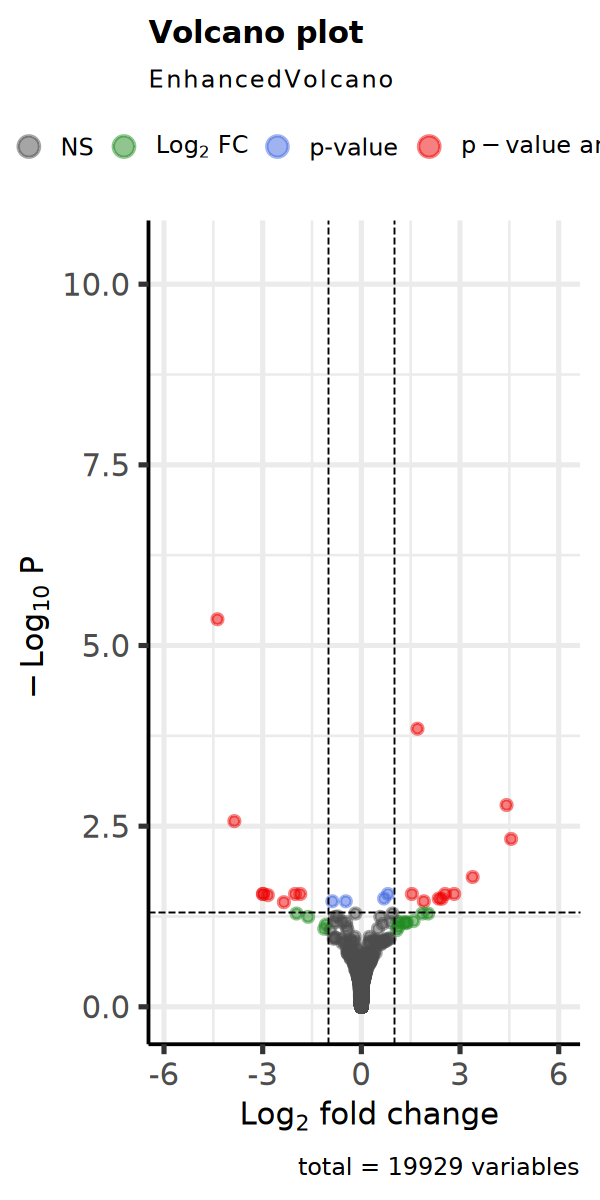

In [104]:
res.cw.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.warm', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cw.ch)

EnhancedVolcano(res.cw.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cw.ch <- merge(res.cw.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cw.ch)[1] <- 'Gene'

head(res.cw.ch)

In [13]:
#write.csv(res.cw.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cw_ch.csv', row.names = FALSE)

**CB vs. CH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 4, 0.02%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.031638639,0.08748722,1.04591537,0.295600106,0.8526107,0.9950420,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.004789737,0.12154067,0.55920797,0.576019792,0.9328935,0.9753353,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.081679269,0.51167178,2.51550829,0.011886088,0.4135728,0.8365574,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.024051572,0.08511691,0.76265155,0.445671234,0.9003834,0.9956888,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.112846421,0.11363861,2.72741695,0.006383232,0.3276836,0.9925919,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.001652528,0.09145818,0.08628355,0.931241012,0.9909759,0.9938963,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


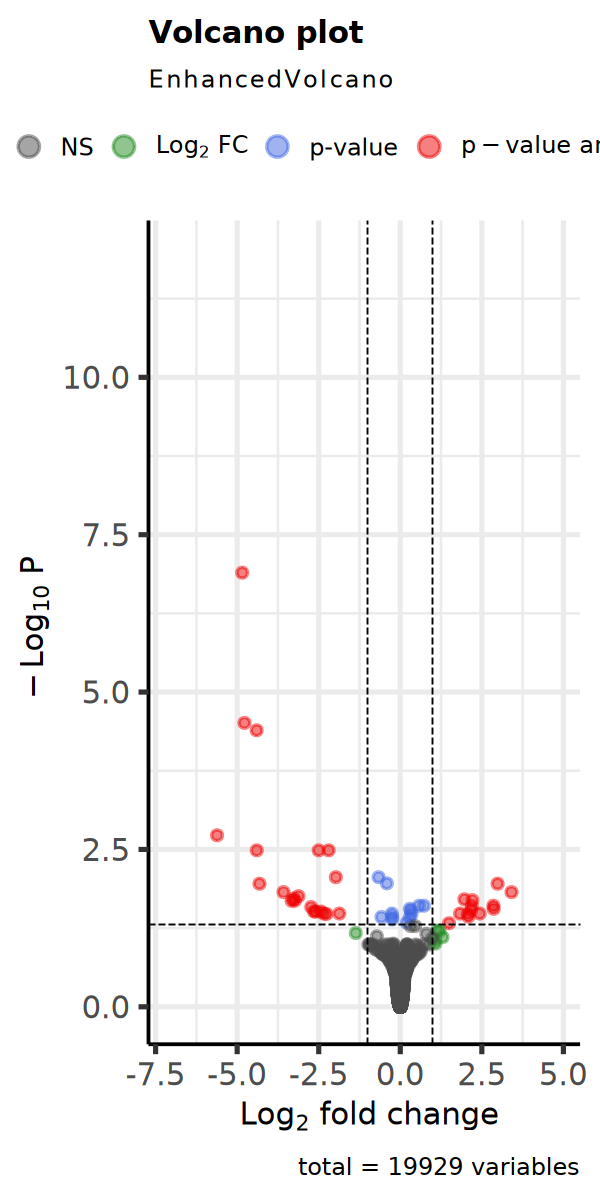

In [105]:
res.cb.ch <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.hypoxic'), # CH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cb.ch)

EnhancedVolcano(res.cb.ch,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.ch <- merge(res.cb.ch, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.ch)[1] <- 'Gene'

head(res.cb.ch)

In [15]:
#write.csv(res.cb.ch, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_ch.csv', row.names = FALSE)

**CB vs. CW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 0, 0%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.0172250989,0.07641087,-0.7302887,0.4652137,0.9022715,0.9953487,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0079787493,0.13020197,-0.9524445,0.3408716,0.8728150,0.9690550,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.0176027944,0.19402162,1.5982362,0.1099904,0.7373916,0.9430151,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0112640306,0.07500607,0.4539836,0.6498407,0.9467041,0.9958616,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.0452370578,0.07734792,1.5879681,0.1122935,0.7380615,0.9953988,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0005598347,0.08113612,-0.0371523,0.9703636,0.9955958,0.9939073,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


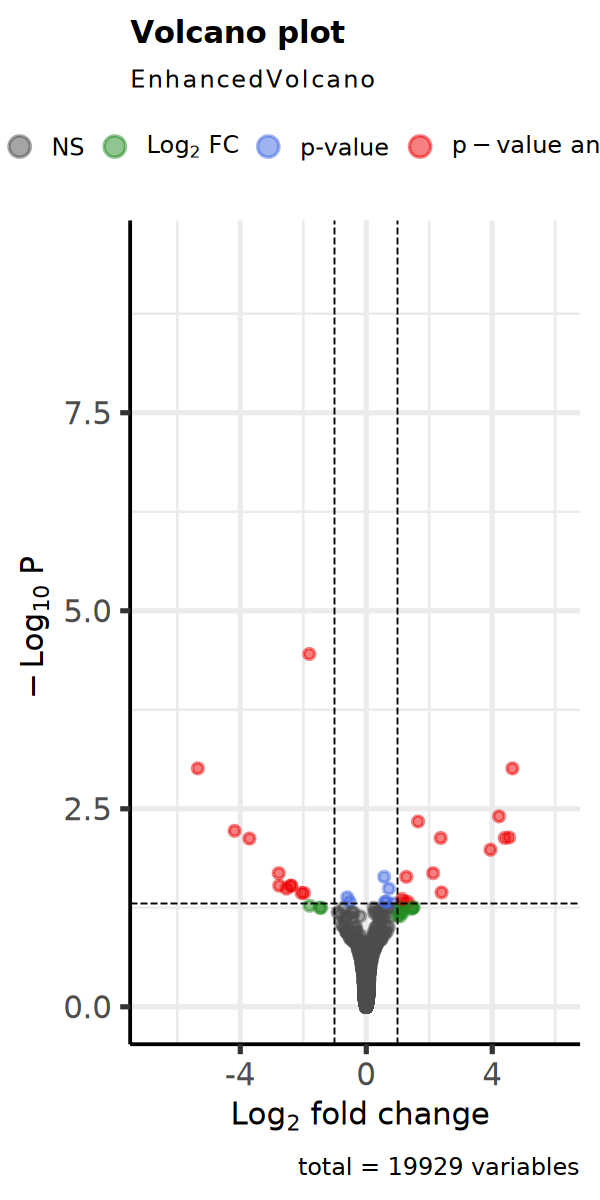

In [106]:
res.cb.cw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'control.both', 'control.warm'), # CW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.cb.cw)

EnhancedVolcano(res.cb.cw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.cb.cw <- merge(res.cb.cw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.cb.cw)[1] <- 'Gene'

head(res.cb.cw)

In [18]:
#write.csv(res.cb.cw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/cb_cw.csv', row.names = FALSE)

### 9. Effect of the order of stressors
Does the order of when stress is experienced matter? Maybe one stressor is an informative cue for a later environmnet?
- WH vs. HW
- WB vs. BW
- HB vs. BH

**WH vs. HW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 1, 0.005%
LFC < -1.00 (down) : 3, 0.015%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.0001989191,0.03350503,0.04320332,0.9655395,0.9966374,0.9981991,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,-0.0018610296,0.07035914,-0.71048523,0.4774033,0.9820078,0.9879935,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,-0.0004262643,0.06457287,-0.17663776,0.8597929,0.9927263,0.9916861,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.0015816277,0.03328151,0.32662962,0.7439480,0.9878883,0.9982132,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,-0.0009490619,0.03197615,-0.17960539,0.8574624,0.9927263,0.9984008,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.0006891182,0.03858780,-0.20251813,0.8395117,0.9927263,0.9971394,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


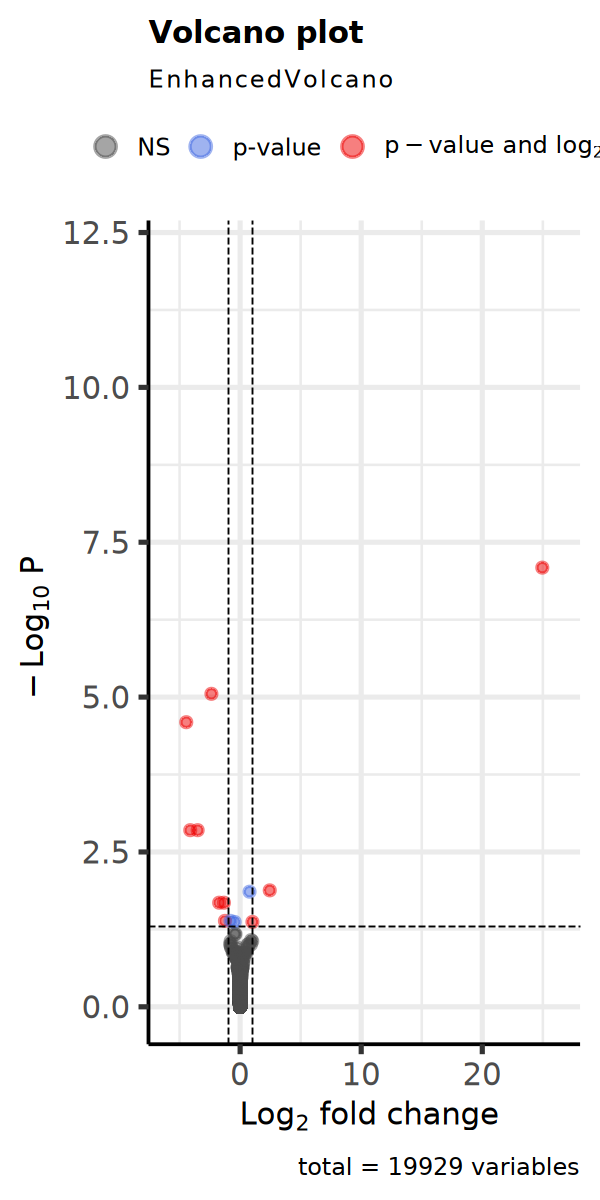

In [107]:
res.wh.hw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.hypoxic', 'hypoxic.warm'), # HW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wh.hw)

EnhancedVolcano(res.wh.hw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wh.hw <- merge(res.wh.hw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wh.hw)[1] <- 'Gene'

head(res.wh.hw)

In [20]:
#write.csv(res.wh.hw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wh_hw.csv', row.names = FALSE)

**WB vs. BW**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 15, 0.075%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,-0.007378070,0.09764185,-0.18868837,0.8503371,0.9738746,0.9929422,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.007187234,0.14674003,0.59059623,0.5547910,0.8905496,0.9613626,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.012410973,0.17329206,0.93308140,0.3507779,0.8173910,0.9470192,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,-0.003906680,0.09618851,-0.09540837,0.9239905,0.9860793,0.9933593,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.064118470,0.09520859,1.41302228,0.1576492,0.6887599,0.9926107,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,0.018569813,0.10615948,0.72911273,0.4659327,0.8655165,0.9871710,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


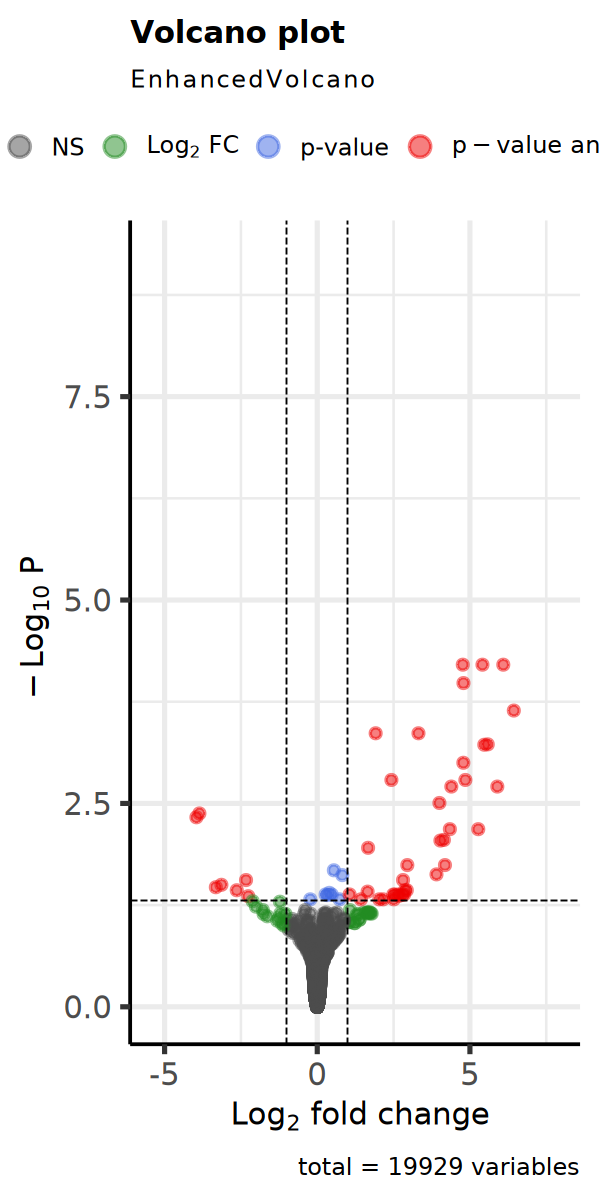

In [108]:
res.wb.bw <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'warm.both', 'both.warm'), # BW is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.wb.bw)

EnhancedVolcano(res.wb.bw,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.wb.bw <- merge(res.wb.bw, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.wb.bw)[1] <- 'Gene'

head(res.wb.bw)

In [22]:
#write.csv(res.wb.bw, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/wb_bw.csv', row.names = FALSE)

**HB vs. BH**

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 19929 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 7, 0.035%
LFC < -1.00 (down) : 0, 0%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1961.0431,0.014235651,0.1506390,0.153249,0.87820189,0.9746865,0.9943251,2479.82397,2077.44032,⋯,2973.28873,982.716630,1550.991468,2316.0272,2056.98812,1755.29636,1982.797680,1731.094774,2909.31475,2552.152426
2,LOC144621269,2462.2077,0.067894570,0.3297218,1.796922,0.07234796,0.4110173,0.8986595,51.93843,1636.28504,⋯,14710.92110,3.267553,7.432866,625.9533,40.86116,107.25041,10635.634531,17.686792,415.30658,10463.718206
3,LOC111120925,129.3218,0.040910476,0.2635616,1.307478,0.19105043,0.5991026,0.9364522,66.10346,23.06039,⋯,372.60611,0.000000,3.716433,456.3401,76.15035,29.73279,5.763947,1.105425,11.92787,9.606596
4,LOC144621283,865.9042,0.142651497,0.1564170,1.446475,0.14804410,0.5485330,0.9930515,537.32667,864.26330,⋯,599.40982,998.237508,766.824057,887.4402,860.87042,787.91887,583.311410,1413.837941,593.14020,614.822165
5,LOC144621276,12437.0262,0.009121828,0.1326545,0.100016,0.92033161,0.9824510,0.9949463,10653.98858,10994.79275,⋯,16125.74428,9596.803797,14224.028783,11417.5901,8211.23654,9402.99409,15115.373940,10069.311813,10411.94195,10043.162767
6,LOC111115920,171.6240,-0.082894413,0.1875615,-1.063497,0.28755648,0.6936599,0.9878667,159.59263,181.47524,⋯,82.08135,102.927926,247.762215,134.2771,395.61036,397.14509,182.140717,239.877118,94.33857,121.683554


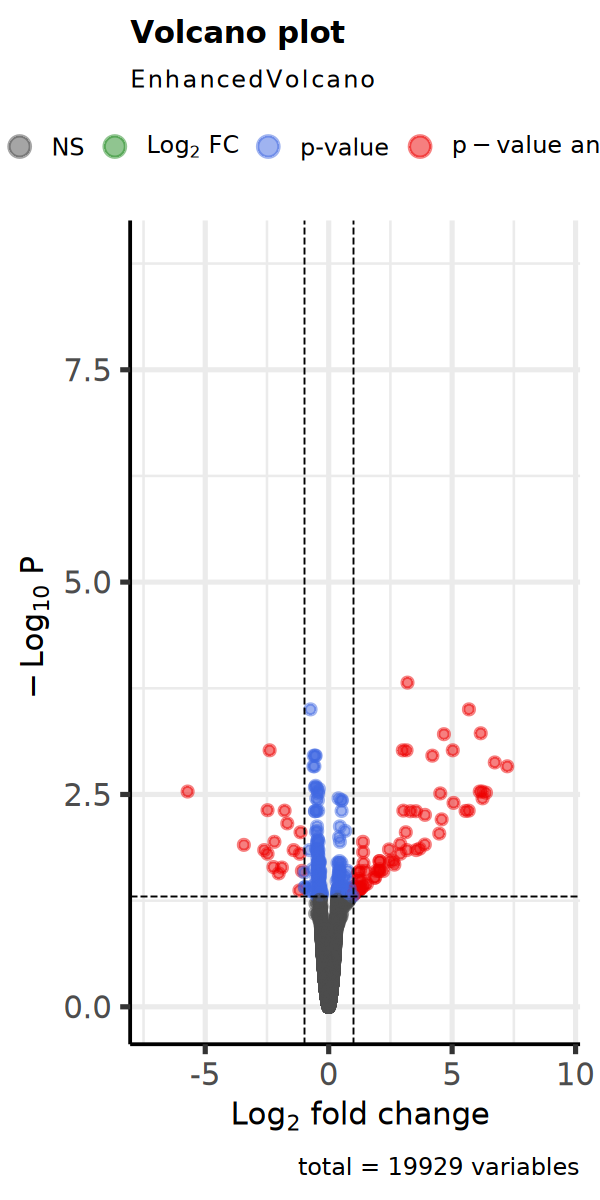

In [109]:
res.hb.bh <- lfcShrink(dds_rm, contrast=c('complete_trtmt', 'hypoxic.both', 'both.hypoxic'), # BH is the "control"
                     type = 'ashr',
                      lfcThreshold = 1)

summary(res.hb.bh)

EnhancedVolcano(res.hb.bh,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

res.hb.bh <- merge(res.hb.bh, counts(dds_rm, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(res.hb.bh)[1] <- 'Gene'

head(res.hb.bh)

In [24]:
#write.csv(res.hb.bh, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/hb_bh.csv', row.names = FALSE)

# I STOPPED HERE

### temperature and DO treatments
looking at the effects of temperature and DO in an isolated manner

#### phase 1 temp
ambient vs. warm

regardless of phase 2 treatments or phase 1 DO

In [25]:
# creating DESeq2 object
dds_p1temp <- DESeqDataSetFromMatrix(countData = counts_noOutliers,
                              colData = meta_noOutliers,
                              design = ~ Phase1_temp)
dds_p1temp

# running DESeq
dds_p1temp <- DESeq(dds_p1temp)

# list coefficients
resultsNames(dds_p1temp)

class: DESeqDataSet 
dim: 29019 94 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2515 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                   "Phase1_temp_warm_vs_ambient"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28962 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.01%
LFC < -1.00 (down) : 3, 0.01%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,3.909371e-05,0.002684280,0.48952426,0.6244706,0.9883916,0.9971959,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-3.178162e-04,0.020839518,-0.51613343,0.6057612,0.9883916,0.9926206,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,8.391273e-05,0.019385912,0.13768625,0.8904884,0.9946299,0.9934777,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,-4.941898e-05,0.078148983,-0.02359824,0.9811731,NA,0.9813841,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-1.376649e-04,0.078204514,-0.06570575,0.9476121,NA,0.9798766,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-1.550640e-04,0.003749236,-1.47525869,0.1401430,0.8969802,0.9971960,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


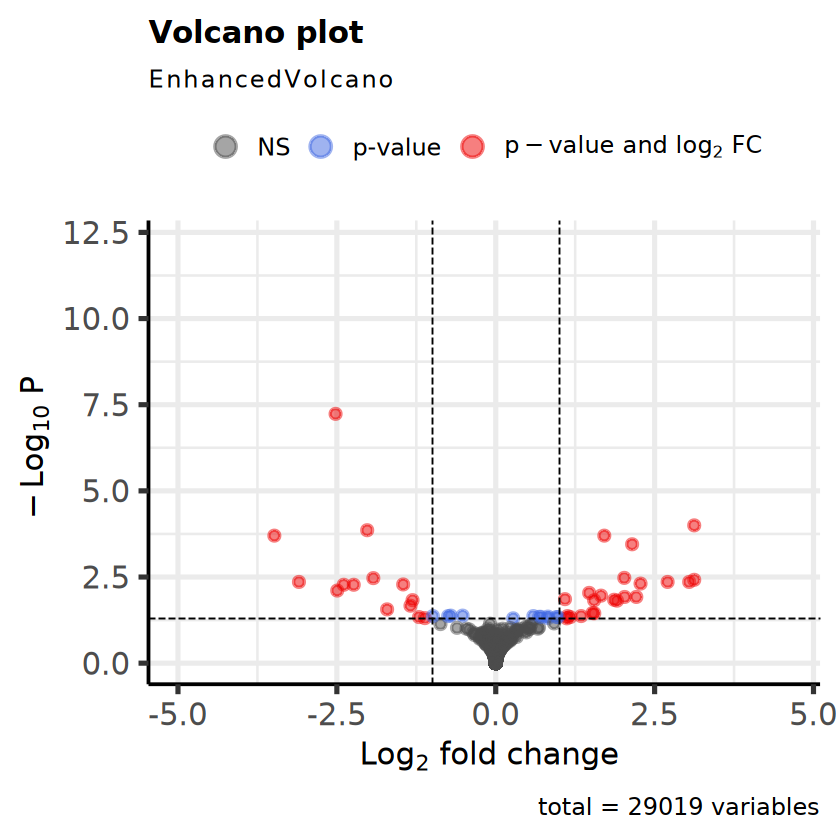

In [26]:
p1_temp.res <- lfcShrink(dds_p1temp, coef = 'Phase1_temp_warm_vs_ambient', 
                     type = 'ashr',
                      lfcThreshold = 1)

summary(p1_temp.res)

EnhancedVolcano(p1_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_temp.res <- merge(p1_temp.res, counts(dds_p1temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_temp.res)[1] <- 'Gene'

head(p1_temp.res)

In [27]:
as.data.frame(p1_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 27 DEGs

[1]  36 102

In [28]:
write.csv(p1_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p1_temp.csv', row.names = FALSE)

#### phase 1 DO
normoxic vs. hypoxic

In [29]:
# creating DESeq2 object
dds_p1DO <- DESeqDataSetFromMatrix(countData = counts_noOutliers,
                              colData = meta_noOutliers,
                              design = ~ Phase1_DO)
dds_p1DO

# running DESeq
dds_p1DO <- DESeq(dds_p1DO)

# list coefficients
resultsNames(dds_p1DO)

class: DESeqDataSet 
dim: 29019 94 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2688 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                     "Phase1_DO_hypoxic_vs_normoxic"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28963 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 3, 0.01%
LFC < -1.00 (down) : 6, 0.021%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-2.870066e-04,0.006433985,-1.74899144,0.0802925,0.8342528,0.9955813,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-2.251798e-03,0.049380223,-1.26367027,0.2063484,0.9186019,0.9777170,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,-2.360060e-04,0.025263869,-0.23504168,0.8141764,0.9939598,0.9892620,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,2.152798e-05,0.094744886,0.00699466,0.9944191,NA,0.9734868,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-1.053546e-04,0.094763578,-0.03422627,0.9726967,NA,0.9717959,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,1.320114e-05,0.002557423,0.16009925,0.8728029,0.9961728,0.9968705,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


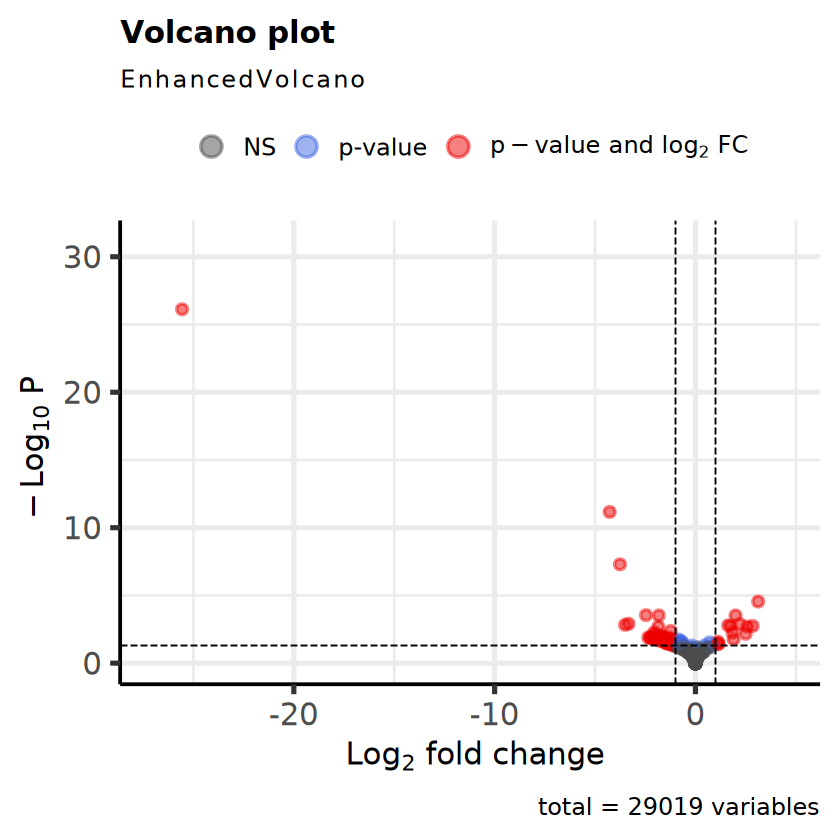

In [30]:
p1_DO.res <- lfcShrink(dds_p1DO, coef = 'Phase1_DO_hypoxic_vs_normoxic', 
                     type = 'ashr',
                      lfcThreshold = 1)

summary(p1_DO.res)

EnhancedVolcano(p1_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p1_DO.res <- merge(p1_DO.res, counts(dds_p1DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p1_DO.res)[1] <- 'Gene'

head(p1_DO.res)

a couple more DEGs, but still not a ton - to be expected, since we think GE is more short term

In [31]:
as.data.frame(p1_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 55 DEGs!

[1]  55 102

In [32]:
write.csv(p1_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p1_DO.csv', row.names = FALSE)

#### phase 2 temp
ambient vs. warm

regardless of phase 1 treatments or phase 2 DO

In [33]:
# creating DESeq2 object
dds_p2temp <- DESeqDataSetFromMatrix(countData = counts_noOutliers,
                              colData = meta_noOutliers,
                              design = ~ Phase2_temp)
dds_p2temp

# running DESeq
dds_p2temp <- DESeq(dds_p2temp)

# list coefficients
resultsNames(dds_p2temp)

class: DESeqDataSet 
dim: 29019 94 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2628 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                   "Phase2_temp_warm_vs_ambient"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28962 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 23, 0.079%
LFC < -1.00 (down) : 2, 0.0069%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,0.0798075908,0.07165165,1.44518362,0.14840632,0.4138556,0.9855203,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,0.0399184123,0.15900497,1.08191332,0.27929104,0.5717137,0.9507828,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.1867916204,0.39491613,2.47241957,0.01342019,0.1068143,0.6728450,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0010591782,0.21926699,0.06428420,0.94874393,NA,0.9360376,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0003433952,0.21919522,-0.02084607,0.98336844,NA,0.9392545,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0399003148,0.06451502,-0.77634339,0.43754626,0.7117985,0.9855210,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


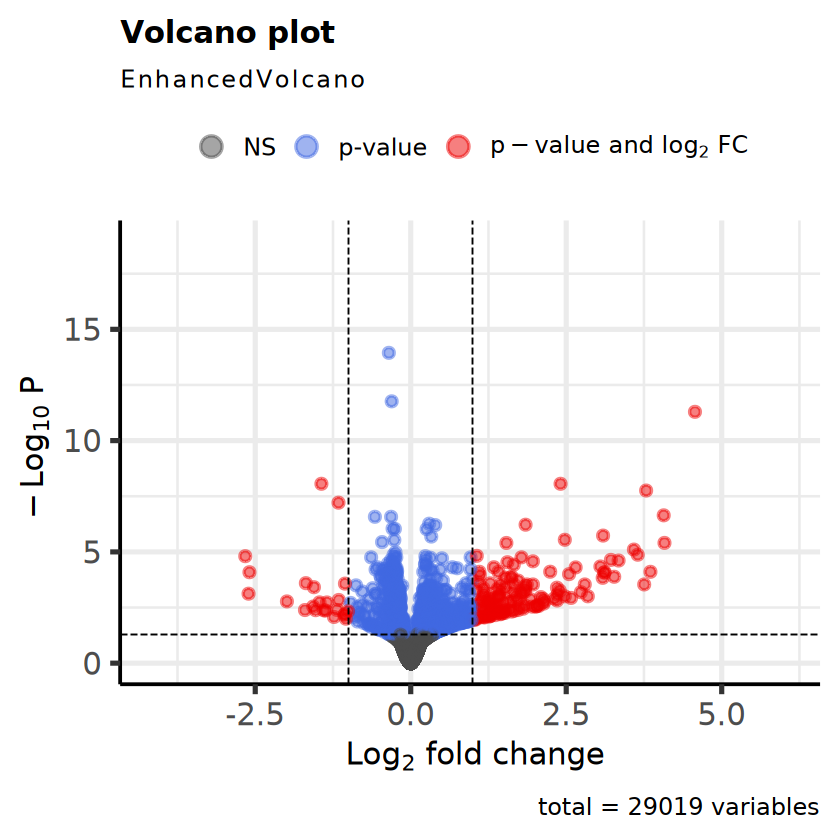

In [34]:
p2_temp.res <- lfcShrink(dds_p2temp, coef = 'Phase2_temp_warm_vs_ambient', 
                     type = 'ashr',
                      lfcThreshold = 1)

summary(p2_temp.res)

EnhancedVolcano(p2_temp.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_temp.res <- merge(p2_temp.res, counts(dds_p2temp, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_temp.res)[1] <- 'Gene'

head(p2_temp.res)

In [35]:
as.data.frame(p2_temp.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 167 DEGs!

[1] 160 102

In [36]:
write.csv(p2_temp.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p2_temp.csv', row.names = FALSE)

#### phase 2 DO
normoxic vs. hypoxic

regardless of phase 1 treatments or phase 2 temperatures

In [37]:
# creating DESeq2 object
dds_p2DO <- DESeqDataSetFromMatrix(countData = counts_noOutliers,
                              colData = meta_noOutliers,
                              design = ~ Phase2_DO)
dds_p2DO

# running DESeq
dds_p2DO <- DESeq(dds_p2DO)

# list coefficients
resultsNames(dds_p2DO)

class: DESeqDataSet 
dim: 29019 94 
metadata(1): version
assays(1): counts
rownames(29019): LOC144621260 LOC144621269 ... LOC144621306
  LOC144621888
rowData names(0):
colnames(94): B1_B1_O01 B1_W5_O50 ... W6_W3_G36 W6_W4_G48
colData names(9): Phase1_treatment Phase1_temp ... Phase2_TankRep
  complete_trtmt

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 2472 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



[1] "Intercept"                     "Phase2_DO_hypoxic_vs_normoxic"

using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041

computing FSOS 'false sign or small' s-values (T=1)




out of 28962 with nonzero total read count
s-value < 0.005
LFC > 1.00 (up)    : 10, 0.035%
LFC < -1.00 (down) : 1, 0.0035%



,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,B1_B1_O01,B1_W5_O50,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC144621260,1.973312e+03,-0.0676534219,0.06571140,-1.57909769,0.11431365,0.4659762,0.9952228,2495.69160,2092.46282,⋯,2997.1598,989.093923,1560.977872,2330.6831,2070.68147,1769.86179,1994.901145,1739.660029,2926.81774,2569.347527
2,LOC144621269,2.477696e+03,-0.0347927610,0.13629320,-1.44568875,0.14826452,0.5207982,0.9590564,52.27077,1648.11743,⋯,14829.0276,3.288758,7.480725,629.9143,41.13318,108.14038,10700.556957,17.774304,417.80514,10534.217403
3,LOC111120925,1.301645e+02,0.0521880035,0.17430434,1.90522813,0.05675042,0.3365940,0.9053045,66.52643,23.22715,⋯,375.5976,0.000000,3.740362,459.2279,76.65728,29.97951,5.799131,1.110894,11.99963,9.671321
4,Trnae-cuc-2,1.043799e-02,0.0002150777,0.14798795,0.02863773,0.97715352,NA,0.9756638,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
5,Trnae-cuc-3,3.559860e-02,-0.0004174346,0.14800520,-0.05557737,0.95567849,NA,0.9743622,0.00000,0.00000,⋯,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000
6,LOC144621283,8.712697e+02,-0.0106960024,0.05525689,-0.27743812,0.78144372,0.9394272,0.9952230,540.76486,870.51301,⋯,604.2222,1004.715522,771.761424,893.0560,866.60123,794.45702,586.872081,1420.833446,596.70865,618.964524


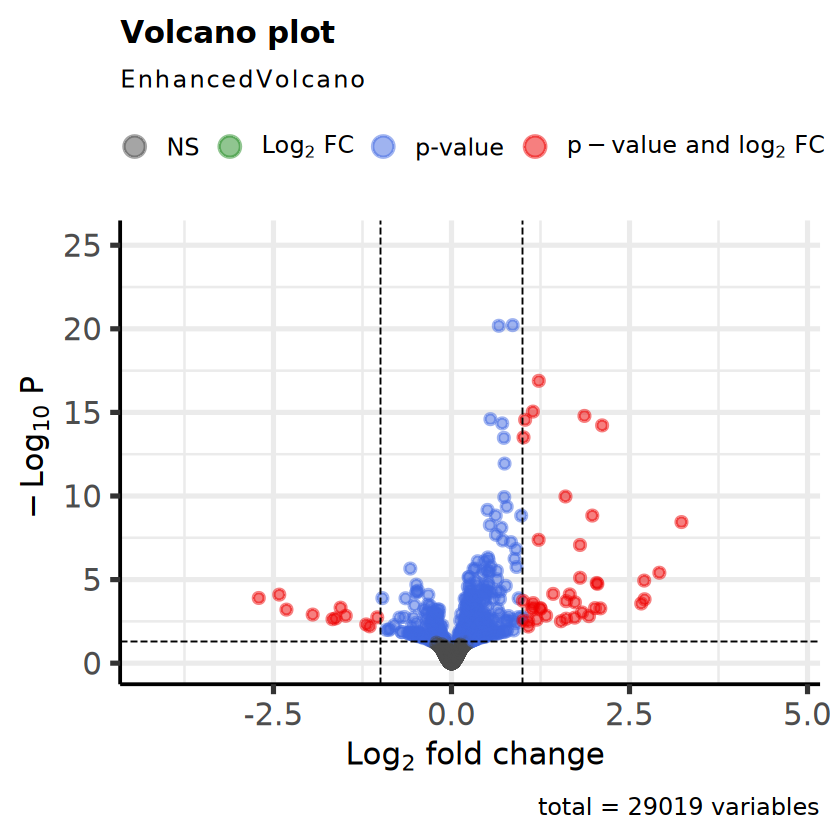

In [38]:
p2_DO.res <- lfcShrink(dds_p2DO, coef = 'Phase2_DO_hypoxic_vs_normoxic', 
                     type = 'ashr',
                      lfcThreshold = 1)

summary(p2_DO.res)

EnhancedVolcano(p2_DO.res,
                lab=NA,
                x = 'log2FoldChange',
                y='padj',
                pCutoff=0.05)

p2_DO.res <- merge(p2_DO.res, counts(dds_p2DO, normalized=TRUE), by="row.names", sort=FALSE) # add normalized counts to DESeq results
names(p2_DO.res)[1] <- 'Gene'

head(p2_DO.res)

In [39]:
as.data.frame(p2_DO.res) %>%
filter(abs(log2FoldChange) > 1 & padj < 0.05) %>%
dim()

# 67 DEGs!

[1]  51 102

In [40]:
write.csv(p2_DO.res, '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/p2_DO.csv', row.names = FALSE)

### nMDS of only significant DEGs from isolated treatments

shouldn't matter which DESeq function I run, since we only need vst which is the normalized expression - should return the same numbers/counts 

In [41]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC144621260,11.570574,11.363102,11.347329,11.206643,10.917885,10.900578,11.303271,10.984521,11.090786,11.113089,⋯,11.792312,10.557917,11.032465,11.489317,11.350978,11.171864,11.307963,11.152550,11.763217,11.605393
LOC144621269,8.773610,11.092321,11.512095,10.455478,11.550914,10.604269,12.801838,10.990546,8.541785,8.387600,⋯,13.910314,8.316387,8.394774,10.142268,8.705390,9.034990,13.459696,8.520347,9.812816,13.438222
LOC111120925,8.850629,8.571342,9.866559,8.426737,8.517097,8.405537,8.161861,8.248737,8.161861,8.247257,⋯,9.734933,8.161861,8.326645,9.884543,8.900173,8.626621,8.366981,8.251699,8.456657,8.426605
Trnae-cuc-2,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861
Trnae-cuc-3,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861
LOC144621283,10.014367,10.434670,10.457301,10.284453,10.377430,10.656012,10.621772,9.877429,10.213526,10.311855,⋯,10.106725,10.573338,10.322487,10.458995,10.430403,10.349131,10.082143,10.930438,10.096138,10.127242


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [42]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/isolated_treatments/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "p1_DO"   "p1_temp" "p2_DO"   "p2_temp"

In [43]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::filter(padj < 0.05 & abs(log2FoldChange) > 1) %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 290 total DEGs
head(all_degs)

[1] 265

[1] "LOC111104012" "LOC111102592" "LOC144624804" "LOC144625490" "LOC144625901"
[6] "LOC111101301"

In [44]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 290 total DEGs kept
head(degs_vsd) 

[1] 265  94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111102506,10.380840,9.560323,13.467640,9.095155,10.970108,8.935006,9.062335,10.197227,11.499914,9.047712,⋯,9.050487,9.415516,9.525608,10.696301,9.276084,9.537034,10.351851,9.426189,9.549025,9.346426
LOC111103173,8.347567,8.247518,8.279739,8.161861,8.161861,8.321493,8.161861,8.161861,8.161861,8.995706,⋯,8.161861,8.161861,8.161861,8.471088,8.304568,8.161861,8.291656,8.161861,8.339826,8.338495
LOC111103490,12.325820,13.319562,13.893435,11.230966,12.825426,12.065763,12.362042,11.998235,11.651213,10.530309,⋯,11.425075,10.593363,11.145859,11.228763,12.027792,11.018941,12.625862,11.607018,11.498946,13.141607
LOC144622059,8.327985,8.876399,8.245225,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,8.161861,⋯,10.237259,8.161861,8.296431,8.283347,8.161861,8.161861,9.787217,8.161861,8.161861,10.179552
LOC111105131,8.396666,8.403887,8.867176,8.300329,8.694998,8.367875,8.454862,8.161861,8.531140,8.403151,⋯,9.441800,8.440138,8.161861,8.161861,8.161861,8.314577,9.782977,8.161861,8.161861,8.610659
LOC111104543,8.161861,8.445538,8.524332,8.321730,8.619704,8.572847,8.438158,8.161861,8.161861,8.161861,⋯,9.320533,8.161861,8.161861,8.404617,8.422161,8.314577,8.779810,8.161861,8.161861,10.026920


In [45]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,12.575673,16.82096,12.932864,18.58007,12.594205,14.322617,12.745796,11.877148,14.74850,⋯,27.36305,12.869791,12.07491,13.119530,12.501106,11.169574,25.15713,12.550227,13.346193,29.06447
B1_W5_O50,12.57567,0.000000,14.84429,8.567808,15.52108,8.574989,7.974597,8.088239,8.893891,12.04086,⋯,23.28776,9.808964,10.29981,8.776904,10.301848,9.748675,23.38100,9.719817,9.762422,24.77291
B2_B5_O51,16.82096,14.844288,0.00000,17.181774,16.99998,15.616050,14.885430,15.458491,16.149148,18.88176,⋯,22.43185,17.067327,17.58493,14.626084,16.882472,16.532962,21.64151,16.288461,16.925990,24.29982
B2_C4_O40,12.93286,8.567808,17.18177,0.000000,18.24160,8.873988,11.237758,9.261132,10.947797,10.92293,⋯,25.83020,9.409984,10.18547,9.371928,8.983627,9.903190,25.75128,8.394751,7.448790,27.16068
B3_B4_O41,18.58007,15.521084,16.99998,18.241597,0.00000,17.531613,16.313913,18.262602,17.093566,20.59936,⋯,17.40215,19.204303,19.46881,16.970775,19.212475,17.971481,15.06084,17.577956,18.698433,17.14160
B3_C3_O30,12.59420,8.574989,15.61605,8.873988,17.53161,0.000000,9.610107,10.058257,9.934005,12.57127,⋯,25.32502,10.679681,10.31777,9.091426,11.205199,9.598842,25.16273,9.570942,10.089753,26.92753


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,3.7145466,2.5912620,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0522133
B1_W5_O50,0.7497815,0.6554000,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,0.9902207
B2_B5_O51,-4.1042118,5.1527838,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0454603
B2_C4_O40,3.6180568,-2.3523123,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1362472
B3_B4_O41,-9.8654563,-2.7231799,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8595069
B3_C3_O30,3.0588292,-0.1253456,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8547230


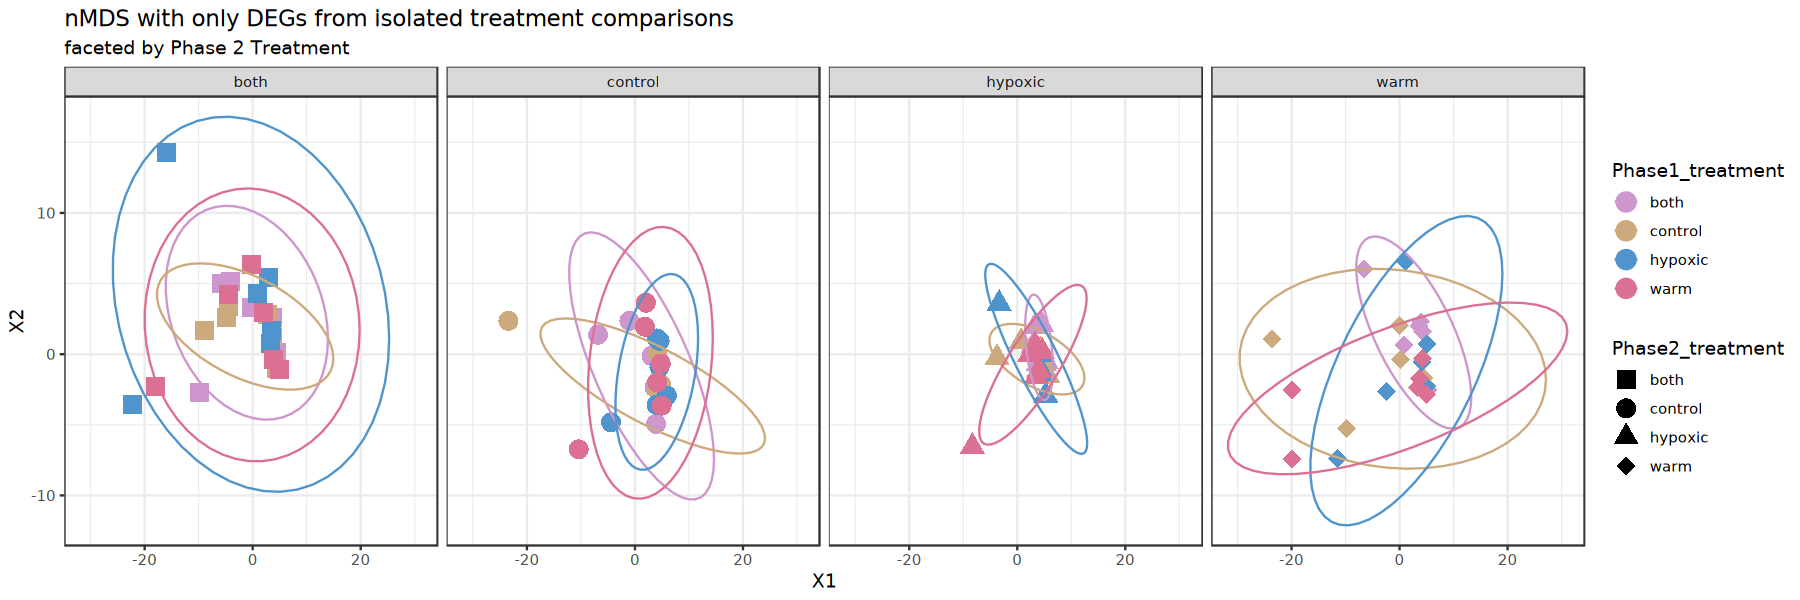

In [46]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

see less dispersion in phase 2 control and hypoxic (so ambient) samples compared to both and warm (so warm) samples 

this makes sense, as I've seen phase 2 temperature being a bigger driver for differential expression

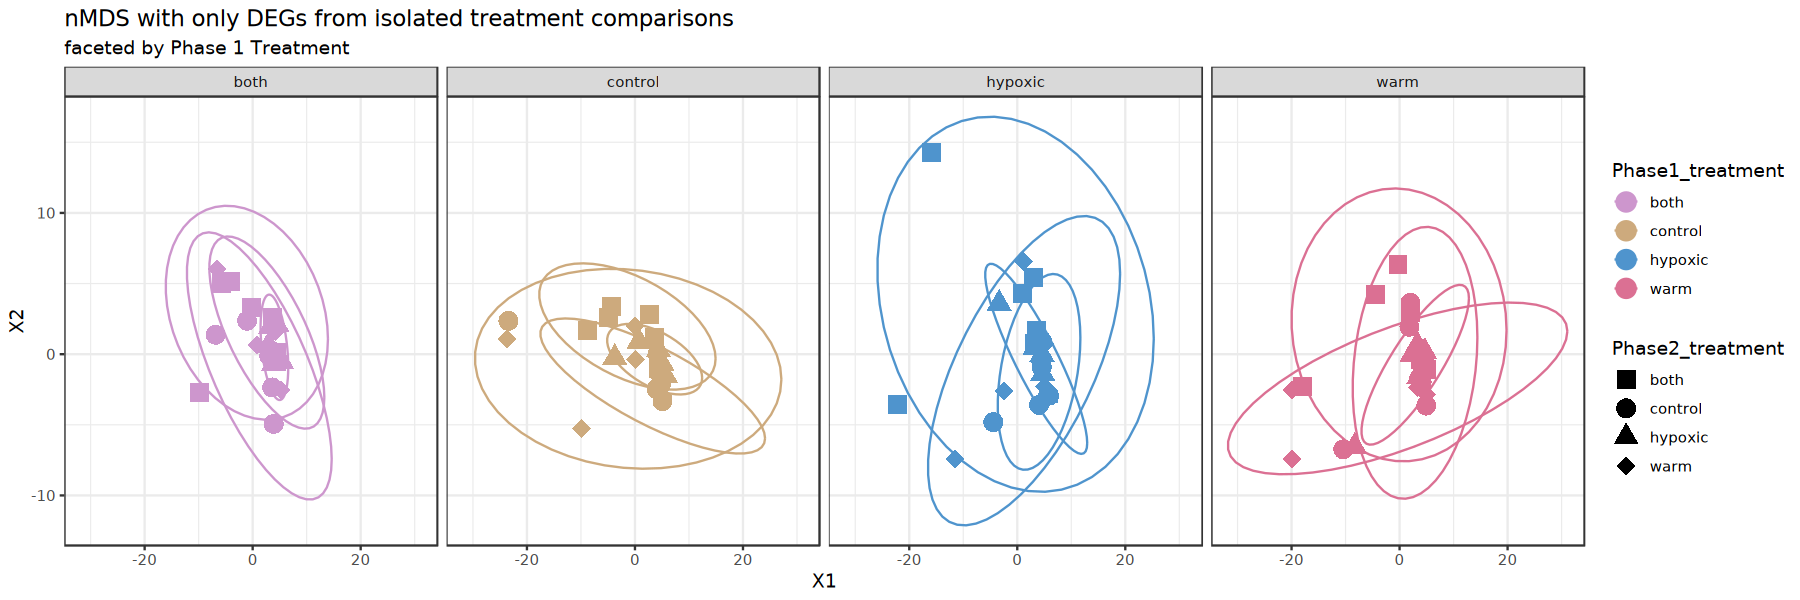

In [47]:
nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

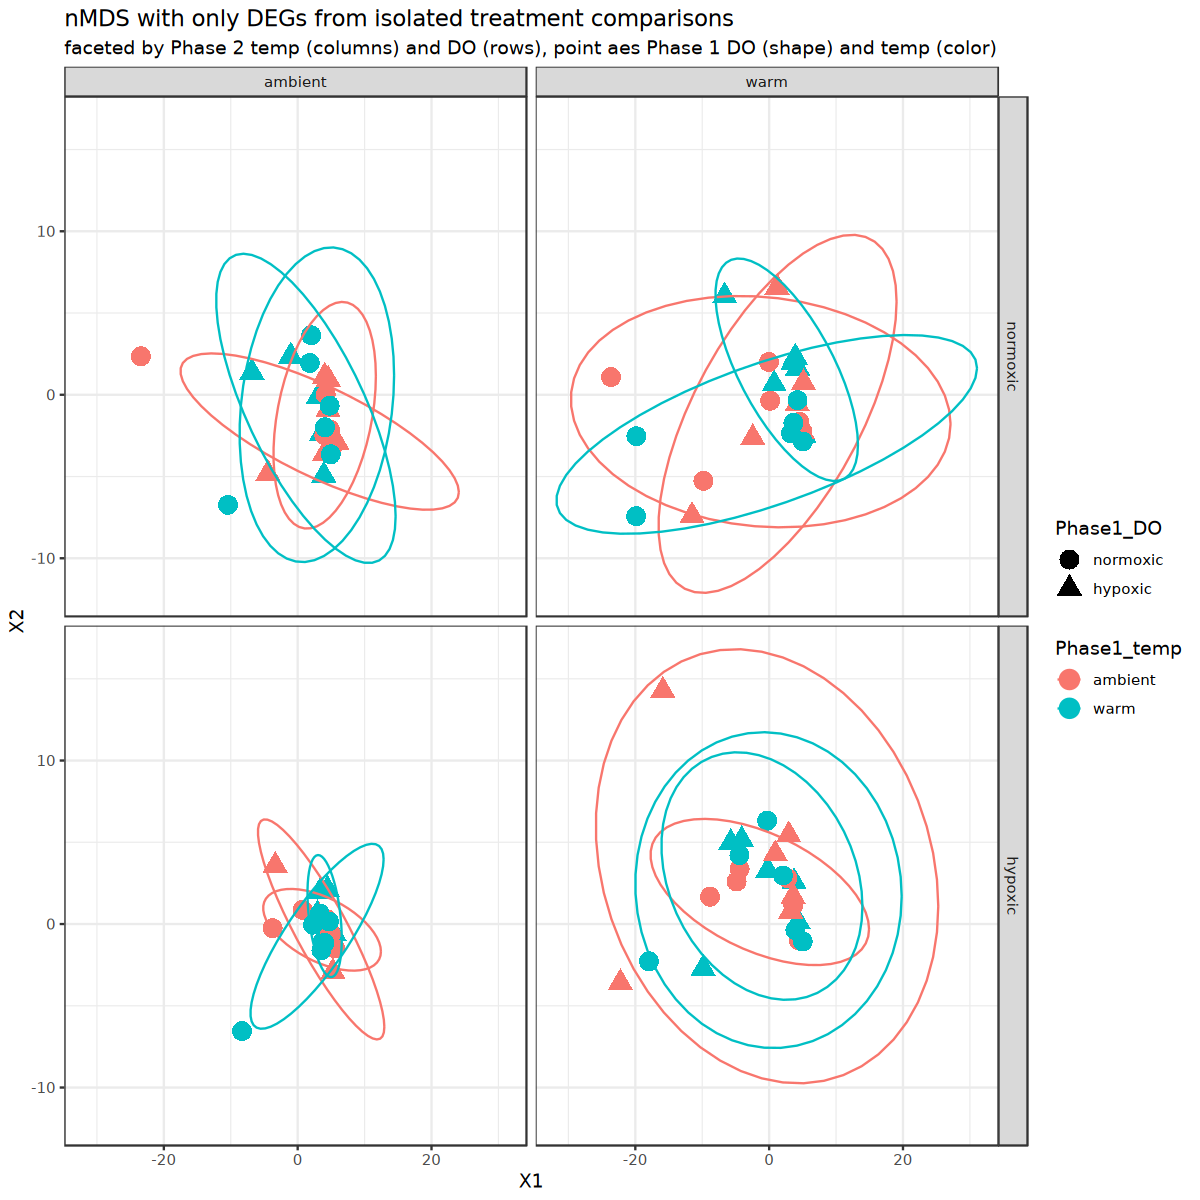

In [48]:
options(repr.plot.width = 10, repr.plot.height = 10)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_temp, shape = Phase1_DO)) +
geom_point(size = 5) +
facet_grid(Phase2_DO~Phase2_temp) + 
stat_ellipse() + 
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 temp (columns) and DO (rows), point aes Phase 1 DO (shape) and temp (color)') + 
theme_bw()

nmds.plot

#### permanova for DEGs

In [49]:
adonis2(sample_dists ~ Phase1_temp * Phase1_DO * Phase2_temp * Phase2_DO, data = meta_noOutliers, permutations = 999)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Phase1_temp,1,66.09649,0.005232892,0.4968288,0.965
Phase1_DO,1,158.03661,0.012511838,1.1879171,0.260
Phase2_temp,1,612.46338,0.048489033,4.6037161,0.001
Phase2_DO,1,370.63484,0.029343346,2.7859585,0.023
Phase1_temp:Phase1_DO,1,84.56534,0.006695080,0.6356540,0.771
Phase1_temp:Phase2_temp,1,73.88016,0.005849130,0.5553365,0.886
Phase1_DO:Phase2_temp,1,63.09464,0.004995235,0.4742648,0.970
Phase1_temp:Phase2_DO,1,69.30171,0.005486651,0.5209216,0.926
Phase1_DO:Phase2_DO,1,140.79844,0.011147083,1.0583425,0.321


only significant effects from Phase2_temp and Phase2_DO - so most recent stressors

### nMDS of any DEG identified in all pairwise comparisons

In [16]:
# variance stabilizing transformation
vsd <- vst(dds.noOutliers) # from full DESeq function, without the 2 outlier samples
head(assay(vsd))

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111116054,7.692872,7.805746,7.871959,7.843091,7.548551,7.909124,7.947895,7.869635,7.840134,7.758281,⋯,7.767900,7.713596,7.900466,7.697844,7.834121,7.790482,7.708399,8.030152,7.657898,7.548551
LOC111126949,10.197580,9.653169,9.900281,9.718856,9.612738,9.545333,9.334530,9.803992,9.906070,9.592360,⋯,9.078093,9.779869,9.712370,10.082883,9.950378,9.563392,9.665533,9.644851,9.276775,9.929224
LOC111110729,8.354765,8.542687,8.351593,8.513945,8.518601,8.653091,8.816678,8.937210,8.568640,8.590933,⋯,8.714150,8.368627,8.514299,8.798284,8.635108,8.680883,8.780214,8.673395,8.746416,9.064164
LOC111112434,7.886383,7.697174,7.548551,7.687586,7.940109,7.989592,7.818256,8.186828,7.658920,7.879728,⋯,7.817069,7.548551,7.937395,7.806904,7.750644,7.548551,7.708399,7.990820,7.857315,7.548551
LOC111120752,9.363550,9.355360,9.509373,9.284512,9.198871,9.337765,9.699834,9.473806,8.989457,9.167603,⋯,9.549481,9.234610,9.599548,9.383933,9.510347,9.253648,9.345876,9.627837,9.412129,9.619853
LOC111128944,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,⋯,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551,7.548551


get list of DEGs identified in the 'isolated' treatments (otherwise, there's just a million DEGs)

In [45]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- tools::file_path_sans_ext(basename(files))
geneList <- lapply(files, read.csv)
names(geneList)

[1] "DEG_bb_cc" "DEG_bc_bb" "DEG_bc_cc" "DEG_bc_hc" "DEG_bc_wc" "DEG_bh_ch"
 [7] "DEG_bh_hh" "DEG_bw_cw" "DEG_bw_ww" "DEG_cb_bb" "DEG_cb_bc" "DEG_cb_cc"
[13] "DEG_cb_ch" "DEG_cb_cw" "DEG_ch_cc" "DEG_ch_hc" "DEG_cw_cc" "DEG_cw_ch"
[19] "DEG_cw_wc" "DEG_hb_bb" "DEG_hb_bh" "DEG_hb_cb" "DEG_hc_cc" "DEG_hc_hh"
[25] "DEG_hh_cc" "DEG_hh_ch" "DEG_wb_bb" "DEG_wb_bw" "DEG_wb_cb" "DEG_wc_cc"
[31] "DEG_wc_hc" "DEG_wc_ww" "DEG_wh_hw" "DEG_ww_cc" "DEG_ww_cw"

In [46]:
# create list of all DEGs from the four dfs
all_degs <- geneList %>%
  lapply(function(df) {
    df %>%
      dplyr::pull(Gene)
  }) %>%
  unlist() %>%
  unique()

length(all_degs) # 2263 total DEGs
head(all_degs)

[1] 2263

[1] "LOC111134671" "LOC111120923" "LOC111136853" "LOC111120760" "LOC111107221"
[6] "LOC111125595"

In [47]:
# filter vsd for only degs
degs_vsd <- assay(vsd)[rownames(assay(vsd)) %in% all_degs,]

dim(degs_vsd) # 2263 total DEGs kept
head(degs_vsd) 

[1] 2263   94

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
LOC111105691,7.692872,7.845404,8.595408,8.101515,8.014009,8.149132,7.757585,8.212449,7.704598,7.805305,⋯,7.703729,7.713596,7.859081,7.548551,8.010013,7.736037,7.905257,8.416445,7.997691,7.548551
LOC111109550,8.131067,7.805746,8.743886,7.928364,7.708812,7.803846,8.159885,8.674840,7.704598,7.653485,⋯,7.985994,8.626921,7.714765,8.881685,10.092835,8.251878,9.960122,8.017421,8.058891,8.520289
LOC111102585,7.798315,8.004935,8.306724,8.475852,8.355585,7.548551,8.803914,7.948558,7.704598,7.758281,⋯,8.794420,7.817824,7.666114,8.234621,7.898017,7.548551,10.227302,8.077917,7.875967,9.296881
LOC111129522,7.548551,8.120664,7.887674,8.066193,8.144263,7.926626,8.494087,7.548551,7.860191,7.782985,⋯,8.094194,7.548551,9.987741,7.697844,9.097456,7.872833,8.173305,7.898706,7.857315,8.129922
LOC111119645,11.013693,8.101502,11.484225,8.037954,7.548551,7.776953,7.774301,7.548551,7.704598,7.696918,⋯,9.367806,7.951734,7.811141,8.938418,8.740486,7.854358,7.825135,7.976880,8.123486,8.262219
LOC111129878,7.650623,7.548551,7.871959,7.952738,7.661902,7.776953,7.919830,7.548551,7.548551,7.653485,⋯,7.548551,7.548551,7.880431,7.806904,7.795962,7.656847,7.661610,7.931939,7.816075,7.548551


In [48]:
# calculate sample distances
sample_dists <- degs_vsd %>%
t() %>%
dist() %>%
as.matrix()

head(sample_dists)

# calculate MDS value from distance matrix
mdsData <- data.frame(cmdscale(sample_dists))
mds <- cbind(mdsData, as.data.frame(colData(vsd))) # combine with sample data
head(mds)

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
B1_B1_O01,0.00000,46.43361,45.73539,43.84645,49.73550,44.43556,47.39553,43.74362,46.22663,41.88886,⋯,57.89188,42.65465,39.22486,39.07451,38.70156,41.73571,59.67276,42.59358,41.49088,59.86365
B1_W5_O50,46.43361,0.00000,50.88725,35.16716,40.25746,37.80542,36.85094,39.82587,39.26073,38.94531,⋯,50.92336,40.06429,39.28590,44.69943,43.99756,41.04530,53.09433,40.34483,38.75099,50.03105
B2_B5_O51,45.73539,50.88725,0.00000,50.60368,50.77186,51.57691,49.44982,52.85483,54.79573,51.71212,⋯,52.67049,52.82034,51.48311,42.86659,48.04415,52.55684,58.24607,51.88533,48.80898,53.92939
B2_C4_O40,43.84645,35.16716,50.60368,0.00000,42.74597,33.38867,39.20402,38.13177,39.36770,37.22117,⋯,53.58619,37.38804,38.27075,43.05805,41.64574,40.47929,57.77789,37.40804,33.11933,53.52733
B3_B4_O41,49.73550,40.25746,50.77186,42.74597,0.00000,45.87647,43.81807,46.81046,39.69463,47.11637,⋯,42.79811,47.87468,46.67330,47.61091,49.46200,48.35379,45.50210,45.57722,46.29409,42.70204
B3_C3_O30,44.43556,37.80542,51.57691,33.38867,45.87647,0.00000,41.11701,40.36882,41.73098,37.71411,⋯,56.16122,38.34243,38.44486,44.86054,42.96716,39.30128,57.66326,39.16953,37.81118,54.84643


,X1,X2,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,complete_trtmt,sizeFactor
,<dbl>,<dbl>,<chr>,<fct>,<fct>,<int>,<chr>,<fct>,<fct>,<int>,<fct>,<dbl>
B1_B1_O01,8.434536,12.217624,both,warm,hypoxic,1,both,warm,hypoxic,1,both both,1.0666333
B1_W5_O50,-3.341411,-8.427508,both,warm,hypoxic,1,warm,warm,normoxic,5,both warm,1.0057329
B2_B5_O51,-7.695686,20.238490,both,warm,hypoxic,2,both,warm,hypoxic,5,both both,1.0584922
B2_C4_O40,3.140779,-7.068260,both,warm,hypoxic,2,control,ambient,normoxic,4,both control,1.1493541
B3_B4_O41,-16.873005,-7.050391,both,warm,hypoxic,3,both,warm,hypoxic,4,both both,0.8648335
B3_C3_O30,5.335760,-7.838027,both,warm,hypoxic,3,control,ambient,normoxic,3,both control,0.8506698


Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


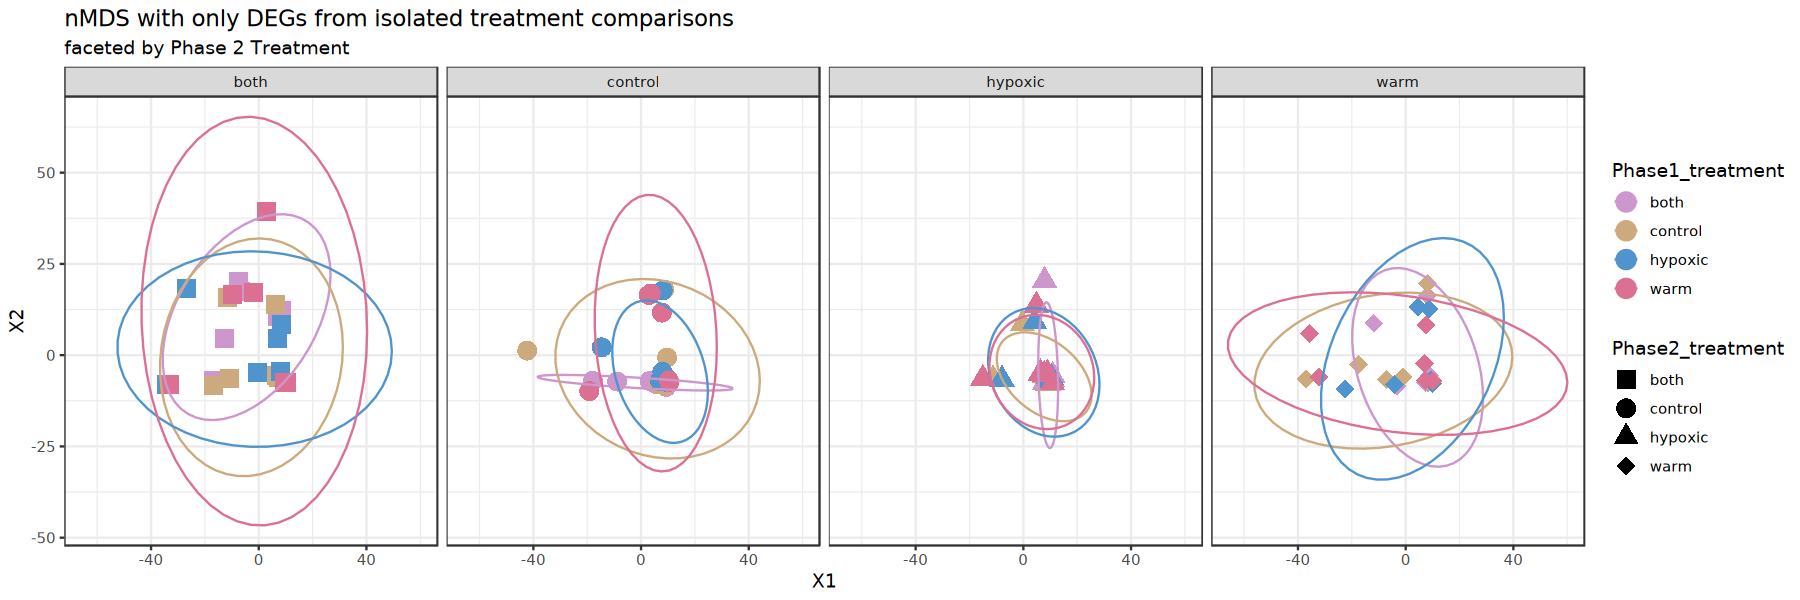

In [49]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, col = Phase1_treatment, shape = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase2_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 2 Treatment') + 
theme_bw()

nmds.plot

BC samples (purple circles) - super tight clustering; same with BH samples (purple triangles)

Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”
Warning message in MASS::cov.trob(data[, vars], wt = weight * nrow(data)):
“Probable convergence failure”


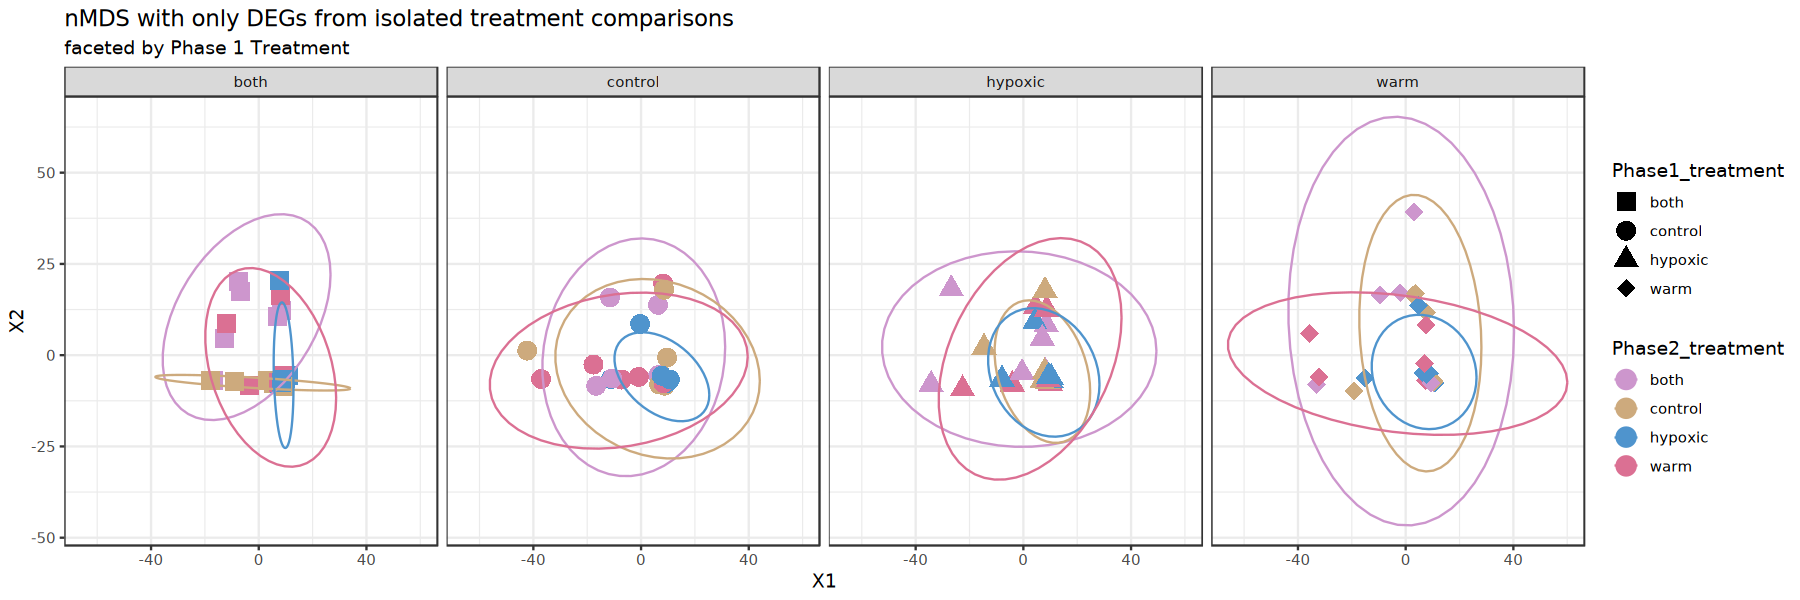

In [58]:
options(repr.plot.width = 15, repr.plot.height = 5)

nmds.plot <- ggplot(mds, aes(X1, X2, shape = Phase1_treatment, col = Phase2_treatment)) +
geom_point(size = 5) +
facet_wrap(~Phase1_treatment, nrow=1) + 
stat_ellipse() + 
scale_shape_manual(values=c(15, 16, 17, 18)) +
scale_color_manual(values = c("hypoxic" = "steelblue3", "warm" = "palevioletred", "control" = "burlywood3", "both" = "plum3")) +
labs(title = 'nMDS with only DEGs from isolated treatment comparisons',
    subtitle = 'faceted by Phase 1 Treatment') + 
theme_bw()

nmds.plot

*coloring and shapes are reversed from above*

- phase 2 hypoxic (blue) seems to have a less dispersed GE profile - tighter circling in all grids
- phase 2 both has more dispersed profile in all grids, less specific response/depends on the early stressor?